# Creating Feature Space

In [2]:

import multilabel_model as mm
from sklearn.pipeline import Pipeline
import pandas as pd
from sqlalchemy import create_engine
import tools.helpers as hh
import tools.filter_helpers as fh
import matplotlib.pyplot as plt
from matplotlib_venn import venn3
from venn import venn
from pathlib import Path

In [3]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [4]:
# !pip install imblearn


In [5]:
import importlib
importlib.reload(mm)
importlib.reload(fh)

<module 'tools.filter_helpers' from '/Users/gnaanikko.pa/Documents/Academic /MIMIC/model_building/tools/filter_helpers.py'>

In [6]:
pd.set_option('display.max_columns', None)


In [7]:
DATA_ROOT = Path("/Users/gnaanikko.pa/Documents/Academic /MIMIC/model_building")
PARQ_DIR = DATA_ROOT / "parq"

## Functions

In [30]:
def get_prior_events(anchor_df, event_df,
                     subject_col='subject_id',
                     hadm_col='hadm_id',
                    event_time_col='storetime',
                    anchor_time_col='hospital_admit_time'):
    """
    For each admission in anchor_df, find prior admissions
    of the same subject in event_df and attach anchor info.
    """

    anchor = anchor_df.copy()
    events = event_df.copy()

    # Ensure datetime
    anchor[anchor_time_col] = pd.to_datetime(anchor[anchor_time_col])
    events[event_time_col] = pd.to_datetime(events[event_time_col])

    # Rename anchor columns
    anchor = anchor.rename(columns={
        hadm_col: 'anchor_hadm_id',
        anchor_time_col: 'anchor_hadm_time'
    })

    # Rename event hadm_id to prior_hadm_id
    events = events.rename(columns={
        hadm_col: 'prior_hadm_id'
    })

    # Merge on subject
    merged = events.merge(
        anchor[[subject_col, 'anchor_hadm_id', 'anchor_hadm_time']],
        on=subject_col,
        how='inner'
    )

    # Keep only admissions before anchor admission
    prior = merged[merged[event_time_col] < merged['anchor_hadm_time']]

    return prior.reset_index(drop=True)

In [31]:
def extract_first_icu_stay(df,
                           hadm_col="hadm_id",
                           stay_col="stay_id",
                           hadm_time_col="hadm_time",
                           intime_col="intime"):
    """
    Extract first ICU stay per hadm_id.
    Final output sorted by hadm_time (chronological admission order).
    """

    df = df.copy()

    # Ensure datetime for hadm_time
    if hadm_time_col in df.columns:
        df[hadm_time_col] = pd.to_datetime(df[hadm_time_col])

    # Case 1: stay_id exists → choose first ICU stay per hadm
    if stay_col in df.columns:

        # Sort within each hadm by ICU intime if available
        if intime_col in df.columns:
            df[intime_col] = pd.to_datetime(df[intime_col])
            df = df.sort_values(by=[hadm_col, intime_col])
        else:
            df = df.sort_values(by=[hadm_col, stay_col])

        first_df = df.groupby(hadm_col, as_index=False).first()

    # Case 2: no stay_id → keep unique hadm
    else:
        first_df = df.drop_duplicates(subset=[hadm_col])

    # Final sorting by hadm_time
    if hadm_time_col in first_df.columns:
        first_df = first_df.sort_values(by=hadm_time_col)

    return first_df.reset_index(drop=True)

In [32]:


def get_prior_events_forloop(anchor_df,
                             event_df,
                             subject_col="subject_id",
                             hadm_col="hadm_id",
                             anchor_time_col="hadm_time",
                             event_time_col="hadm_time"):
    """
    Returns all events that occurred prior to each anchor admission.

    Output:
    - All columns from event_df (prior events)
    - Plus anchor_hadm_id and anchor_hadm_time
    """

    anchor_df = anchor_df.copy()
    event_df = event_df.copy()

    # Ensure datetime
    anchor_df[anchor_time_col] = pd.to_datetime(anchor_df[anchor_time_col])
    event_df[event_time_col] = pd.to_datetime(event_df[event_time_col])

    results = []

    for _, anchor_row in anchor_df.iterrows():

        subject_id = anchor_row[subject_col]
        anchor_hadm_id = anchor_row[hadm_col]
        anchor_time = anchor_row[anchor_time_col]

        # Filter events for same subject
        patient_events = event_df[
            event_df[subject_col] == subject_id
        ]

        # Keep only events prior to anchor time
        prior_events = patient_events[patient_events[event_time_col] < anchor_time]

        for _, event_row in prior_events.iterrows():

            row_dict = event_row.to_dict()

            # Add anchor info
            row_dict["anchor_hadm_id"] = anchor_hadm_id
            row_dict["anchor_hadm_time"] = anchor_time

            results.append(row_dict)

    final_df = pd.DataFrame(results)

    # Sort output chronologically
    if not final_df.empty:
        final_df = final_df.sort_values(
            by=[subject_col, "anchor_hadm_time", event_time_col]
        ).reset_index(drop=True)

    return final_df

## Loading Datasets

### Main datasets

#### All Admission dataframe

In [33]:
all_adm_df= hh.load_data('./parq/all_adm_df_27Feb26_1738.parquet')
hh.dxx(all_adm_df)

11.9k Unique Patient IDs (11905)
59.0k Unique Admission IDs (59024)
24.5k Unique ICU Stay IDs (24504)
62.7k Rows, shape: (62657, 16)



,subject_id,gender,anchor_age,anchor_year,hadm_id,hospital_admit_time,hospital_discharge_time,hospital_death_time,stay_id,icu_admit_time,icu_discharge_time,icu_los_days,admission_type,admission_location,discharge_location,race
dtype,int64,object,int64,int64,int64,datetime64[ns],datetime64[ns],datetime64[ns],float64,datetime64[ns],datetime64[ns],float64,object,object,object,object
NotNA | NA,62657 | 0,62657 | 0,62657 | 0,62657 | 0,62657 | 0,62657 | 0,62657 | 0,4304 | 58353,24504 | 38153,24504 | 38153,24495 | 38162,24495 | 38162,62657 | 0,62657 | 0,53655 | 9002,62657 | 0
nunique,11905,2,73,96,59024,58945,58790,3424,24505,24504,24496,24019,9,11,14,33
0,10006508,F,71,2132,20850343,2132-03-28 22:38:00,2132-04-02 15:00:00,NaT,nan,NaT,NaT,nan,OBSERVATION ADMIT,EMERGENCY ROOM,HOME HEALTH CARE,BLACK/AFRICAN AMERICAN
1,10001843,M,73,2131,21728396,2131-11-09 16:05:00,2131-11-11 11:23:00,NaT,nan,NaT,NaT,nan,OBSERVATION ADMIT,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,WHITE
2,10001843,M,73,2131,26133978,2134-12-05 00:10:00,2134-12-06 12:54:00,2134-12-06 12:54:00,39698942.000000,2134-12-05 18:50:03,2134-12-06 14:38:26,0.825266,URGENT,TRANSFER FROM HOSPITAL,DIED,WHITE


In [34]:
first_adm_df= extract_first_icu_stay(df= all_adm_df, intime_col='icu_admit_time',hadm_time_col='hospital_admit_time')

#### Respiratoy admission dataframe

In [35]:
resp_admission_df = pd.read_parquet(PARQ_DIR / "resp_inf_cohort_23Jan26_1953.parquet")
hh.dxx(resp_admission_df)


11.9k Unique Patient IDs (11905)
13.6k Unique Admission IDs (13611)
16.4k Unique ICU Stay IDs (16438)
18.1k Rows, shape: (18109, 19)



,subject_id,gender,anchor_age,anchor_year,hadm_id,hospital_admit_time,hospital_discharge_time,hospital_death_time,stay_id,icu_admit_time,icu_discharge_time,icu_los_days,admission_type,admission_location,discharge_location,race,seq_num,icd_version,icd_code
dtype,int64,object,int64,int64,int64,datetime64[ns],datetime64[ns],datetime64[ns],int64,datetime64[ns],datetime64[ns],float64,object,object,object,object,int64,int64,object
NotNA | NA,18109 | 0,18109 | 0,18109 | 0,18109 | 0,18109 | 0,18109 | 0,18109 | 0,4055 | 14054,18109 | 0,18109 | 0,18099 | 10,18099 | 10,18109 | 0,18109 | 0,18074 | 35,18109 | 0,18109 | 0,18109 | 0,18109 | 0
nunique,11905,2,73,96,13611,13607,13598,2831,16438,16438,16430,16246,9,11,14,33,38,2,142
0,10003637,M,57,2145,28317408,2150-05-14 19:51:00,2150-05-22 16:25:00,2150-05-22 16:25:00,32824762,2150-05-16 07:30:28,2150-05-22 18:38:55,6.464201,EW EMER.,WALK-IN/SELF REFERRAL,DIED,PORTUGUESE,3,10,J1289
1,10010888,M,43,2174,20162667,2174-01-09 22:19:00,2174-01-27 16:00:00,NaT,33318955,2174-01-09 00:21:00,2174-01-18 00:48:41,9.019225,EW EMER.,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,WHITE,2,10,J1282
2,10011938,F,57,2121,23798746,2133-08-13 09:48:00,2133-10-05 19:27:00,NaT,31780787,2133-08-13 09:48:53,2133-09-01 18:22:42,19.356817,EW EMER.,TRANSFER FROM SKILLED NURSING FACILITY,REHAB,WHITE - OTHER EUROPEAN,2,10,J15212


#### Respiratory diagnosis Dataframe

In [36]:
diagnosis_df = pd.read_parquet(PARQ_DIR / "df_resp_inf_icu_final.parq")
hh.dxx(diagnosis_df)

11.9k Unique Patient IDs (11905)
13.6k Unique Admission IDs (13611)
16.4k Unique ICU Stay IDs (16438)
18.1k Rows, shape: (18109, 6)



,subject_id,hadm_id,stay_id,seq_num,icd_version,icd_code
dtype,int64,int64,int64,int64,int64,object
NotNA | NA,18109 | 0,18109 | 0,18109 | 0,18109 | 0,18109 | 0,18109 | 0
nunique,11905,13611,16438,38,2,142
0,10001843,26133978,39698942,4,10,J189
1,10001884,26184834,37510196,19,10,J0190
2,10002155,20345487,32358465,2,9,486


### Feature Datasets

#### Demographics

In [37]:
demographics_df= hh.load_data('./parq/demo_df_26Feb26_1629.parquet')
hh.dxx(demographics_df)


11.9k Unique Patient IDs (11905)
13.6k Unique Admission IDs (13611)
16.4k Unique ICU Stay IDs (16438)
16.4k Rows, shape: (16438, 23)



,subject_id,hadm_id,stay_id,gender,age_at_admission,anchor_age,anchor_year,anchor_year_group,hospital_admit_time,hospital_discharge_time,admission_type,admission_location,discharge_location,insurance,race,marital_status,language,first_careunit,last_careunit,intime,outtime,los,admission_year
dtype,int64,int64,int64,object,int64,int64,int64,object,datetime64[ns],datetime64[ns],object,object,object,object,object,object,object,object,object,datetime64[ns],datetime64[ns],float64,int32
NotNA | NA,16438 | 0,16438 | 0,16438 | 0,16438 | 0,16438 | 0,16438 | 0,16438 | 0,16438 | 0,16438 | 0,16438 | 0,16438 | 0,16438 | 0,16405 | 33,16252 | 186,16438 | 0,14967 | 1471,16360 | 78,16438 | 0,16438 | 0,16438 | 0,16429 | 9,16429 | 9,16438 | 0
nunique,11905,13611,16438,2,85,73,96,5,13607,13598,9,11,14,6,33,5,26,14,14,16438,16430,16246,104
0,10001843,26133978,39698942,M,76,73,2131,2017 - 2019,2134-12-05 00:10:00,2134-12-06 12:54:00,URGENT,TRANSFER FROM HOSPITAL,DIED,Medicare,WHITE,SINGLE,English,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2134-12-05 18:50:03,2134-12-06 14:38:26,0.825266,2134
1,10001884,26184834,37510196,F,77,68,2122,2008 - 2010,2131-01-07 20:39:00,2131-01-20 05:15:00,OBSERVATION ADMIT,EMERGENCY ROOM,DIED,Medicare,BLACK/AFRICAN AMERICAN,MARRIED,English,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2131-01-11 04:20:05,2131-01-20 08:27:30,9.171817,2131
2,10002155,20345487,32358465,F,83,80,2128,2008 - 2010,2131-03-09 20:33:00,2131-03-10 01:55:00,EW EMER.,EMERGENCY ROOM,DIED,Medicare,WHITE,MARRIED,English,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2131-03-09 21:33:00,2131-03-10 18:09:21,0.858576,2131


#### Time 

In [12]:
# time_df=hh.load_data('./parq/time_df27Feb26_2039.parquet
# time_df=hh.load_data('./parq/time_df05Mar26_2130.parquet')
time_df=hh.load_data('./parq/time_df_after_first_icu12Apr26_1615.parquet')

hh.dxx(time_df)


3.6k Unique Patient IDs (3588)
3.9k Unique Admission IDs (3882)
3.3k Unique ICU Stay IDs (3311)
3.9k Rows, shape: (3882, 14)



,subject_id,hadm_id,stay_id,hospital_admit_time,hospital_discharge_time,hospital_death_time,icu_admit_time,icu_discharge_time,first_icu_admit_time,first_ast_time,ast_inside_icu_stay,hours_adm_to_ast,hours_icu_to_ast,hours_first_icu_admit_to_ast
dtype,int64,int64,float64,datetime64[ns],datetime64[ns],datetime64[ns],datetime64[ns],datetime64[ns],datetime64[ns],datetime64[ns],bool,float64,float64,float64
NotNA | NA,3882 | 0,3882 | 0,3311 | 571,3882 | 0,3882 | 0,915 | 2967,3311 | 571,3311 | 571,3882 | 0,3882 | 0,3882 | 0,3882 | 0,3882 | 0,3882 | 0
nunique,3588,3882,3312,3880,3880,916,3312,3312,3882,3882,2,3264,3655,3657
0,18172155,20009330,36841282.000000,2144-01-01 00:33:00,2144-01-09 21:07:00,NaT,2144-01-01 04:26:36,2144-01-06 22:46:18,2144-01-01 04:26:36,2144-01-01 11:53:00,True,11.333333,7.440000,7.440000
1,19318312,20013496,32840324.000000,2161-11-04 04:33:00,2161-12-01 17:15:00,NaT,2161-11-04 06:58:00,2161-11-22 18:27:35,2161-11-04 06:58:00,2161-11-04 22:30:00,True,17.950000,15.533333,15.533333
2,17333498,20015712,nan,2162-05-14 03:54:00,2162-06-11 13:55:00,NaT,NaT,NaT,2162-05-14 04:28:00,2162-05-22 16:00:00,False,204.100000,203.533333,203.533333


<Axes: >

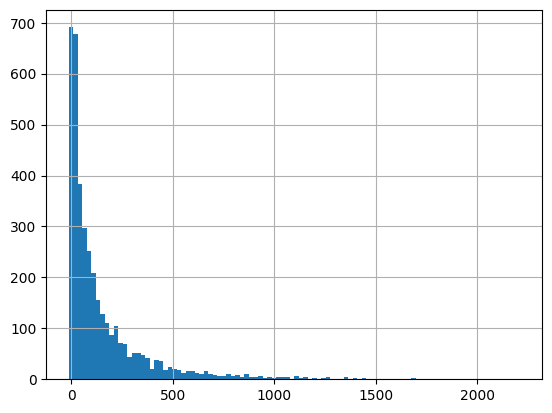

In [73]:
time_df.hours_adm_to_ast.hist(bins=100)

<Axes: >

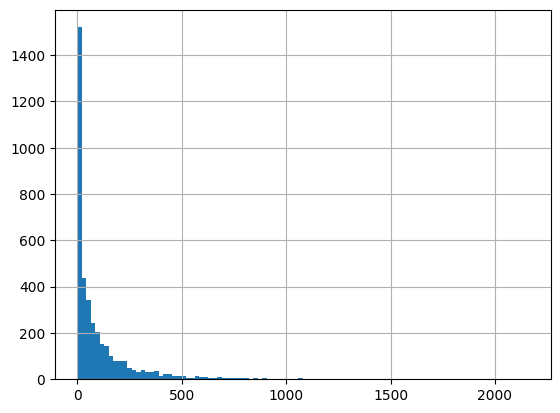

In [74]:
time_df.hours_icu_to_ast.hist(bins=100)


#### Vitals

In [75]:
# vitals_df=hh.load_data('./parq/vitals_df27Feb26_1808.parquet')
vitals_df=hh.load_data('./parq/vitals_df29Mar26_2344.parquet')
hh.dxx(vitals_df)


11.9k Unique Patient IDs (11905)
13.6k Unique Admission IDs (13611)
16.4k Unique ICU Stay IDs (16437)
17.2M Rows, shape: (17209316, 9)



KeyboardInterrupt: 

#### All Microbiology Records - including non respiratory admissions

In [42]:
all_micro_df= hh.load_data('./parq/all_micro_df_26Feb26_0625.parquet')
hh.dxx(all_micro_df)

11.5k Unique Patient IDs (11462)
18.9k Unique Admission IDs (18878)
22.4k Unique ICU Stay IDs (22440)
519.5k Rows, shape: (519525, 19)



,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los,microevent_id,chartdate,charttime,spec_type_desc,storetime,test_name,org_name,ab_name,interpretation,dilution_value,comments
dtype,int64,int64,int64,object,object,datetime64[ns],datetime64[ns],float64,int64,datetime64[ns],datetime64[ns],object,datetime64[ns],object,object,object,object,float64,object
NotNA | NA,519525 | 0,519525 | 0,519525 | 0,519525 | 0,519525 | 0,519525 | 0,519525 | 0,519525 | 0,519525 | 0,519525 | 0,519525 | 0,519525 | 0,514796 | 4729,519525 | 0,195856 | 323669,160393 | 359132,160393 | 359132,152509 | 367016,429900 | 89625
nunique,11462,18878,22440,14,14,22439,22440,22073,364102,30702,154248,75,225294,131,332,48,7,26,265
0,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-03 21:55:32,2135-01-19 21:16:23,15.972812,2602,2135-01-04 00:00:00,2135-01-04 13:41:00,PLEURAL FLUID,2135-01-04 19:19:00,GRAM STAIN,None,None,None,nan,NO POLYMORPHONUCLEAR LEUKOCYTES SEEN. NO MICROORGANISMS SEEN.
1,10005817,20626031,32604416,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2132-12-15 09:29:01,2132-12-17 18:06:07,2.359097,2591,2132-12-12 00:00:00,2132-12-12 02:08:00,URINE,2132-12-17 14:25:00,URINE CULTURE,"STAPHYLOCOCCUS, COAGULASE NEGATIVE",ERYTHROMYCIN,R,8.000000,None
2,10005817,20626031,32604416,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2132-12-15 09:29:01,2132-12-17 18:06:07,2.359097,2592,2132-12-12 00:00:00,2132-12-12 02:08:00,URINE,2132-12-17 14:25:00,URINE CULTURE,"STAPHYLOCOCCUS, COAGULASE NEGATIVE",NITROFURANTOIN,S,16.000000,None


#### Respiratory micro records

In [43]:
resp_micro_df = hh.df_subset(main_df=all_micro_df, isin_df=resp_admission_df, by_col='hadm_id')

In [44]:
hh.dx(resp_micro_df)

11.3k Unique Patient IDs (11348)
12.9k Unique Admission IDs (12922)
15.7k Unique ICU Stay IDs (15723)
421.7k Rows, shape: (421739, 19)



#### All AST Results - including non respiratory admissions

In [45]:
all_ast_df=hh.load_data('./parq/all_ast_df27Feb26_1751.parquet')
hh.dxx(all_ast_df)

4.7k Unique Patient IDs (4680)
6.0k Unique Admission IDs (5971)
7.8k Unique ICU Stay IDs (7838)
160.4k Rows, shape: (160393, 20)



,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los,microevent_id,chartdate,charttime,spec_type_desc,storetime,test_name,org_name,ab_name,interpretation,dilution_value,comments,combined_col
dtype,int64,int64,int64,object,object,datetime64[ns],datetime64[ns],float64,int64,datetime64[ns],datetime64[ns],object,datetime64[ns],object,object,object,object,float64,object,object
NotNA | NA,160393 | 0,160393 | 0,160393 | 0,160393 | 0,160393 | 0,160393 | 0,160393 | 0,160393 | 0,160393 | 0,160393 | 0,160393 | 0,160393 | 0,160301 | 92,160393 | 0,160393 | 0,160393 | 0,160393 | 0,152509 | 7884,91872 | 68521,160393 | 0
nunique,4680,5971,7838,14,14,7838,7838,7811,110133,8564,10774,36,10892,15,153,47,6,26,47,2085
1,10005817,20626031,32604416,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2132-12-15 09:29:01,2132-12-17 18:06:07,2.359097,2591,2132-12-12 00:00:00,2132-12-12 02:08:00,URINE,2132-12-17 14:25:00,URINE CULTURE,"STAPHYLOCOCCUS, COAGULASE NEGATIVE",ERYTHROMYCIN,R,8.000000,None,"['STAPHYLOCOCCUS, COAGULASE NEGATIVE', 'ERYTHROMYCIN', 'R']"
2,10005817,20626031,32604416,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2132-12-15 09:29:01,2132-12-17 18:06:07,2.359097,2592,2132-12-12 00:00:00,2132-12-12 02:08:00,URINE,2132-12-17 14:25:00,URINE CULTURE,"STAPHYLOCOCCUS, COAGULASE NEGATIVE",NITROFURANTOIN,S,16.000000,None,"['STAPHYLOCOCCUS, COAGULASE NEGATIVE', 'NITROFURANTOIN', 'S']"
3,10005817,20626031,32604416,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2132-12-15 09:29:01,2132-12-17 18:06:07,2.359097,2593,2132-12-12 00:00:00,2132-12-12 02:08:00,URINE,2132-12-17 14:25:00,URINE CULTURE,"STAPHYLOCOCCUS, COAGULASE NEGATIVE",TETRACYCLINE,S,2.000000,None,"['STAPHYLOCOCCUS, COAGULASE NEGATIVE', 'TETRACYCLINE', 'S']"


#### Lab Records 

In [46]:
lab_df= hh.load_data('./parq/lab_test_hosp_icu_df_23Jan26_2125.parquet')
hh.dx(lab_df)


11.9k Unique Patient IDs (11864)
13.5k Unique Admission IDs (13549)
16.4k Unique ICU Stay IDs (16370)
16.2M Rows, shape: (16160654, 24)



In [47]:
# feature_lab_df= hh.load_data('./parq/feature_lab_df_17Feb26_1750.parquet')
# hh.dxx(feature_lab_df, pid_col='stay_id')

### Test Dataset

#### LLM mapped Dataset - Grouped for AST Pattern

In [94]:
resp_index_ast_df.ab_name_x.unique()

array(['ERYTHROMYCIN', 'CLINDAMYCIN', 'TRIMETHOPRIM/SULFA',
       'TETRACYCLINE', 'GENTAMICIN', 'VANCOMYCIN', 'OXACILLIN',
       'LEVOFLOXACIN', 'RIFAMPIN', 'NITROFURANTOIN', 'TOBRAMYCIN',
       'CEFTAZIDIME', 'CEFTRIAXONE', 'CIPROFLOXACIN', 'PIPERACILLIN/TAZO',
       'CEFEPIME', 'MEROPENEM', 'AMPICILLIN', 'CEFAZOLIN',
       'AMPICILLIN/SULBACTAM', 'AMIKACIN', 'AZTREONAM', 'CEFIDEROCOL',
       'CEFTAZIDIME/AVIBACTAM', 'IMIPENEM/RELEBACTAM',
       'MEROPENEM/VABORBACTAM', 'PENICILLIN G', 'LINEZOLID', 'CEFUROXIME',
       'PIPERACILLIN', 'IMIPENEM', 'FLUCONAZOLE', 'DAPTOMYCIN',
       'MINOCYCLINE', 'CEFTOLOZANE/TAZOBACTAM', 'CASPOFUNGIN',
       'VORICONZAOLE', 'ERTAPENEM', 'ERAVACYCLINE', 'CEFTAROLINE'],
      dtype=object)

In [93]:
resp_index_ast_df.org_name.unique()

array(['STAPH AUREUS COAG +', 'ENTEROBACTER CLOACAE COMPLEX',
       'PROTEUS MIRABILIS', 'PSEUDOMONAS AERUGINOSA', 'ENTEROCOCCUS SP.',
       'ENTEROCOCCUS FAECALIS', 'CITROBACTER FREUNDII COMPLEX',
       'KLEBSIELLA PNEUMONIAE', 'ESCHERICHIA COLI',
       'ENTEROBACTER AEROGENES', 'STENOTROPHOMONAS MALTOPHILIA',
       'ACTINOMYCES ISRAELII', 'STREPTOCOCCUS PNEUMONIAE',
       'HAEMOPHILUS INFLUENZAE, BETA-LACTAMASE NEGATIVE',
       'KLEBSIELLA OXYTOCA', 'MORGANELLA MORGANII', 'CITROBACTER KOSERI',
       'POSITIVE FOR METHICILLIN RESISTANT STAPH AUREUS',
       'STAPHYLOCOCCUS, COAGULASE NEGATIVE', 'ENTEROCOCCUS FAECIUM',
       'SERRATIA MARCESCENS', 'ACINETOBACTER BAUMANNII COMPLEX',
       'ACHROMOBACTER SP.', 'CANDIDA TROPICALIS',
       'BURKHOLDERIA CEPACIA GROUP',
       'CORYNEBACTERIUM SPECIES (DIPHTHEROIDS)',
       'ACHROMOBACTER (ALCALIGENES) DENTRIFICANS', 'ENTEROBACTER CLOACAE',
       'PROVIDENCIA STUARTII', 'STAPHYLOCOCCUS EPIDERMIDIS',
       'CITROBACTER AMALONAT

In [56]:
label_ast_llm_df= hh.load_data('./parq/mapper_ab_org_llm_df_27Feb26_1644.parquet')
hh.dxx(label_ast_llm_df,pid_col='stay_id')

7.8k Unique Patient IDs (7838)
Admission ID column not found.
7.8k Unique ICU Stay IDs (7838)
18.5k Rows, shape: (18549, 7)



,index,stay_id,org_name,storetime,AST_PATTERN,mapped_letter,final_class
dtype,int64,int64,object,datetime64[ns],object,object,object
NotNA | NA,18549 | 0,18549 | 0,18549 | 0,18549 | 0,18549 | 0,18549 | 0,18549 | 0
nunique,18549,7838,153,10891,3595,13,13
0,0,30000153,ENTEROBACTER CLOACAE,2174-10-07 10:31:00,"['ENTEROBACTER CLOACAE', 'TRIMETHOPRIM/SULFA', 'S']['ENTEROBACTER CLOACAE', 'GENTAMICIN', 'S']['ENTEROBACTER CLOACAE', 'TOBRAMYCIN', 'S']['ENTEROBACTER CLOACAE', 'CEFTAZIDIME', 'S']['ENTEROBACTER CLOACAE', 'CEFTRIAXONE', 'S']['ENTEROBACTER CLOACAE', 'CIPROFLOXACIN', 'S']['ENTEROBACTER CLOACAE', 'PIPERACILLIN', 'S']['ENTEROBACTER CLOACAE', 'CEFEPIME', 'S']['ENTEROBACTER CLOACAE', 'MEROPENEM', 'S']",A,AmpC_Producers
1,1,30000153,KLEBSIELLA PNEUMONIAE,2174-10-07 10:31:00,"['KLEBSIELLA PNEUMONIAE', 'CEFAZOLIN', 'S']['KLEBSIELLA PNEUMONIAE', 'TRIMETHOPRIM/SULFA', 'S']['KLEBSIELLA PNEUMONIAE', 'GENTAMICIN', 'S']['KLEBSIELLA PNEUMONIAE', 'TOBRAMYCIN', 'S']['KLEBSIELLA PNEUMONIAE', 'CEFTAZIDIME', 'S']['KLEBSIELLA PNEUMONIAE', 'CEFTRIAXONE', 'S']['KLEBSIELLA PNEUMONIAE', 'CIPROFLOXACIN', 'S']['KLEBSIELLA PNEUMONIAE', 'AMPICILLIN/SULBACTAM', 'S']['KLEBSIELLA PNEUMONIAE', 'CEFUROXIME', 'S']['KLEBSIELLA PNEUMONIAE', 'PIPERACILLIN/TAZO', 'S']['KLEBSIELLA PNEUMONIAE', 'CEFEPIME', 'S']['KLEBSIELLA PNEUMONIAE', 'MEROPENEM', 'S']",B,Non_ESBL_Enterobacterales
2,2,30000484,ENTEROCOCCUS SP.,2136-01-21 11:25:00,"['ENTEROCOCCUS SP.', 'PENICILLIN G', 'R']['ENTEROCOCCUS SP.', 'AMPICILLIN', 'R']['ENTEROCOCCUS SP.', 'VANCOMYCIN', 'R']['ENTEROCOCCUS SP.', 'LINEZOLID', 'S']",C,Enterococcus_VRE


In [57]:
hh.dx(label_ast_llm_df,pid_col='stay_id')

7.8k Unique Patient IDs (7838)
Admission ID column not found.
7.8k Unique ICU Stay IDs (7838)
18.5k Rows, shape: (18549, 7)



In [58]:
label_ast_llm_df.columns

Index(['index', 'stay_id', 'org_name', 'storetime', 'AST_PATTERN',
       'mapped_letter', 'final_class'],
      dtype='object')

In [59]:
label_ast_llm_df_ids= label_ast_llm_df.merge(all_adm_df, on=['stay_id'] ,how= 'inner')

In [60]:
# hh.parq(label_ast_llm_df_ids,'label_ast_llm_df_ids_')

In [76]:
label_ast_llm_df_ids= hh.load_data('./parq/label_ast_llm_df_ids_04Mar26_2016.parquet')

In [77]:
label_ast_llm_df_ids=label_ast_llm_df_ids[['subject_id','hadm_id', 'stay_id', 'org_name', 'storetime', 'AST_PATTERN',
       'mapped_letter', 'final_class']]

In [78]:
hh.dx(label_ast_llm_df_ids)

4.7k Unique Patient IDs (4680)
6.0k Unique Admission IDs (5971)
7.8k Unique ICU Stay IDs (7838)
18.5k Rows, shape: (18549, 8)



### Prior Datas

In [79]:
all_emar_hosp_icu_inf_results_df=hh.load_data('./parq/all_emar_hosp_icu_inf_results_df_02Mar26_0444.parquet')
hh.dx(all_emar_hosp_icu_inf_results_df)

8.3k Unique Patient IDs (8334)
31.6k Unique Admission IDs (31597)
ICU Stay ID column not found.
19.7M Rows, shape: (19659089, 14)



In [80]:
all_inputevents_icu_inf_results_df= hh.load_data('./parq/all_inputevents_icu_inf_results_df_02Mar26_0400.parquet')
hh.dx(all_inputevents_icu_inf_results_df)


10.8k Unique Patient IDs (10786)
19.0k Unique Admission IDs (18959)
22.0k Unique ICU Stay IDs (22027)
4.4M Rows, shape: (4393455, 26)



In [81]:
hh.dx(all_ast_df)

4.7k Unique Patient IDs (4680)
6.0k Unique Admission IDs (5971)
7.8k Unique ICU Stay IDs (7838)
160.4k Rows, shape: (160393, 20)



#### Prior AST

In [105]:
resp_ast_df=hh.df_subset(main_df= all_ast_df, isin_df=resp_admission_df, by_col='stay_id')


In [106]:
resp_ast_df.hadm_id.nunique()


4426

In [107]:
resp_ast_df.stay_id.nunique()

5914

In [108]:
resp_ast_hadm_time_df= resp_ast_df.merge(time_df,on=['subject_id','hadm_id','stay_id'],how = 'inner')

In [109]:
hh.dxx(resp_ast_df)


4.1k Unique Patient IDs (4079)
4.4k Unique Admission IDs (4426)
5.9k Unique ICU Stay IDs (5914)
127.9k Rows, shape: (127899, 20)



,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los,microevent_id,chartdate,charttime,spec_type_desc,storetime,test_name,org_name,ab_name,interpretation,dilution_value,comments,combined_col
dtype,int64,int64,int64,object,object,datetime64[ns],datetime64[ns],float64,int64,datetime64[ns],datetime64[ns],object,datetime64[ns],object,object,object,object,float64,object,object
NotNA | NA,127899 | 0,127899 | 0,127899 | 0,127899 | 0,127899 | 0,127899 | 0,127899 | 0,127899 | 0,127899 | 0,127899 | 0,127899 | 0,127899 | 0,127807 | 92,127899 | 0,127899 | 0,127899 | 0,127899 | 0,121517 | 6382,78969 | 48930,127899 | 0
nunique,4079,4426,5914,14,14,5914,5914,5900,84584,6889,8419,34,8508,14,136,46,5,26,47,1855
14,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-03 21:55:32,2135-01-19 21:16:23,15.972812,2605,2135-01-08 00:00:00,2135-01-08 15:30:00,MRSA SCREEN,2135-01-12 10:47:00,MRSA SCREEN,STAPH AUREUS COAG +,ERYTHROMYCIN,R,nan,None,"['STAPH AUREUS COAG +', 'ERYTHROMYCIN', 'R']"
15,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-03 21:55:32,2135-01-19 21:16:23,15.972812,2606,2135-01-08 00:00:00,2135-01-08 15:30:00,MRSA SCREEN,2135-01-12 10:47:00,MRSA SCREEN,STAPH AUREUS COAG +,CLINDAMYCIN,R,nan,None,"['STAPH AUREUS COAG +', 'CLINDAMYCIN', 'R']"
16,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-03 21:55:32,2135-01-19 21:16:23,15.972812,2607,2135-01-08 00:00:00,2135-01-08 15:30:00,MRSA SCREEN,2135-01-12 10:47:00,MRSA SCREEN,STAPH AUREUS COAG +,TRIMETHOPRIM/SULFA,S,0.500000,None,"['STAPH AUREUS COAG +', 'TRIMETHOPRIM/SULFA', 'S']"


In [110]:
hh.dxx(resp_ast_hadm_time_df)


3.1k Unique Patient IDs (3073)
3.3k Unique Admission IDs (3311)
3.3k Unique ICU Stay IDs (3311)
64.5k Rows, shape: (64492, 31)



,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los,microevent_id,chartdate,charttime,spec_type_desc,storetime,test_name,org_name,ab_name,interpretation,dilution_value,comments,combined_col,hospital_admit_time,hospital_discharge_time,hospital_death_time,icu_admit_time,icu_discharge_time,first_icu_admit_time,first_ast_time,ast_inside_icu_stay,hours_adm_to_ast,hours_icu_to_ast,hours_first_icu_admit_to_ast
dtype,int64,int64,int64,object,object,datetime64[ns],datetime64[ns],float64,int64,datetime64[ns],datetime64[ns],object,datetime64[ns],object,object,object,object,float64,object,object,datetime64[ns],datetime64[ns],datetime64[ns],datetime64[ns],datetime64[ns],datetime64[ns],datetime64[ns],bool,float64,float64,float64
NotNA | NA,64492 | 0,64492 | 0,64492 | 0,64492 | 0,64492 | 0,64492 | 0,64492 | 0,64492 | 0,64492 | 0,64492 | 0,64492 | 0,64492 | 0,64469 | 23,64492 | 0,64492 | 0,64492 | 0,64492 | 0,61544 | 2948,45635 | 18857,64492 | 0,64492 | 0,64492 | 0,15789 | 48703,64492 | 0,64492 | 0,64492 | 0,64492 | 0,64492 | 0,64492 | 0,64492 | 0,64492 | 0
nunique,3073,3311,3311,14,14,3311,3311,3309,64492,5357,6355,34,6422,14,110,44,5,26,46,1579,3309,3309,840,3311,3311,3311,3311,1,2735,3092,3094
0,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-03 21:55:32,2135-01-19 21:16:23,15.972812,2605,2135-01-08 00:00:00,2135-01-08 15:30:00,MRSA SCREEN,2135-01-12 10:47:00,MRSA SCREEN,STAPH AUREUS COAG +,ERYTHROMYCIN,R,nan,None,"['STAPH AUREUS COAG +', 'ERYTHROMYCIN', 'R']",2135-01-03 21:54:00,2135-01-19 18:36:00,2135-01-19 18:36:00,2135-01-03 21:55:32,2135-01-19 21:16:23,2135-01-03 21:55:32,2135-01-08 15:30:00,True,113.600000,113.574444,113.574444
1,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-03 21:55:32,2135-01-19 21:16:23,15.972812,2606,2135-01-08 00:00:00,2135-01-08 15:30:00,MRSA SCREEN,2135-01-12 10:47:00,MRSA SCREEN,STAPH AUREUS COAG +,CLINDAMYCIN,R,nan,None,"['STAPH AUREUS COAG +', 'CLINDAMYCIN', 'R']",2135-01-03 21:54:00,2135-01-19 18:36:00,2135-01-19 18:36:00,2135-01-03 21:55:32,2135-01-19 21:16:23,2135-01-03 21:55:32,2135-01-08 15:30:00,True,113.600000,113.574444,113.574444
2,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-03 21:55:32,2135-01-19 21:16:23,15.972812,2607,2135-01-08 00:00:00,2135-01-08 15:30:00,MRSA SCREEN,2135-01-12 10:47:00,MRSA SCREEN,STAPH AUREUS COAG +,TRIMETHOPRIM/SULFA,S,0.500000,None,"['STAPH AUREUS COAG +', 'TRIMETHOPRIM/SULFA', 'S']",2135-01-03 21:54:00,2135-01-19 18:36:00,2135-01-19 18:36:00,2135-01-03 21:55:32,2135-01-19 21:16:23,2135-01-03 21:55:32,2135-01-08 15:30:00,True,113.600000,113.574444,113.574444


In [111]:
# getting the first stay per hadm id 
#resp ast df will hav eall rows for AST
#first resp ast will have one stay per hadmid
firs_resp_ast= extract_first_icu_stay(resp_ast_hadm_time_df,hadm_time_col='hospital_admit_time')

In [112]:
hh.dx(firs_resp_ast)

3.1k Unique Patient IDs (3073)
3.3k Unique Admission IDs (3311)
3.3k Unique ICU Stay IDs (3311)
3.3k Rows, shape: (3311, 31)



In [113]:
anchor_df= hh.df_subset(all_adm_df,isin_df=resp_ast_df,by_col='hadm_id')

In [114]:
hh.dx(anchor_df)

4.1k Unique Patient IDs (4079)
4.4k Unique Admission IDs (4426)
5.9k Unique ICU Stay IDs (5914)
5.9k Rows, shape: (5914, 16)



In [115]:
#getting prior ast
prior_ast_df= get_prior_events( anchor_df= anchor_df , 
                 event_df=(hh.df_subset(label_ast_llm_df_ids,isin_df=resp_ast_df,by_col='subject_id')),
                     subject_col='subject_id',
                     hadm_col='hadm_id',
                     anchor_time_col='hospital_admit_time', event_time_col='storetime')

In [116]:
hh.dx(prior_ast_df)

516 Unique Patient IDs (516)
Admission ID column not found.
1.1k Unique ICU Stay IDs (1062)
5.3k Rows, shape: (5334, 10)



In [117]:
prior_ast_df.prior_hadm_id.nunique()

815

In [118]:
prior_ast_df.anchor_hadm_id.nunique()


655

In [119]:
prior_ast_pivot_df = (
    prior_ast_df
    .assign(flag=True)
    .pivot_table(
        index="anchor_hadm_id",
        columns="final_class",
        values="flag",
        fill_value=False
    
    ).reset_index()
)

In [120]:
prior_ast_pivot_df.columns

Index(['anchor_hadm_id', 'Acinetobacter', 'AmpC_Producers',
       'Carbopenam Resistant Enterobacterales', 'ESBL_Enterobacterales',
       'Enterococcus_VRE', 'Enterococcus_VSE', 'Low_Significance', 'MRSA',
       'MSSA', 'Non_ESBL_Enterobacterales', 'Other_NonFermenters',
       'Pseudomonas', 'Streptococcus_pneumoniae'],
      dtype='object', name='final_class')

In [121]:
prior_ast_pivot_df= pd.concat([prior_ast_pivot_df.iloc[:,0:1],prior_ast_pivot_df.iloc[:,1:].astype(bool)],axis=1)

In [122]:
prior_ast_pivot_df

final_class,anchor_hadm_id,Acinetobacter,AmpC_Producers,Carbopenam Resistant Enterobacterales,ESBL_Enterobacterales,Enterococcus_VRE,Enterococcus_VSE,Low_Significance,MRSA,MSSA,Non_ESBL_Enterobacterales,Other_NonFermenters,Pseudomonas,Streptococcus_pneumoniae
0,20030660,False,False,False,False,False,False,False,False,False,False,False,True,False
1,20057773,False,False,False,False,False,False,False,False,False,True,True,False,False
2,20063453,False,True,False,False,False,False,False,False,False,False,False,False,False
3,20065759,False,False,False,False,False,True,True,True,False,True,False,False,False
4,20072001,False,False,False,False,False,False,False,False,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
650,29931110,False,False,False,True,False,False,False,False,False,True,False,True,False
651,29935008,False,False,False,True,False,False,False,False,False,False,False,False,False
652,29942526,False,False,False,False,False,False,False,False,False,False,True,True,False
653,29976371,False,True,False,False,False,False,False,False,False,False,True,True,False


In [123]:
hh.dx(prior_ast_pivot_df,pid_col='anchor_hadm_id')

655 Unique Patient IDs (655)
Admission ID column not found.
ICU Stay ID column not found.
655 Rows, shape: (655, 14)



In [124]:
prior_ast_pivot_df.Acinetobacter.value_counts()

Acinetobacter
False    622
True      33
Name: count, dtype: int64

In [125]:
prior_ast_pivot_df= hh.load_data('./parq/prior_ast_pivot_df_03Mar26_1853.parquet')

In [126]:
# hh.parq(prior_ast_pivot_df,'prior_ast_pivot_df_')

In [127]:
# CHECK 
import random
te= random.choice(list(prior_ast_pivot_df.anchor_hadm_id))
print(te)
print("prior_ast_pivot_df")
display(hh.df_sample(prior_ast_pivot_df,item=te, by_col='anchor_hadm_id'))
# print(hh.df_sample(prior_ast_df,item=te, by_col='subject_id').hadm_id.unique())
print("prior_ast_df")

print(hh.df_sample(prior_ast_df,item=te, by_col='anchor_hadm_id').final_class.unique())


print("label_ast_llm_df_ids")
print(hh.df_sample(label_ast_llm_df_ids,item=te, by_col='hadm_id').hadm_id.unique())
display(hh.df_sample(label_ast_llm_df_ids,item=te, by_col='hadm_id'))


print("all_AST")
display(hh.df_sample(all_ast_df,item=te, by_col='hadm_id'))

23624717
prior_ast_pivot_df


final_class,anchor_hadm_id,Acinetobacter,AmpC_Producers,Carbopenam Resistant Enterobacterales,ESBL_Enterobacterales,Enterococcus_VRE,Enterococcus_VSE,Low_Significance,MRSA,MSSA,Non_ESBL_Enterobacterales,Other_NonFermenters,Pseudomonas,Streptococcus_pneumoniae
230,23624717,False,False,False,False,True,False,False,False,False,False,False,False,False


prior_ast_df
['Enterococcus_VRE']
label_ast_llm_df_ids
[23624717]


,subject_id,hadm_id,stay_id,org_name,storetime,AST_PATTERN,mapped_letter,final_class
16550,17568722,23624717,38979341,STENOTROPHOMONAS MALTOPHILIA,2190-03-08 14:58:00,"['STENOTROPHOMONAS MALTOPHILIA', 'TRIMETHOPRIM...",H,Other_NonFermenters
16551,17568722,23624717,38979341,STENOTROPHOMONAS MALTOPHILIA,2190-03-11 11:26:00,"['STENOTROPHOMONAS MALTOPHILIA', 'TRIMETHOPRIM...",H,Other_NonFermenters


all_AST


,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los,microevent_id,chartdate,charttime,spec_type_desc,storetime,test_name,org_name,ab_name,interpretation,dilution_value,comments,combined_col
399321,17568722,23624717,38979341,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2190-03-06 02:42:15,2190-03-09 14:19:12,3.483993,3006777,2190-03-05,2190-03-05 11:30:00,ASPIRATE,2190-03-08 14:58:00,RESPIRATORY CULTURE,STENOTROPHOMONAS MALTOPHILIA,TRIMETHOPRIM/SULFA,S,1.0,MODERATE GROWTH Commensal Respiratory Flora.,"['STENOTROPHOMONAS MALTOPHILIA', 'TRIMETHOPRIM..."
399322,17568722,23624717,38979341,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2190-03-06 02:42:15,2190-03-09 14:19:12,3.483993,3006778,2190-03-05,2190-03-05 11:30:00,ASPIRATE,2190-03-08 14:58:00,RESPIRATORY CULTURE,STENOTROPHOMONAS MALTOPHILIA,LEVOFLOXACIN,S,1.0,MODERATE GROWTH Commensal Respiratory Flora.,"['STENOTROPHOMONAS MALTOPHILIA', 'LEVOFLOXACIN..."
399323,17568722,23624717,38979341,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2190-03-06 02:42:15,2190-03-09 14:19:12,3.483993,3006779,2190-03-05,2190-03-05 11:30:00,ASPIRATE,2190-03-08 14:58:00,RESPIRATORY CULTURE,STENOTROPHOMONAS MALTOPHILIA,MINOCYCLINE,S,NaN,MODERATE GROWTH Commensal Respiratory Flora.,"['STENOTROPHOMONAS MALTOPHILIA', 'MINOCYCLINE'..."
399328,17568722,23624717,38979341,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2190-03-06 02:42:15,2190-03-09 14:19:12,3.483993,3006784,2190-03-07,2190-03-07 16:17:00,SWAB,2190-03-11 11:26:00,RESPIRATORY CULTURE,STENOTROPHOMONAS MALTOPHILIA,TRIMETHOPRIM/SULFA,S,2.0,SPARSE GROWTH Commensal Respiratory Flora.,"['STENOTROPHOMONAS MALTOPHILIA', 'TRIMETHOPRIM..."
399329,17568722,23624717,38979341,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2190-03-06 02:42:15,2190-03-09 14:19:12,3.483993,3006785,2190-03-07,2190-03-07 16:17:00,SWAB,2190-03-11 11:26:00,RESPIRATORY CULTURE,STENOTROPHOMONAS MALTOPHILIA,LEVOFLOXACIN,R,8.0,SPARSE GROWTH Commensal Respiratory Flora.,"['STENOTROPHOMONAS MALTOPHILIA', 'LEVOFLOXACIN..."
399330,17568722,23624717,38979341,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2190-03-06 02:42:15,2190-03-09 14:19:12,3.483993,3006786,2190-03-07,2190-03-07 16:17:00,SWAB,2190-03-11 11:26:00,RESPIRATORY CULTURE,STENOTROPHOMONAS MALTOPHILIA,MINOCYCLINE,S,NaN,SPARSE GROWTH Commensal Respiratory Flora.,"['STENOTROPHOMONAS MALTOPHILIA', 'MINOCYCLINE'..."


In [128]:
# # CHECK 
# te= 10004401#random.choice(list(prior_ast_df.subject_id))
# print(te)
# print("prior_ast_df")
# display(hh.df_sample(prior_ast_df,item=te, by_col='subject_id'))
# # print(hh.df_sample(prior_ast_df,item=te, by_col='subject_id').hadm_id.unique())

# print("label_ast_llm_df_ids")
# print(hh.df_sample(label_ast_llm_df_ids,item=te, by_col='subject_id').hadm_id.unique())
# display(hh.df_sample(label_ast_llm_df_ids,item=te, by_col='subject_id'))


# print("resp_adm_df")
# print(hh.df_sample(hh.df_subset(all_adm_df,isin_df=resp_ast_df,by_col='hadm_id'),item=te, by_col='subject_id').hadm_id.unique())


#### Prior ast type 2

In [129]:
prior_ast_df_2= get_prior_events( anchor_df= anchor_df , 
                 event_df=(hh.df_subset(all_ast_df,isin_df=resp_ast_df,by_col='subject_id')),
                     subject_col='subject_id',
                     hadm_col='hadm_id',
                     anchor_time_col='hospital_admit_time', event_time_col='storetime')

In [130]:
hh.dx(prior_ast_df_2)

516 Unique Patient IDs (516)
Admission ID column not found.
1.1k Unique ICU Stay IDs (1062)
47.6k Rows, shape: (47588, 22)



In [131]:
prior_ast_df_2.columns

Index(['subject_id', 'prior_hadm_id', 'stay_id', 'first_careunit',
       'last_careunit', 'intime', 'outtime', 'los', 'microevent_id',
       'chartdate', 'charttime', 'spec_type_desc', 'storetime', 'test_name',
       'org_name', 'ab_name', 'interpretation', 'dilution_value', 'comments',
       'combined_col', 'anchor_hadm_id', 'anchor_hadm_time'],
      dtype='object')

In [132]:
prior_ast_df_2=prior_ast_df_2[['subject_id', 'prior_hadm_id', 'stay_id','charttime','storetime','org_name',
                               'ab_name', 'interpretation','anchor_hadm_id', 'anchor_hadm_time']]

In [133]:
prior_ast_df_2["org_res"] = (
    prior_ast_df_2["org_name"] + "_" +
    prior_ast_df_2["interpretation"]
)

In [134]:
prior_ast_pivot_df_2 = (
    prior_ast_df_2
    .assign(flag=True)
    .pivot_table(
        index="anchor_hadm_id",
        columns="org_res",
        values="flag",
        fill_value= 0
    )
    .reset_index()
)

In [135]:
prior_ast_pivot_df_2

org_res,anchor_hadm_id,ACHROMOBACTER (ALCALIGENES) DENTRIFICANS_I,ACHROMOBACTER (ALCALIGENES) DENTRIFICANS_R,ACHROMOBACTER (ALCALIGENES) DENTRIFICANS_S,ACHROMOBACTER SP._I,ACHROMOBACTER SP._R,ACHROMOBACTER SP._S,ACHROMOBACTER SPECIES_I,ACHROMOBACTER SPECIES_R,ACHROMOBACTER SPECIES_S,ACINETOBACTER BAUMANNII COMPLEX_I,ACINETOBACTER BAUMANNII COMPLEX_R,ACINETOBACTER BAUMANNII COMPLEX_S,ACINETOBACTER BAUMANNII_R,ACINETOBACTER BAUMANNII_S,ALCALIGENES SPECIES_I,ALCALIGENES SPECIES_R,ALCALIGENES SPECIES_S,ALCALIGENES XYLOSOXIDANS_I,ALCALIGENES XYLOSOXIDANS_R,ALCALIGENES XYLOSOXIDANS_S,BACILLUS SPECIES; NOT ANTHRACIS_I,BACILLUS SPECIES; NOT ANTHRACIS_S,BETA STREPTOCOCCUS GROUP B_S,BIFIDOBACTERIUM LONGUM_S,BURKHOLDERIA CEPACIA GROUP_I,BURKHOLDERIA CEPACIA GROUP_R,BURKHOLDERIA CEPACIA GROUP_S,BURKHOLDERIA CEPACIA_S,CHRYSEOBACTERIUM INDOLOGENES_I,CHRYSEOBACTERIUM INDOLOGENES_R,CHRYSEOBACTERIUM INDOLOGENES_S,CITROBACTER AMALONATICUS_S,CITROBACTER FREUNDII COMPLEX_S,CITROBACTER KOSERI_I,CITROBACTER KOSERI_R,CITROBACTER KOSERI_S,CORYNEBACTERIUM SPECIES (DIPHTHEROIDS)_I,CORYNEBACTERIUM SPECIES (DIPHTHEROIDS)_R,CORYNEBACTERIUM SPECIES (DIPHTHEROIDS)_S,CORYNEBACTERIUM STRIATUM_I,CORYNEBACTERIUM STRIATUM_R,CORYNEBACTERIUM STRIATUM_S,DESULFOVIBRIO LEGALLII_R,DESULFOVIBRIO LEGALLII_S,ELIZABETHKINGIA (CHRYSEOBACTERIUM) MENIGOSEPTICA_R,ELIZABETHKINGIA (CHRYSEOBACTERIUM) MENIGOSEPTICA_S,ENTEROBACTER AEROGENES_I,ENTEROBACTER AEROGENES_R,ENTEROBACTER AEROGENES_S,ENTEROBACTER ASBURIAE_R,ENTEROBACTER ASBURIAE_S,ENTEROBACTER CLOACAE COMPLEX_I,ENTEROBACTER CLOACAE COMPLEX_R,ENTEROBACTER CLOACAE COMPLEX_S,ENTEROBACTER CLOACAE_I,ENTEROBACTER CLOACAE_R,ENTEROBACTER CLOACAE_S,ENTEROBACTER SPECIES_I,ENTEROBACTER SPECIES_R,ENTEROBACTER SPECIES_S,ENTEROBACTERIACEAE_S,ENTEROCOCCUS DURANS_R,ENTEROCOCCUS DURANS_S,ENTEROCOCCUS FAECALIS_R,ENTEROCOCCUS FAECALIS_S,ENTEROCOCCUS FAECIUM_I,ENTEROCOCCUS FAECIUM_R,ENTEROCOCCUS FAECIUM_S,ENTEROCOCCUS GALLINARUM_R,ENTEROCOCCUS GALLINARUM_S,ENTEROCOCCUS RAFFINOSUS_S,ENTEROCOCCUS SP._I,ENTEROCOCCUS SP._R,ENTEROCOCCUS SP._S,ESCHERICHIA COLI_I,ESCHERICHIA COLI_R,ESCHERICHIA COLI_S,EUBACTERIUM LIMOSUM_R,EUBACTERIUM LIMOSUM_S,GRAM NEGATIVE ROD #1_I,GRAM NEGATIVE ROD #1_R,GRAM NEGATIVE ROD #1_S,GRAM NEGATIVE ROD(S)_I,GRAM NEGATIVE ROD(S)_R,GRAM NEGATIVE ROD(S)_S,HAFNIA ALVEI_I,HAFNIA ALVEI_R,HAFNIA ALVEI_S,KLEBSIELLA OXYTOCA_I,KLEBSIELLA OXYTOCA_R,KLEBSIELLA OXYTOCA_S,KLEBSIELLA PNEUMONIAE_I,KLEBSIELLA PNEUMONIAE_R,KLEBSIELLA PNEUMONIAE_S,MORGANELLA MORGANII_I,MORGANELLA MORGANII_R,MORGANELLA MORGANII_S,"NON-FERMENTER, NOT PSEUDOMONAS AERUGINOSA_I","NON-FERMENTER, NOT PSEUDOMONAS AERUGINOSA_R","NON-FERMENTER, NOT PSEUDOMONAS AERUGINOSA_S",PASTEURELLA MULTOCIDA_S,POSITIVE FOR METHICILLIN RESISTANT STAPH AUREUS_R,POSITIVE FOR METHICILLIN RESISTANT STAPH AUREUS_S,PROPIONIBACTERIUM ACNES_S,PROTEUS MIRABILIS_I,PROTEUS MIRABILIS_R,PROTEUS MIRABILIS_S,PROTEUS VULGARIS GROUP_S,PROTEUS VULGARIS_R,PROTEUS VULGARIS_S,PROVIDENCIA RETTGERI_I,PROVIDENCIA RETTGERI_R,PROVIDENCIA RETTGERI_S,PROVIDENCIA STUARTII_R,PROVIDENCIA STUARTII_S,PSEUDOMONAS AERUGINOSA_I,PSEUDOMONAS AERUGINOSA_R,PSEUDOMONAS AERUGINOSA_S,PSEUDOMONAS FLUORESCENS_R,PSEUDOMONAS FLUORESCENS_S,PSEUDOMONAS PUTIDA _I,PSEUDOMONAS PUTIDA _R,PSEUDOMONAS PUTIDA _S,SERRATIA MARCESCENS_I,SERRATIA MARCESCENS_R,SERRATIA MARCESCENS_S,SHIGELLA FLEXNERI_R,SHIGELLA FLEXNERI_S,STAPH AUREUS COAG +_I,STAPH AUREUS COAG +_R,STAPH AUREUS COAG +_S,STAPHYLOCOCCUS EPIDERMIDIS_I,STAPHYLOCOCCUS EPIDERMIDIS_R,STAPHYLOCOCCUS EPIDERMIDIS_S,STAPHYLOCOCCUS HAEMOLYTICUS_R,STAPHYLOCOCCUS HAEMOLYTICUS_S,STAPHYLOCOCCUS HOMINIS_R,STAPHYLOCOCCUS HOMINIS_S,"STAPHYLOCOCCUS, COAGULASE NEGATIVE_I","STAPHYLOCOCCUS, COAGULASE NEGATIVE_R","STAPHYLOCOCCUS, COAGULASE NEGATIVE_S",STENOTROPHOMONAS MALTOPHILIA_I,STENOTROPHOMONAS MALTOPHILIA_R,STENOTROPHOMONAS MALTOPHILIA_S,STREPTOCOCCUS ANGINOSUS (MILLERI) GROUP_I,STREPTOCOCCUS ANGINOSUS (MILLERI) GROUP_R,STREPTOCOCCUS ANGINOSUS (MILLERI) GROUP_S,STREPTOCOCCUS PNEUMONIAE_I,STREPT

In [136]:
# Identify resistant columns
resistant_cols = [
    col for col in prior_ast_pivot_df_2.columns
    if col.endswith("_R")
]

# Count resistant flags per row
prior_ast_pivot_df_2["prior_resistance_count"] = (
    prior_ast_pivot_df_2[resistant_cols]
    .sum(axis=1)
)

In [137]:
prior_ast_pivot_df_2_final=prior_ast_pivot_df_2[['anchor_hadm_id','prior_resistance_count']]

In [138]:
prior_ast_pivot_df_2_final.reset_index()

org_res,index,anchor_hadm_id,prior_resistance_count
0,0,20030660,1.0
1,1,20057773,2.0
2,2,20063453,0.0
3,3,20065759,2.0
4,4,20072001,2.0
...,...,...,...
650,650,29931110,3.0
651,651,29935008,1.0
652,652,29942526,1.0
653,653,29976371,1.0


In [139]:
# prior_ab_pivot_dff= prior_ab_pivot_df.astype(int)

In [140]:
# prior_ab_pivot_dff

In [141]:
# hh.parq(prior_ab_pivot_dff,'prior_ab_pivot_df')

#### Prior Medications

In [142]:
all_emar_hosp_icu_inf_results_df=hh.load_data('./parq/all_emar_hosp_icu_inf_results_df_02Mar26_0444.parquet')
hh.dx(all_emar_hosp_icu_inf_results_df)

8.3k Unique Patient IDs (8334)
31.6k Unique Admission IDs (31597)
ICU Stay ID column not found.
19.7M Rows, shape: (19659089, 14)



In [143]:
all_emar_hosp_icu_inf_results_df=hh.load_data('./parq/all_emar_hosp_icu_inf_results_df_03Mar26_0232.parquet')
hh.dx(all_emar_hosp_icu_inf_results_df)

8.3k Unique Patient IDs (8334)
31.6k Unique Admission IDs (31597)
14.8k Unique ICU Stay IDs (14819)
13.2M Rows, shape: (13223571, 7)



In [144]:
all_inputevents_icu_inf_results_df= hh.load_data('./parq/all_inputevents_icu_inf_results_df_02Mar26_0400.parquet')
hh.dx(all_inputevents_icu_inf_results_df)

10.8k Unique Patient IDs (10786)
19.0k Unique Admission IDs (18959)
22.0k Unique ICU Stay IDs (22027)
4.4M Rows, shape: (4393455, 26)



In [145]:
all_input_antibiotics_df= all_inputevents_icu_inf_results_df[all_inputevents_icu_inf_results_df['ordercategoryname'].
    isin(['08-Antibiotics (IV)', '09-Antibiotics (Non IV)'])]

In [146]:
hh.dx(all_input_antibiotics_df)

9.8k Unique Patient IDs (9765)
14.8k Unique Admission IDs (14832)
16.8k Unique ICU Stay IDs (16834)
544.5k Rows, shape: (544470, 26)



In [147]:
all_input_antibiotics_df.label.value_counts()

label
Dextrose 5%                        194333
NaCl 0.9%                           69648
Vancomycin                          62736
Cefepime                            41167
Piperacillin/Tazobactam (Zosyn)     31914
Metronidazole                       26380
Meropenem                           25568
Ceftriaxone                          9579
Ceftazidime                          7127
Ciprofloxacin                        7014
Cefazolin                            6847
Nafcillin                            6206
Piperacillin                         5340
Acyclovir                            5098
Linezolid                            4683
Ampicillin                           4151
Levofloxacin                         4005
Azithromycin                         3952
Ampicillin/Sulbactam (Unasyn)        3176
Micafungin                           3096
Bactrim (SMX/TMP)                    2882
Fluconazole                          2400
Solution                             2223
Clindamycin                 

In [148]:
iv_fluids_solutions = ["Dextrose 5%", "NaCl 0.9%", "NaCl 0.45%", "D5NS", "Sterile Water", "Solution", "Piggyback"]

antivirals = ["Acyclovir", "Ganciclovir", "Valganciclovir", "Tamiflu", "Foscarnet"]

antifungals = ["Fluconazole", "Voriconazole", "Micafungin", "Caspofungin", "Ambisome"]

anti_tb_drugs = ["Isoniazid", "Ethambutol", "Pyrazinamide"]

antimalarial = ["Quinine"]

antiprotozoal = ["Atovaquone"]


In [149]:
def normalize_ab(x):
    return x.lower().strip().replace('/', ' ').replace('-', ' ')


In [150]:
all_input_antibiotics_df['label']=all_input_antibiotics_df.label.apply(normalize_ab)
all_emar_hosp_icu_inf_results_df['medication']= all_emar_hosp_icu_inf_results_df.medication.dropna().apply(normalize_ab)

/var/folders/83/nr7h56f573z_vnkxbhjqb9tc0000gr/T/ipykernel_6116/638925744.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_input_antibiotics_df['label']=all_input_antibiotics_df.label.apply(normalize_ab)


In [151]:
non_antibiotics = iv_fluids_solutions + antivirals + antifungals + anti_tb_drugs + antimalarial + antiprotozoal

In [152]:
all_input_ab_df= fh.remove_rows_by_list(all_input_antibiotics_df, col="label", values=non_antibiotics, case_insensitive=True)


In [153]:
ab_list=['vancomycin', 'cefepime', 'bactrim (smx tmp)', 'azithromycin',
       'ceftriaxone', 'metronidazole', 'levofloxacin',
       'piperacillin tazobactam (zosyn)', 'ciprofloxacin', 'tobramycin',
       'doxycycline', 'meropenem', 'ampicillin sulbactam (unasyn)',
       'piperacillin', 'cefazolin', 'ampicillin',
       'penicillin g potassium', 'clindamycin', 'gentamicin', 'linezolid',
       'ceftazidime', 'gancyclovir', 'imipenem cilastatin',
       'moxifloxacin', 'nafcillin', 'amikacin', 'daptomycin',
       'ceftaroline', 'aztreonam', 'erythromycin', 'rifampin', 'keflex',
       'valgancyclovir', 'colistin', 'tigecycline',
       'ertapenem sodium (invanz)','piperacillin tazobactam']

In [154]:
med_df=pd.DataFrame([all_emar_hosp_icu_inf_results_df.medication.unique()]).T

In [155]:
# hh.parq(med_df,'med_df_emar_')

In [156]:
all_emar_ab_df= fh.find_rows_by_list(all_emar_hosp_icu_inf_results_df, col="medication", values=ab_list, case_insensitive=True)

In [157]:
all_emar_ab_df.medication.unique()

array(['vancomycin', 'cefepime', 'ceftriaxone', 'levofloxacin',
       'azithromycin', 'metronidazole', 'piperacillin tazobactam',
       'clindamycin', 'cefazolin', 'ampicillin', 'meropenem',
       'tobramycin', 'ceftazidime', 'linezolid', 'ciprofloxacin',
       'moxifloxacin', 'imipenem cilastatin', 'daptomycin',
       'erythromycin', 'nafcillin', 'ceftaroline', 'gentamicin',
       'aztreonam', 'penicillin g potassium', 'amikacin', 'rifampin',
       'colistin', 'tigecycline'], dtype=object)

In [158]:
hh.dx(all_emar_ab_df)

7.7k Unique Patient IDs (7748)
19.5k Unique Admission IDs (19535)
12.9k Unique ICU Stay IDs (12930)
589.3k Rows, shape: (589342, 7)



In [159]:
hh.dx(all_emar_ab_df)

7.7k Unique Patient IDs (7748)
19.5k Unique Admission IDs (19535)
12.9k Unique ICU Stay IDs (12930)
589.3k Rows, shape: (589342, 7)



In [160]:
all_emar_ab_df.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'emar_id', 'emar_seq', 'charttime',
       'medication'],
      dtype='object')

In [161]:
all_input_antibiotics_df.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'starttime', 'endtime', 'storetime',
       'itemid', 'label', 'amount', 'amountuom', 'rate', 'rateuom', 'orderid',
       'linkorderid', 'ordercategoryname', 'secondaryordercategoryname',
       'ordercomponenttypedescription', 'ordercategorydescription',
       'patientweight', 'totalamount', 'totalamountuom', 'isopenbag',
       'continueinnextdept', 'statusdescription', 'originalamount',
       'originalrate'],
      dtype='object')

In [162]:
all_input_ab_df= all_input_antibiotics_df[['subject_id', 'hadm_id', 'stay_id', 'starttime','label']]

In [163]:
all_input_ab_df['SOURCE']='Input'

/var/folders/83/nr7h56f573z_vnkxbhjqb9tc0000gr/T/ipykernel_6116/2007974053.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_input_ab_df['SOURCE']='Input'


In [164]:
all_emar_ab_df= all_emar_ab_df[['subject_id', 'hadm_id', 'stay_id','charttime','medication']]

In [165]:
all_emar_ab_df['SOURCE']='EMAR'


In [166]:
all_input_ab_df.rename(columns={'starttime':'med_start_time',
                               'label':'medication'}, inplace=True)

/var/folders/83/nr7h56f573z_vnkxbhjqb9tc0000gr/T/ipykernel_6116/1932112055.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_input_ab_df.rename(columns={'starttime':'med_start_time',


In [167]:
all_emar_ab_df.rename(columns={'charttime':'med_start_time'}, inplace=True)

In [168]:
combined_med_df= pd.concat([all_input_ab_df,all_emar_ab_df])

In [169]:
combined_med_df.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'med_start_time', 'medication',
       'SOURCE'],
      dtype='object')

In [170]:
combined_med_df.medication.unique()

array(['dextrose 5%', 'vancomycin', 'nacl 0.9%', 'cefepime',
       'bactrim (smx tmp)', 'azithromycin', 'ceftriaxone',
       'metronidazole', 'levofloxacin', 'ciprofloxacin', 'meropenem',
       'piperacillin tazobactam (zosyn)', 'piperacillin', 'tobramycin',
       'doxycycline', 'linezolid', 'daptomycin', 'solution', 'micafungin',
       'ampicillin sulbactam (unasyn)', 'cefazolin', 'acyclovir',
       'ampicillin', 'fluconazole', 'gentamicin', 'ambisome',
       'voriconazole', 'penicillin g potassium', 'clindamycin',
       'ceftazidime', 'tamiflu', 'gancyclovir', 'imipenem cilastatin',
       'sterile water', 'moxifloxacin', 'aztreonam', 'caspofungin',
       'rifampin', 'nafcillin', 'amikacin', 'ceftaroline', 'erythromycin',
       'atovaquone', 'valgancyclovir', 'foscarnet', 'keflex', 'colistin',
       'tigecycline', 'piggyback', 'ertapenem sodium (invanz)', 'quinine',
       'nacl 0.45%', 'd5ns', 'isoniazid', 'ethambutol', 'pyrazinamide',
       'piperacillin tazobactam'], d

In [171]:
non_antibiotics = [
    "dextrose 5%", "nacl 0.9%", "nacl 0.45%", "d5ns",
    "sterile water", "solution", "piggyback",
    "acyclovir", "gancyclovir", "valgancyclovir",
    "foscarnet", "tamiflu",
    "micafungin", "fluconazole", "ambisome",
    "voriconazole", "caspofungin",
    "atovaquone"
]


In [172]:
combined_med_df= fh.remove_rows_by_list(combined_med_df,col='medication',values=non_antibiotics)

In [9]:
combined_med_df.medication.unique()

array(['vancomycin', 'cefepime', 'bactrim (smx tmp)', 'azithromycin',
       'ceftriaxone', 'metronidazole', 'levofloxacin', 'ciprofloxacin',
       'meropenem', 'piperacillin tazobactam (zosyn)', 'piperacillin',
       'tobramycin', 'doxycycline', 'linezolid', 'daptomycin',
       'ampicillin sulbactam (unasyn)', 'cefazolin', 'ampicillin',
       'gentamicin', 'penicillin g potassium', 'clindamycin',
       'ceftazidime', 'imipenem cilastatin', 'moxifloxacin', 'aztreonam',
       'rifampin', 'nafcillin', 'amikacin', 'ceftaroline', 'erythromycin',
       'keflex', 'colistin', 'tigecycline', 'ertapenem sodium (invanz)',
       'quinine', 'isoniazid', 'ethambutol', 'pyrazinamide',
       'piperacillin tazobactam'], dtype=object)

In [174]:
drug_map = {
    # Piperacillin combinations
    "piperacillin tazobactam": "piptaz",
    "piperacillin tazobactam (zosyn)": "piptaz",

    # Ampicillin combinations
    "ampicillin sulbactam (unasyn)": "ampicillin_sulbactam",

    # Carbapenems
    "imipenem cilastatin": "imipenem_cilastatin",
    "ertapenem sodium (invanz)": "ertapenem",

    # TMP-SMX
    "bactrim smx tmp": "bactrim",

    # Penicillin
    "penicillin g potassium": "penicillin_g",
}

In [175]:
combined_med_df["medication_hz"] = combined_med_df["medication"].replace(drug_map)

In [176]:
# hh.parq(combined_med_df,'combined_med_df_')

In [10]:
combined_med_df=hh.load_data('./parq/combined_med_df_04Mar26_1944.parquet')

In [11]:
hh.dxx(combined_med_df)

11.3k Unique Patient IDs (11340)
26.5k Unique Admission IDs (26455)
20.6k Unique ICU Stay IDs (20626)
853.2k Rows, shape: (853169, 7)



,subject_id,hadm_id,stay_id,med_start_time,medication,SOURCE,medication_hz
dtype,int64,float64,float64,datetime64[ns],object,object,object
NotNA | NA,853169 | 0,846419 | 6750,734414 | 118755,853169 | 0,853169 | 0,853169 | 0,853169 | 0
nunique,11340,26456,20627,641049,39,2,38
34,10001884,26184834.000000,37510196.000000,2131-01-15 08:00:00,vancomycin,Input,vancomycin
49,10001884,26184834.000000,37510196.000000,2131-01-12 08:47:00,vancomycin,Input,vancomycin
50,10001884,26184834.000000,37510196.000000,2131-01-12 08:47:00,cefepime,Input,cefepime


In [13]:
df= hh.df_subset(combined_med_df, isin_df=time_df, by_col='hadm_id')

In [16]:
hh.dxx(time_df)

3.6k Unique Patient IDs (3588)
3.9k Unique Admission IDs (3882)
3.3k Unique ICU Stay IDs (3311)
3.9k Rows, shape: (3882, 14)



,subject_id,hadm_id,stay_id,hospital_admit_time,hospital_discharge_time,hospital_death_time,icu_admit_time,icu_discharge_time,first_icu_admit_time,first_ast_time,ast_inside_icu_stay,hours_adm_to_ast,hours_icu_to_ast,hours_first_icu_admit_to_ast
dtype,int64,int64,float64,datetime64[ns],datetime64[ns],datetime64[ns],datetime64[ns],datetime64[ns],datetime64[ns],datetime64[ns],bool,float64,float64,float64
NotNA | NA,3882 | 0,3882 | 0,3311 | 571,3882 | 0,3882 | 0,915 | 2967,3311 | 571,3311 | 571,3882 | 0,3882 | 0,3882 | 0,3882 | 0,3882 | 0,3882 | 0
nunique,3588,3882,3312,3880,3880,916,3312,3312,3882,3882,2,3264,3655,3657
0,18172155,20009330,36841282.000000,2144-01-01 00:33:00,2144-01-09 21:07:00,NaT,2144-01-01 04:26:36,2144-01-06 22:46:18,2144-01-01 04:26:36,2144-01-01 11:53:00,True,11.333333,7.440000,7.440000
1,19318312,20013496,32840324.000000,2161-11-04 04:33:00,2161-12-01 17:15:00,NaT,2161-11-04 06:58:00,2161-11-22 18:27:35,2161-11-04 06:58:00,2161-11-04 22:30:00,True,17.950000,15.533333,15.533333
2,17333498,20015712,nan,2162-05-14 03:54:00,2162-06-11 13:55:00,NaT,NaT,NaT,2162-05-14 04:28:00,2162-05-22 16:00:00,False,204.100000,203.533333,203.533333


In [18]:
hh.dxx(df)

3.5k Unique Patient IDs (3487)
3.8k Unique Admission IDs (3773)
5.0k Unique ICU Stay IDs (4986)
303.2k Rows, shape: (303235, 7)



,subject_id,hadm_id,stay_id,med_start_time,medication,SOURCE,medication_hz
dtype,int64,float64,float64,datetime64[ns],object,object,object
NotNA | NA,303235 | 0,303235 | 0,303235 | 0,303235 | 0,303235 | 0,303235 | 0,303235 | 0
nunique,3487,3773,4986,205999,38,2,37
2179,10004401,22869003.000000,38292466.000000,2144-04-07 21:00:00,vancomycin,Input,vancomycin
2181,10004401,22869003.000000,38292466.000000,2144-04-07 21:11:00,cefepime,Input,cefepime
2188,10004401,22869003.000000,38292466.000000,2144-04-08 22:25:00,cefepime,Input,cefepime


In [22]:
ab_within_24hrs_ast_sample=fh.filter_events_between_anchors(start_anchor_df=time_df,end_anchor_df=time_df,
                                                            events_df=df, id_col='hadm_id',event_time_col='med_start_time',
                                                            start_time_col='hospital_admit_time',end_time_col='first_ast_time',
                                                           end_offset=24)

In [87]:
# df= combined_med_df.copy()
# # 1. Merge the dataframes so all times are in one row per medication event
# # We join 'df' (meds) with 'time_df' (anchors) using 'hadm_id'
# merged_df = df.merge(time_df[['hadm_id', 'hospital_admit_time', 'first_ast_time']], 
#                      on='hadm_id', 
#                      how='inner')

# # 2. Ensure all time columns are in datetime format
# time_cols = ['med_start_time', 'hospital_admit_time', 'first_ast_time']
# for col in time_cols:
#     merged_df[col] = pd.to_datetime(merged_df[col])

# # 3. Apply the filter logic
# # Logic: hospital_admit_time <= med_start_time <= (first_ast_time + 24 hours)
# mask = (
#     (merged_df['med_start_time'] >= merged_df['hospital_admit_time']) & 
#     (merged_df['med_start_time'] <= merged_df['first_ast_time'] + pd.Timedelta(hours=24))
# )

# # 4. Create the final sample
# ab_within_24hrs_ast_sample_n = merged_df[mask].copy()

In [90]:
# hh.dx(ab_within_24hrs_ast_sample_n)


In [23]:
hh.dx(ab_within_24hrs_ast_sample)

3.3k Unique Patient IDs (3270)
3.5k Unique Admission IDs (3537)
4.5k Unique ICU Stay IDs (4464)
89.1k Rows, shape: (89063, 7)



In [56]:
prior_ab_within_24hrs_ast_sample_pivot_df = (
    ab_within_24hrs_ast_sample
    .assign(flag=True)
    .pivot_table(
        index="hadm_id",
        columns="medication_hz",
        values="flag",
        fill_value=0
    
    ).reset_index()
)

In [57]:

# 2. Now every column left is an antibiotic, so the code is simpler
prior_ab_within_24hrs_ast_sample_pivot_df['antibiotic_list'] = prior_ab_within_24hrs_ast_sample_pivot_df.apply(
    lambda row: row.index[row == 1.0].tolist(), 
    axis=1
)


In [58]:
prior_ab_within_24hrs_ast_sample_pivot_df = prior_ab_within_24hrs_ast_sample_pivot_df.add_suffix('_empirical')

In [62]:
prior_ab_within_24hrs_ast_sample_pivot_df.rename(columns={'hadm_id_empirical':'hadm_id'}, inplace= True)

In [63]:
# hh.parq(prior_ab_within_24hrs_ast_sample_pivot_df,'prior_ab_within_24hrs_ast_sample_pivot_df')

File saved at: prior_ab_within_24hrs_ast_sample_pivot_df16Apr26_2119.parquet


In [65]:
prior_ab_within_24hrs_ast_sample_pivot_df=hh.load_data('./parq/prior_ab_within_24hrs_ast_sample_pivot_df16Apr26_2119.parquet')

In [66]:
hh.dxx(prior_ab_within_24hrs_ast_sample_pivot_df,pid_col='hadm_id')

3.5k Unique Patient IDs (3537)
3.5k Unique Admission IDs (3537)
ICU Stay ID column not found.
3.5k Rows, shape: (3537, 34)



medication_hz,hadm_id,amikacin_empirical,ampicillin_empirical,ampicillin_sulbactam_empirical,azithromycin_empirical,aztreonam_empirical,bactrim (smx tmp)_empirical,cefazolin_empirical,cefepime_empirical,ceftaroline_empirical,ceftazidime_empirical,ceftriaxone_empirical,ciprofloxacin_empirical,clindamycin_empirical,colistin_empirical,daptomycin_empirical,doxycycline_empirical,erythromycin_empirical,gentamicin_empirical,imipenem_cilastatin_empirical,levofloxacin_empirical,linezolid_empirical,meropenem_empirical,metronidazole_empirical,moxifloxacin_empirical,nafcillin_empirical,penicillin_g_empirical,piperacillin_empirical,piptaz_empirical,rifampin_empirical,tigecycline_empirical,tobramycin_empirical,vancomycin_empirical,antibiotic_list_empirical
dtype,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,object
NotNA | NA,3537 | 0,3537 | 0,3537 | 0,3537 | 0,3537 | 0,3537 | 0,3537 | 0,3537 | 0,3537 | 0,3537 | 0,3537 | 0,3537 | 0,3537 | 0,3537 | 0,3537 | 0,3537 | 0,3537 | 0,3537 | 0,3537 | 0,3537 | 0,3537 | 0,3537 | 0,3537 | 0,3537 | 0,3537 | 0,3537 | 0,3537 | 0,3537 | 0,3537 | 0,3537 | 0,3537 | 0,3537 | 0,3537 | 0,3537 | 0
nunique,3537,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,928
0,20009330.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,['ampicillin' 'azithromycin' 'cefepime' 'vancomycin']
1,20013496.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,['ampicillin' 'ciprofloxacin']
2,20015712.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,['ceftriaxone']


In [179]:
# ab_within72hrs_ast_results =fh.filter_events_by_time_window(anchor_df= firs_resp_ast,anchor_time_col='storetime',id_col='hadm_id',events_df=combined_med_df,event_time_col='med_start_time',time_window=[0,72])

In [180]:
# hh.parq(ab_within72hrs_ast_results,'ab_within72hrs_ast_results')

In [181]:
# hh.parq(ab_within48hrs_ast_results,'ab_within48hrs_ast_results_')

In [182]:
# ab_48hrs_df= hh.load_data('./parq/ab_within48hrs_ast_results_04Mar26_2002.parquet')

In [183]:
# ab_72hrs_df= hh.load_data('./parq/ab_within72hrs_ast_results04Mar26_2009.parquet')

In [184]:
prior_ab_df= get_prior_events(anchor_df= (hh.df_subset(all_adm_df,isin_df=resp_ast_df,by_col='hadm_id')), 
                 event_df=(hh.df_subset(combined_med_df,isin_df=resp_ast_df,by_col='subject_id')),
                     subject_col='subject_id',
                     hadm_col='hadm_id',
                     anchor_time_col='hospital_admit_time', event_time_col='med_start_time')

In [185]:
hh.dx(prior_ab_df)

1.5k Unique Patient IDs (1520)
Admission ID column not found.
3.0k Unique ICU Stay IDs (2998)
209.3k Rows, shape: (209305, 9)



In [186]:
prior_ab_df.anchor_hadm_id.nunique()

1737

In [187]:
prior_ab_df[
    prior_ab_df["prior_hadm_id"].isin(resp_ast_df["hadm_id"])
].prior_hadm_id.nunique()

856

In [188]:
prior_ab_df[
    prior_ab_df["anchor_hadm_id"].isin(resp_ast_df["hadm_id"])
].anchor_hadm_id.nunique()

1737

In [189]:
prior_ab_df

,subject_id,prior_hadm_id,stay_id,med_start_time,medication,SOURCE,medication_hz,anchor_hadm_id,anchor_hadm_time
0,10004401,28128182.0,37919158.0,2144-02-15 07:07:00,vancomycin,Input,vancomycin,22869003,2144-04-05 09:31:00
1,10004401,28128182.0,37919158.0,2144-02-15 12:06:00,cefepime,Input,cefepime,22869003,2144-04-05 09:31:00
2,10004401,28128182.0,37919158.0,2144-02-13 20:11:00,vancomycin,Input,vancomycin,22869003,2144-04-05 09:31:00
3,10004401,28128182.0,37919158.0,2144-02-14 00:21:00,cefepime,Input,cefepime,22869003,2144-04-05 09:31:00
4,10004401,28128182.0,37919158.0,2144-02-14 20:00:00,vancomycin,Input,vancomycin,22869003,2144-04-05 09:31:00
...,...,...,...,...,...,...,...,...,...
209300,19983009,27741621.0,32930749.0,2143-06-08 07:37:00,metronidazole,EMAR,metronidazole,25448442,2143-08-01 21:55:00
209301,19983009,27741621.0,32930749.0,2143-06-09 00:10:00,ceftriaxone,EMAR,ceftriaxone,25448442,2143-08-01 21:55:00
209302,19983009,27741621.0,32930749.0,2143-06-10 08:27:00,ceftriaxone,EMAR,ceftriaxone,25448442,2143-08-01 21:55:00
209303,19983009,27741621.0,32930749.0,2143-06-11 08:35:00,ceftriaxone,EMAR,ceftriaxone,25448442,2143-08-01 21:55:00


In [190]:
prior_ab_df.medication_hz.nunique()

36

In [33]:
prior_ab_pivot_df = (
    prior_ab_df
    .assign(flag=True)
    .pivot_table(
        index="anchor_hadm_id",
        columns="medication_hz",
        values="flag",
        fill_value= false
    
    ).reset_index()
)

NameError: name 'prior_ab_df' is not defined

In [192]:
prior_ab_pivot_df["prior_ab_count"] = (
    prior_ab_pivot_df
    .drop(columns="anchor_hadm_id")
    .sum(axis=1)
)

In [193]:
prior_ab_pivot_df

medication_hz,anchor_hadm_id,amikacin,ampicillin,ampicillin_sulbactam,azithromycin,aztreonam,bactrim (smx tmp),cefazolin,cefepime,ceftaroline,ceftazidime,ceftriaxone,ciprofloxacin,clindamycin,colistin,daptomycin,doxycycline,erythromycin,ethambutol,gentamicin,imipenem_cilastatin,isoniazid,keflex,levofloxacin,linezolid,meropenem,metronidazole,moxifloxacin,nafcillin,penicillin_g,piperacillin,piptaz,pyrazinamide,rifampin,tigecycline,tobramycin,vancomycin,prior_ab_count
0,20009330,False,1.0,False,1.0,False,False,False,1.0,False,False,1.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1.0,False,False,False,False,1.0,False,False,False,False,1.0,7.0
1,20015712,False,False,False,False,False,False,1.0,False,False,False,1.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1.0,False,False,False,False,False,False,False,False,False,False,3.0
2,20015802,False,False,False,1.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1.0
3,20021962,False,False,False,False,False,False,1.0,False,False,False,1.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1.0,False,False,False,False,1.0,4.0
4,20025337,False,False,False,False,False,False,1.0,1.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1.0,False,False,False,False,False,False,False,False,False,False,False,False,1.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1732,29976371,False,False,False,False,False,False,False,1.0,False,False,False,1.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1.0,False,False,False,False,1.0,4.0
1733,29977045,False,1.0,False,False,False,False,False,1.0,1.0,False,False,False,False,False,1.0,False,False,False,False,False,False,False,1.0,1.0,False,False,False,False,False,False,False,False,False,False,False,1.0,7.0
1734,29980149,False,False,False,False,False,False,1.0,False,False,False,1.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1.0,3.0
1735,29991728,False,False,False,False,False,False,1.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1.0


In [67]:
prior_ab_pivot_df=hh.load_data('./parq/prior_ab_pivot_df03Mar26_1744.parquet')

In [68]:
hh.dxx(prior_ab_pivot_df,pid_col='anchor_hadm_id')

1.7k Unique Patient IDs (1737)
Admission ID column not found.
ICU Stay ID column not found.
1.7k Rows, shape: (1737, 38)



medication_hz,anchor_hadm_id,amikacin,ampicillin,ampicillin_sulbactam,azithromycin,aztreonam,bactrim (smx tmp),cefazolin,cefepime,ceftaroline,ceftazidime,ceftriaxone,ciprofloxacin,clindamycin,colistin,daptomycin,doxycycline,erythromycin,ethambutol,gentamicin,imipenem_cilastatin,isoniazid,keflex,levofloxacin,linezolid,meropenem,metronidazole,moxifloxacin,nafcillin,penicillin_g,piperacillin,piptaz,pyrazinamide,rifampin,tigecycline,tobramycin,vancomycin,prior_ab_count
dtype,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64
NotNA | NA,1737 | 0,1737 | 0,1737 | 0,1737 | 0,1737 | 0,1737 | 0,1737 | 0,1737 | 0,1737 | 0,1737 | 0,1737 | 0,1737 | 0,1737 | 0,1737 | 0,1737 | 0,1737 | 0,1737 | 0,1737 | 0,1737 | 0,1737 | 0,1737 | 0,1737 | 0,1737 | 0,1737 | 0,1737 | 0,1737 | 0,1737 | 0,1737 | 0,1737 | 0,1737 | 0,1737 | 0,1737 | 0,1737 | 0,1737 | 0,1737 | 0,1737 | 0,1737 | 0,1737 | 0
nunique,1737,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,18
0,20009330,0,1,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,7
1,20015712,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,3
2,20015802,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


#### Comorbidities

In [196]:
comorb_df=hh.load_data('./parq/comorb_df_03Mar26_1553.parquet')

In [197]:
hh.dxx(comorb_df)

11.9k Unique Patient IDs (11905)
59.0k Unique Admission IDs (59024)
ICU Stay ID column not found.
59.0k Rows, shape: (59024, 4)



,subject_id,hadm_id,admittime,charlson_comorbidity_index
dtype,int64,int64,datetime64[ns],int64
NotNA | NA,59024 | 0,59024 | 0,59024 | 0,59024 | 0
nunique,11905,59024,58945,20
0,10014354,20900955,2149-03-04 23:14:00,6
1,10014354,22502504,2147-09-12 05:06:00,6
2,10014354,22508257,2148-05-10 23:29:00,7


In [198]:
prior_comorb_df= get_prior_events( anchor_df= anchor_df , 
                 event_df=(hh.df_subset(comorb_df,isin_df=resp_ast_df,by_col='subject_id')),
                     subject_col='subject_id',
                     hadm_col='hadm_id',
                     anchor_time_col='hospital_admit_time', event_time_col='admittime')

In [199]:
hh.dx(prior_comorb_df)

2.0k Unique Patient IDs (2030)
Admission ID column not found.
ICU Stay ID column not found.
19.7k Rows, shape: (19657, 6)



In [200]:
max_charlson_rows = prior_comorb_df.loc[prior_comorb_df.groupby("subject_id")["charlson_comorbidity_index"].idxmax()].reset_index(drop=True)

In [201]:
hh.dxx(max_charlson_rows)

2.0k Unique Patient IDs (2030)
Admission ID column not found.
ICU Stay ID column not found.
2.0k Rows, shape: (2030, 6)



,subject_id,prior_hadm_id,admittime,charlson_comorbidity_index,anchor_hadm_id,anchor_hadm_time
dtype,int64,int64,datetime64[ns],int64,int64,datetime64[ns]
NotNA | NA,2030 | 0,2030 | 0,2030 | 0,2030 | 0,2030 | 0,2030 | 0
nunique,2030,2030,2030,19,2030,2030
0,10004401,26164209,2143-02-05 17:52:00,11,22869003,2144-04-05 09:31:00
1,10005817,20626031,2132-12-12 01:43:00,7,28661809,2135-01-03 21:54:00
2,10011938,23501236,2128-02-11 16:11:00,6,23798746,2133-08-13 09:48:00


## Creating Feature Space

### Filtering events from admission to first AST sample collection time
- **Needed anchor dfs** 
     - resp_admission_df,
     - first AST per stay ID in respiratory AST df     
- **Event dfs**
    - Lab
    - Vitals
    - Medications (in next iteration)

In [202]:
hh.dx(resp_admission_df)

11.9k Unique Patient IDs (11905)
13.6k Unique Admission IDs (13611)
16.4k Unique ICU Stay IDs (16438)
18.1k Rows, shape: (18109, 19)



In [203]:
hh.dx(all_ast_df)

4.7k Unique Patient IDs (4680)
6.0k Unique Admission IDs (5971)
7.8k Unique ICU Stay IDs (7838)
160.4k Rows, shape: (160393, 20)



In [204]:
# filter for resp ast stayids from all ast
resp_ast_df=hh.df_subset(main_df= all_ast_df, isin_df=resp_admission_df, by_col='stay_id')

In [205]:
hh.dxx(resp_ast_df)

4.1k Unique Patient IDs (4079)
4.4k Unique Admission IDs (4426)
5.9k Unique ICU Stay IDs (5914)
127.9k Rows, shape: (127899, 20)



,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los,microevent_id,chartdate,charttime,spec_type_desc,storetime,test_name,org_name,ab_name,interpretation,dilution_value,comments,combined_col
dtype,int64,int64,int64,object,object,datetime64[ns],datetime64[ns],float64,int64,datetime64[ns],datetime64[ns],object,datetime64[ns],object,object,object,object,float64,object,object
NotNA | NA,127899 | 0,127899 | 0,127899 | 0,127899 | 0,127899 | 0,127899 | 0,127899 | 0,127899 | 0,127899 | 0,127899 | 0,127899 | 0,127899 | 0,127807 | 92,127899 | 0,127899 | 0,127899 | 0,127899 | 0,121517 | 6382,78969 | 48930,127899 | 0
nunique,4079,4426,5914,14,14,5914,5914,5900,84584,6889,8419,34,8508,14,136,46,5,26,47,1855
14,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-03 21:55:32,2135-01-19 21:16:23,15.972812,2605,2135-01-08 00:00:00,2135-01-08 15:30:00,MRSA SCREEN,2135-01-12 10:47:00,MRSA SCREEN,STAPH AUREUS COAG +,ERYTHROMYCIN,R,nan,None,"['STAPH AUREUS COAG +', 'ERYTHROMYCIN', 'R']"
15,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-03 21:55:32,2135-01-19 21:16:23,15.972812,2606,2135-01-08 00:00:00,2135-01-08 15:30:00,MRSA SCREEN,2135-01-12 10:47:00,MRSA SCREEN,STAPH AUREUS COAG +,CLINDAMYCIN,R,nan,None,"['STAPH AUREUS COAG +', 'CLINDAMYCIN', 'R']"
16,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-03 21:55:32,2135-01-19 21:16:23,15.972812,2607,2135-01-08 00:00:00,2135-01-08 15:30:00,MRSA SCREEN,2135-01-12 10:47:00,MRSA SCREEN,STAPH AUREUS COAG +,TRIMETHOPRIM/SULFA,S,0.500000,None,"['STAPH AUREUS COAG +', 'TRIMETHOPRIM/SULFA', 'S']"


In [214]:
first_resp_ast_df=(hh.keep_rows_with_min_datetime(resp_ast_df,datetime_col='charttime',pid_col='hadm_id',drop_temp_col=False))

In [211]:
hh.dx(resp_index_ast_df)

3.6k Unique Patient IDs (3588)
3.9k Unique Admission IDs (3882)
5.2k Unique ICU Stay IDs (5213)
51.7k Rows, shape: (51688, 40)



In [215]:
hh.dx(first_resp_ast_df)

4.1k Unique Patient IDs (4079)
4.4k Unique Admission IDs (4426)
5.9k Unique ICU Stay IDs (5914)
58.4k Rows, shape: (58417, 21)



In [213]:
resp_index_ast_df.columns


Index(['subject_id', 'hadm_id', 'stay_id', 'first_careunit_x',
       'last_careunit_x', 'intime_x', 'outtime_x', 'los_x', 'microevent_id',
       'chartdate_x', 'charttime_x', 'spec_type_desc_x', 'storetime_x',
       'test_name_x', 'org_name', 'ab_name_x', 'interpretation_x',
       'dilution_value_x', 'comments_x', 'combined_col_x', 'index',
       'AST_PATTERN', 'mapped_letter', 'final_class', 'first_careunit_y',
       'last_careunit_y', 'intime_y', 'outtime_y', 'los_y', 'chartdate_y',
       'charttime_y', 'spec_type_desc_y', 'storetime_y', 'test_name_y',
       'ab_name_y', 'interpretation_y', 'dilution_value_y', 'comments_y',
       'combined_col_y', 'first_ast_time'],
      dtype='object')

In [ ]:
resp_index_ast_df.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'first_careunit', 'last_careunit',
       'intime', 'outtime', 'los', 'microevent_id', 'chartdate', 'charttime',
       'spec_type_desc', 'storetime', 'test_name', 'org_name', 'ab_name',
       'interpretation', 'dilution_value', 'comments', 'combined_col',
       'min_charttime'],
      dtype='object')

In [219]:
resp_index_ast_df=resp_index_ast_df[['subject_id', 'hadm_id', 'stay_id','first_ast_time' ]].drop_duplicates()

In [ ]:
# first_resp_ast_df=first_resp_ast_df[['subject_id', 'hadm_id', 'stay_id','min_charttime' ]].drop_duplicates()

In [ ]:
# first_resp_ast_df.isna().sum()

subject_id       0
hadm_id          0
stay_id          0
min_charttime    0
dtype: int64

In [220]:
hh.dx(resp_index_ast_df)


3.6k Unique Patient IDs (3588)
3.9k Unique Admission IDs (3882)
5.2k Unique ICU Stay IDs (5213)
5.2k Rows, shape: (5213, 4)



In [ ]:
# hh.dx(first_resp_ast_df)


4.1k Unique Patient IDs (4079)
4.4k Unique Admission IDs (4426)
5.9k Unique ICU Stay IDs (5914)
5.9k Rows, shape: (5914, 4)



In [221]:
hh.dx(time_df)

3.6k Unique Patient IDs (3588)
3.9k Unique Admission IDs (3882)
3.3k Unique ICU Stay IDs (3311)
3.9k Rows, shape: (3882, 14)



In [222]:
resp_vitals_df=(hh.df_subset(vitals_df,isin_df=resp_ast_df,by_col='stay_id'))

In [223]:
hh.dx(resp_vitals_df)

4.1k Unique Patient IDs (4079)
4.4k Unique Admission IDs (4426)
5.9k Unique ICU Stay IDs (5913)
9.6M Rows, shape: (9635918, 9)



In [224]:
hh.dx(resp_vitals_df)

4.1k Unique Patient IDs (4079)
4.4k Unique Admission IDs (4426)
5.9k Unique ICU Stay IDs (5913)
9.6M Rows, shape: (9635918, 9)



### Vitals df

In [225]:
vitals_df.d_vital_name.unique()

array(['heart_rate', 'respiratory_rate', 'systolic_bp', 'diastolic_bp',
       'mean_arterial_pressure', 'spo2', 'temperature_c', 'glucose'],
      dtype=object)

In [247]:
filter_vitals_df= fh.filter_events_between_anchors(start_anchor_df=resp_admission_df,start_time_col= 'hospital_admit_time',
                                                   end_anchor_df=time_df, end_time_col= 'first_ast_time',
                                                   events_df=resp_vitals_df, event_time_col= 'charttime', id_col='hadm_id',end_offset=24)

In [248]:
hh.dxx(filter_vitals_df) 

3.6k Unique Patient IDs (3588)
3.9k Unique Admission IDs (3882)
4.4k Unique ICU Stay IDs (4415)
6.0M Rows, shape: (6004466, 9)



,subject_id,hadm_id,stay_id,intime,outtime,itemid,charttime,valuenum,d_vital_name
dtype,int64,int64,int64,datetime64[ns],datetime64[ns],int64,datetime64[ns],float64,object
NotNA | NA,6004466 | 0,6004466 | 0,6004466 | 0,6004466 | 0,6004466 | 0,6004466 | 0,6004466 | 0,6004466 | 0,6004466 | 0
nunique,3588,3882,4415,4415,4415,18,610097,920,8
0,10015625,22068925,38098599,2177-02-11 12:46:10,2177-02-17 17:52:53,220621,2177-02-12 01:38:00,109.000000,glucose
1,10015625,22068925,38098599,2177-02-11 12:46:10,2177-02-17 17:52:53,226537,2177-02-12 01:39:00,104.000000,glucose
2,10015625,22068925,38098599,2177-02-11 12:46:10,2177-02-17 17:52:53,226537,2177-02-12 21:20:00,112.000000,glucose


In [249]:
resp_vitals_df.d_vital_name.unique()

array(['glucose', 'spo2', 'heart_rate', 'systolic_bp', 'diastolic_bp',
       'mean_arterial_pressure', 'respiratory_rate', 'temperature_c'],
      dtype=object)

In [250]:
# check data
(filter_vitals_df[filter_vitals_df['d_vital_name']=='temperature_c']).valuenum.value_counts()

valuenum
37.000000    10338
36.666667    10101
36.888889    10056
36.944444     9959
36.777778     9005
             ...  
40.555556        1
36.830000        1
34.055556        1
35.411111        1
40.900000        1
Name: count, Length: 323, dtype: int64

In [251]:
# check data
(filter_vitals_df[filter_vitals_df['d_vital_name']=='temperature_c']).hadm_id.nunique()

3841

In [252]:
# Approach 1: Expand summary stats from just median to median + min + max
vitals_stats = fh.lab_stats_per_patient_with_coverage(
    filter_vitals_df,
    id_col="hadm_id",
    lab_col="d_vital_name",
    value_col="valuenum",
    stats=["median", "min", "max"]
)

# Approach 2: Compute temporal trend features (slope, delta, std, first/last, count)
vitals_temporal = fh.lab_temporal_features(
    filter_vitals_df,
    id_col="hadm_id",
    lab_col="d_vital_name",
    value_col="valuenum",
 time_col="charttime"
)

print(f"Vitals stats shape: {vitals_stats.shape}")
print(f"Vitals temporal shape: {vitals_temporal.shape}")


/Users/gnaanikko.pa/Documents/Academic /MIMIC/model_building/tools/filter_helpers.py:557: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = df.groupby([id_col, lab_col]).apply(_temporal).reset_index()


Vitals stats shape: (30910, 5)
Vitals temporal shape: (30910, 8)


In [254]:
hh.dxx(vitals_stats,pid_col='hadm_id')
hh.dxx(vitals_temporal,pid_col='hadm_id')

3.9k Unique Patient IDs (3882)
3.9k Unique Admission IDs (3882)
ICU Stay ID column not found.
30.9k Rows, shape: (30910, 5)



,hadm_id,d_vital_name,median,min,max
dtype,int64,object,float64,float64,float64
NotNA | NA,30910 | 0,30910 | 0,30910 | 0,30910 | 0,30910 | 0
nunique,3882,8,795,383,673
0,20009330,diastolic_bp,67.000000,55.000000,92.000000
1,20009330,glucose,167.000000,143.000000,175.000000
2,20009330,heart_rate,75.000000,59.000000,97.000000


3.9k Unique Patient IDs (3882)
3.9k Unique Admission IDs (3882)
ICU Stay ID column not found.
30.9k Rows, shape: (30910, 8)



,hadm_id,d_vital_name,std,first_value,last_value,delta,slope,count
dtype,int64,object,float64,float64,float64,float64,float64,float64
NotNA | NA,30910 | 0,30910 | 0,30910 | 0,30910 | 0,30910 | 0,30910 | 0,30910 | 0,30910 | 0
nunique,3882,8,30528,598,472,990,30736,1348
0,20009330,diastolic_bp,8.831536,82.000000,59.000000,-23.000000,-0.610621,64.000000
1,20009330,glucose,12.850792,166.000000,143.000000,-23.000000,-1.166806,8.000000
2,20009330,heart_rate,10.600435,97.000000,59.000000,-38.000000,-0.874675,66.000000


In [255]:
# hh.dxx(vitals, pid_col='hadm_id')

In [256]:
# Pivot summary stats: one column per (vital x stat)
vitals_stats_melted = vitals_stats.melt(
    id_vars=["hadm_id", "d_vital_name"],
    var_name="stat",
    value_name="value"
)


In [257]:
hh.dxx(vitals_stats_melted,pid_col='hadm_id')

3.9k Unique Patient IDs (3882)
3.9k Unique Admission IDs (3882)
ICU Stay ID column not found.
92.7k Rows, shape: (92730, 4)



,hadm_id,d_vital_name,stat,value
dtype,int64,object,object,float64
NotNA | NA,92730 | 0,92730 | 0,92730 | 0,92730 | 0
nunique,3882,8,3,1183
0,20009330,diastolic_bp,median,67.000000
1,20009330,glucose,median,167.000000
2,20009330,heart_rate,median,75.000000


In [258]:
vitals_stats_melted["col_name"] = vitals_stats_melted["d_vital_name"] + "_" + vitals_stats_melted["stat"]




In [259]:
hh.dxx(vitals_stats_melted,pid_col='hadm_id')

3.9k Unique Patient IDs (3882)
3.9k Unique Admission IDs (3882)
ICU Stay ID column not found.
92.7k Rows, shape: (92730, 5)



,hadm_id,d_vital_name,stat,value,col_name
dtype,int64,object,object,float64,object
NotNA | NA,92730 | 0,92730 | 0,92730 | 0,92730 | 0,92730 | 0
nunique,3882,8,3,1183,24
0,20009330,diastolic_bp,median,67.000000,diastolic_bp_median
1,20009330,glucose,median,167.000000,glucose_median
2,20009330,heart_rate,median,75.000000,heart_rate_median


In [260]:
feature_vitals_stats_df = vitals_stats_melted.pivot(
    index="hadm_id", columns="col_name", values="value"
).reset_index()

hh.dxx(feature_vitals_stats_df,pid_col='hadm_id')

3.9k Unique Patient IDs (3882)
3.9k Unique Admission IDs (3882)
ICU Stay ID column not found.
3.9k Rows, shape: (3882, 25)



col_name,hadm_id,diastolic_bp_max,diastolic_bp_median,diastolic_bp_min,glucose_max,glucose_median,glucose_min,heart_rate_max,heart_rate_median,heart_rate_min,mean_arterial_pressure_max,mean_arterial_pressure_median,mean_arterial_pressure_min,respiratory_rate_max,respiratory_rate_median,respiratory_rate_min,spo2_max,spo2_median,spo2_min,systolic_bp_max,systolic_bp_median,systolic_bp_min,temperature_c_max,temperature_c_median,temperature_c_min
dtype,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
NotNA | NA,3882 | 0,3867 | 15,3867 | 15,3867 | 15,3870 | 12,3870 | 12,3870 | 12,3867 | 15,3867 | 15,3867 | 15,3867 | 15,3867 | 15,3867 | 15,3866 | 16,3866 | 16,3866 | 16,3865 | 17,3865 | 17,3865 | 17,3867 | 15,3867 | 15,3867 | 15,3841 | 41,3841 | 41,3841 | 41
nunique,3882,166,123,76,487,418,214,150,177,101,225,120,97,58,57,32,17,34,79,177,173,129,139,267,158
0,20009330,92.000000,67.000000,55.000000,175.000000,167.000000,143.000000,97.000000,75.000000,59.000000,107.000000,75.000000,64.000000,32.000000,21.500000,10.000000,100.000000,98.000000,91.000000,150.000000,98.000000,79.000000,37.900000,37.200000,35.300000
1,20013496,88.000000,61.000000,44.000000,275.000000,189.500000,122.000000,127.000000,104.000000,64.000000,105.000000,76.000000,58.000000,24.000000,19.000000,13.000000,100.000000,100.000000,98.000000,142.000000,113.500000,84.000000,39.200000,38.200000,33.888889
2,20015712,127.000000,75.000000,57.000000,103.000000,94.000000,93.000000,106.000000,80.000000,62.000000,134.000000,93.000000,70.000000,39.000000,21.000000,15.000000,99.000000,94.000000,89.000000,171.000000,137.000000,88.000000,37.222222,36.722222,36.388889


In [261]:
# Pivot temporal features: one column per (vital x temporal_feature)
vitals_temp_melted = vitals_temporal.melt(
    id_vars=["hadm_id", "d_vital_name"],
    var_name="feature",
    value_name="value"
)
vitals_temp_melted["col_name"] = vitals_temp_melted["d_vital_name"] + "_" + vitals_temp_melted["feature"]

feature_vitals_temporal_df = vitals_temp_melted.pivot(
    index="hadm_id", columns="col_name", values="value"
).reset_index()



In [262]:
hh.dxx(feature_vitals_temporal_df,pid_col='hadm_id')

3.9k Unique Patient IDs (3882)
3.9k Unique Admission IDs (3882)
ICU Stay ID column not found.
3.9k Rows, shape: (3882, 49)



col_name,hadm_id,diastolic_bp_count,diastolic_bp_delta,diastolic_bp_first_value,diastolic_bp_last_value,diastolic_bp_slope,diastolic_bp_std,glucose_count,glucose_delta,glucose_first_value,glucose_last_value,glucose_slope,glucose_std,heart_rate_count,heart_rate_delta,heart_rate_first_value,heart_rate_last_value,heart_rate_slope,heart_rate_std,mean_arterial_pressure_count,mean_arterial_pressure_delta,mean_arterial_pressure_first_value,mean_arterial_pressure_last_value,mean_arterial_pressure_slope,mean_arterial_pressure_std,respiratory_rate_count,respiratory_rate_delta,respiratory_rate_first_value,respiratory_rate_last_value,respiratory_rate_slope,respiratory_rate_std,spo2_count,spo2_delta,spo2_first_value,spo2_last_value,spo2_slope,spo2_std,systolic_bp_count,systolic_bp_delta,systolic_bp_first_value,systolic_bp_last_value,systolic_bp_slope,systolic_bp_std,temperature_c_count,temperature_c_delta,temperature_c_first_value,temperature_c_last_value,temperature_c_slope,temperature_c_std
dtype,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
NotNA | NA,3882 | 0,3867 | 15,3867 | 15,3867 | 15,3867 | 15,3867 | 15,3867 | 15,3870 | 12,3870 | 12,3870 | 12,3870 | 12,3870 | 12,3870 | 12,3867 | 15,3867 | 15,3867 | 15,3867 | 15,3867 | 15,3867 | 15,3867 | 15,3867 | 15,3867 | 15,3867 | 15,3867 | 15,3867 | 15,3866 | 16,3866 | 16,3866 | 16,3866 | 16,3866 | 16,3866 | 16,3865 | 17,3865 | 17,3865 | 17,3865 | 17,3865 | 17,3865 | 17,3867 | 15,3867 | 15,3867 | 15,3867 | 15,3867 | 15,3867 | 15,3841 | 41,3841 | 41,3841 | 41,3841 | 41,3841 | 41,3841 | 41
nunique,3882,750,156,133,104,3867,3866,298,464,392,295,3757,3614,721,150,123,117,3864,3865,752,157,134,117,3868,3866,771,64,52,45,3865,3862,709,77,43,45,3856,3847,751,187,162,156,3866,3866,356,534,178,136,3809,3805
0,20009330,64.000000,-23.000000,82.000000,59.000000,-0.610621,8.831536,8.000000,-23.000000,166.000000,143.000000,-1.166806,12.850792,66.000000,-38.000000,97.000000,59.000000,-0.874675,10.600435,64.000000,-22.000000,91.000000,69.000000,-0.533837,9.039595,84.000000,-9.000000,19.000000,10.000000,-0.454618,5.564827,66.000000,-3.000000,98.000000,95.000000,-0.037226,1.682489,64.000000,-20.000000,104.000000,84.000000,-0.424500,13.111851,44.000000,1.800000,35.300000,37.100000,0.039943,0.618312
1,20013496,50.000000,-2.000000,66.000000,64.000000,-0.413348,11.263088,4.000000,-139.000000,275.000000,136.000000,-7.905354,76.398080,47.000000,21.000000,103.000000,124.000000,0.515910,13.182523,50.000000,12.000000,70.000000,82.000000,-0.136932,11.042571,58.000000,-6.000000,20.000000,14.000000,-0.099213,2.634409,44.000000,0.000000,100.000000,100.000000,-0.000170,0.301511,50.000000,30.000000,84.000000,114.000000,0.137381,14.262896,21.000000,4.311111,33.888889,38.200000,0.063971,1.357448
2,20015712,55.000000,4.000000,81.000000,85.000000,0.236704,13.157860,5.000000,1.000000,94.000000,95.000000,0.057147,4.086563,65.000000,10.000000,73.000000,83.000000,0.172490,9.743538,55.000000,-3.000000,104.000000,101.000000,0.222325,13.318047,63.000000,3.000000,15.000000,18.000000,0.046952,3.898744,63.000000,-1.000000,96.000000,95.000000,-0.024172,2.505090,55.000000,-22.000000,171.000000,149.000000,0.254264,21.861178,24.000000,-0.333333,36.777778,36.444444,-0.000156,0.205584


In [263]:
# Merge stats + temporal into one vitals feature df
feature_vitals_df = feature_vitals_stats_df.merge(
    feature_vitals_temporal_df, on="hadm_id", how="outer"
)

print(f"Final vitals feature shape: {feature_vitals_df.shape}")
print(f"Columns: {list(feature_vitals_df.columns[:20])}...")

Final vitals feature shape: (3882, 73)
Columns: ['hadm_id', 'diastolic_bp_max', 'diastolic_bp_median', 'diastolic_bp_min', 'glucose_max', 'glucose_median', 'glucose_min', 'heart_rate_max', 'heart_rate_median', 'heart_rate_min', 'mean_arterial_pressure_max', 'mean_arterial_pressure_median', 'mean_arterial_pressure_min', 'respiratory_rate_max', 'respiratory_rate_median', 'respiratory_rate_min', 'spo2_max', 'spo2_median', 'spo2_min', 'systolic_bp_max']...


In [264]:
hh.dxx(feature_vitals_df,pid_col='hadm_id')

3.9k Unique Patient IDs (3882)
3.9k Unique Admission IDs (3882)
ICU Stay ID column not found.
3.9k Rows, shape: (3882, 73)



col_name,hadm_id,diastolic_bp_max,diastolic_bp_median,diastolic_bp_min,glucose_max,glucose_median,glucose_min,heart_rate_max,heart_rate_median,heart_rate_min,mean_arterial_pressure_max,mean_arterial_pressure_median,mean_arterial_pressure_min,respiratory_rate_max,respiratory_rate_median,respiratory_rate_min,spo2_max,spo2_median,spo2_min,systolic_bp_max,systolic_bp_median,systolic_bp_min,temperature_c_max,temperature_c_median,temperature_c_min,diastolic_bp_count,diastolic_bp_delta,diastolic_bp_first_value,diastolic_bp_last_value,diastolic_bp_slope,diastolic_bp_std,glucose_count,glucose_delta,glucose_first_value,glucose_last_value,glucose_slope,glucose_std,heart_rate_count,heart_rate_delta,heart_rate_first_value,heart_rate_last_value,heart_rate_slope,heart_rate_std,mean_arterial_pressure_count,mean_arterial_pressure_delta,mean_arterial_pressure_first_value,mean_arterial_pressure_last_value,mean_arterial_pressure_slope,mean_arterial_pressure_std,respiratory_rate_count,respiratory_rate_delta,respiratory_rate_first_value,respiratory_rate_last_value,respiratory_rate_slope,respiratory_rate_std,spo2_count,spo2_delta,spo2_first_value,spo2_last_value,spo2_slope,spo2_std,systolic_bp_count,systolic_bp_delta,systolic_bp_first_value,systolic_bp_last_value,systolic_bp_slope,systolic_bp_std,temperature_c_count,temperature_c_delta,temperature_c_first_value,temperature_c_last_value,temperature_c_slope,temperature_c_std
dtype,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
NotNA | NA,3882 | 0,3867 | 15,3867 | 15,3867 | 15,3870 | 12,3870 | 12,3870 | 12,3867 | 15,3867 | 15,3867 | 15,3867 | 15,3867 | 15,3867 | 15,3866 | 16,3866 | 16,3866 | 16,3865 | 17,3865 | 17,3865 | 17,3867 | 15,3867 | 15,3867 | 15,3841 | 41,3841 | 41,3841 | 41,3867 | 15,3867 | 15,3867 | 15,3867 | 15,3867 | 15,3867 | 15,3870 | 12,3870 | 12,3870 | 12,3870 | 12,3870 | 12,3870 | 12,3867 | 15,3867 | 15,3867 | 15,3867 | 15,3867 | 15,3867 | 15,3867 | 15,3867 | 15,3867 | 15,3867 | 15,3867 | 15,3867 | 15,3866 | 16,3866 | 16,3866 | 16,3866 | 16,3866 | 16,3866 | 16,3865 | 17,3865 | 17,3865 | 17,3865 | 17,3865 | 17,3865 | 17,3867 | 15,3867 | 15,3867 | 15,3867 | 15,3867 | 15,3867 | 15,3841 | 41,3841 | 41,3841 | 41,3841 | 41,3841 | 41,3841 | 41
nunique,3882,166,123,76,487,418,214,150,177,101,225,120,97,58,57,32,17,34,79,177,173,129,139,267,158,750,156,133,104,3867,3866,298,464,392,295,3757,3614,721,150,123,117,3864,3865,752,157,134,117,3868,3866,771,64,52,45,3865,3862,709,77,43,45,3856,3847,751,187,162,156,3866,3866,356,534,178,136,3809,3805
0,20009330,92.000000,67.000000,55.000000,175.000000,167.000000,143.000000,97.000000,75.000000,59.000000,107.000000,75.000000,64.000000,32.000000,21.500000,10.000000,100.000000,98.000000,91.000000,150.000000,98.000000,79.000000,37.900000,37.200000,35.300000,64.000000,-23.000000,82.000000,59.000000,-0.610621,8.831536,8.000000,-23.000000,166.000000,143.000000,-1.166806,12.850792,66.000000,-38.000000,97.000000,59.000000,-0.874675,10.600435,64.000000,-22.000000,91.000000,69.000000,-0.533837,9.039595,84.000000,-9.000000,19.000000,10.000000,-0.454618,5.564827,66.000000,-3.000000,98.000000,95.000000,-0.037226,1.682489,64.000000,-20.000000,104.000000,84.000000,-0.424500,13.111851,44.000000,1.800000,35.300000,37.100000,0.039943,0.618312
1,20013496,88.000000,61.000000,44.000000,275.000000,189.500000,122.000000,127.000000,104.000000,64.000000,105.000000,76.000000,58.000000,24.000000,19.000000,13.000000,100.000000,100.000000,98.000000,142.00000

In [ ]:
# hh.parq(feature_vitals_df,'feature_vitals_df_')

File saved at: feature_vitals_df_13Apr26_0653.parquet


In [266]:
# feature_vitals_df= hh.load_data('./parq/feature_vitals_df_03Mar26_1652.parquet')
feature_vitals_df= hh.load_data('./parq/feature_vitals_df_13Apr26_0653.parquet')


In [267]:
hh.dx(feature_vitals_df,pid_col='hadm_id')


3.9k Unique Patient IDs (3882)
3.9k Unique Admission IDs (3882)
ICU Stay ID column not found.
3.9k Rows, shape: (3882, 73)



### Lab df

In [269]:
hh.dx(lab_df)

11.9k Unique Patient IDs (11864)
13.5k Unique Admission IDs (13549)
16.4k Unique ICU Stay IDs (16370)
16.2M Rows, shape: (16160654, 24)



In [270]:
# filter_labs_df= fh.filter_events_between_anchors(start_anchor_df=time_df,start_time_col= 'hospital_admit_time',
#                                                  end_anchor_df=time_df, end_time_col= 'first_ast_time',
#                                                  events_df=lab_df, event_time_col= 'charttime',id_col='hadm_id')

In [271]:
filter_labs_df= fh.filter_events_between_anchors(start_anchor_df=time_df,start_time_col= 'hospital_admit_time',
                                                 end_anchor_df=time_df, end_time_col= 'first_ast_time',
                                                 events_df=lab_df, event_time_col= 'charttime',id_col='hadm_id',end_offset=24)

In [272]:
hh.dx(filter_labs_df)

3.6k Unique Patient IDs (3574)


3.9k Unique Admission IDs (3867)
5.2k Unique ICU Stay IDs (5196)
3.1M Rows, shape: (3075919, 24)



In [273]:
# hh.dx(filter_labs_df)

In [274]:
filter_labs_df.head()

,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los,labevent_id,specimen_id,itemid,label,fluid,category,charttime,storetime,value,valuenum,valueuom,ref_range_lower,ref_range_upper,flag,priority,comments
39,10015625,22068925,38098599,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2177-02-11 12:46:10,2177-02-17 17:52:53,6.212998,264772,22021242,50868,Anion Gap,Blood,Chemistry,2177-02-07 06:20:00,2177-02-07 09:04:00,11,11.0,mEq/L,10.0,18.0,None,ROUTINE,None
40,10015625,22068925,38098599,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2177-02-11 12:46:10,2177-02-17 17:52:53,6.212998,264773,22021242,50882,Bicarbonate,Blood,Chemistry,2177-02-07 06:20:00,2177-02-07 09:04:00,25,25.0,mEq/L,22.0,32.0,None,ROUTINE,None
41,10015625,22068925,38098599,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2177-02-11 12:46:10,2177-02-17 17:52:53,6.212998,264774,22021242,50893,"Calcium, Total",Blood,Chemistry,2177-02-07 06:20:00,2177-02-07 09:04:00,8.6,8.6,mg/dL,8.4,10.3,None,ROUTINE,None
84,10014702,23586319,33494873,Coronary Care Unit (CCU),Coronary Care Unit (CCU),2173-07-02 08:28:00,2173-07-06 20:04:15,4.483507,253722,86796478,50861,Alanine Aminotransferase (ALT),Blood,Chemistry,2173-07-02 09:07:00,2173-07-02 11:07:00,97,97.0,IU/L,0.0,40.0,abnormal,ROUTINE,None
85,10014702,23586319,33494873,Coronary Care Unit (CCU),Coronary Care Unit (CCU),2173-07-02 08:28:00,2173-07-06 20:04:15,4.483507,253723,86796478,50863,Alkaline Phosphatase,Blood,Chemistry,2173-07-02 09:07:00,2173-07-02 11:07:00,161,161.0,IU/L,35.0,105.0,abnormal,ROUTINE,None


In [275]:
# Approach 1: Expand summary stats from just median to median + min + max
lab_stats = fh.lab_stats_per_patient_with_coverage(
    filter_labs_df,
    id_col="hadm_id",
    lab_col="label",
    value_col="valuenum",
    stats=["median", "min", "max"],
    min_coverage=0.7
)

# Approach 2: Compute temporal trend features (slope, delta, std, first/last, count)
lab_temporal = fh.lab_temporal_features(
    filter_labs_df,
    id_col="hadm_id",
    lab_col="label",
    value_col="valuenum",
    time_col="charttime",
    min_coverage=0.7
)

print(f"Lab stats shape: {lab_stats.shape}")
print(f"Lab temporal shape: {lab_temporal.shape}")


/Users/gnaanikko.pa/Documents/Academic /MIMIC/model_building/tools/filter_helpers.py:557: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = df.groupby([id_col, lab_col]).apply(_temporal).reset_index()


Lab stats shape: (120799, 5)
Lab temporal shape: (120799, 8)


In [276]:
hh.dxx(lab_stats,pid_col='hadm_id')
hh.dxx(lab_temporal,pid_col='hadm_id')


3.9k Unique Patient IDs (3867)
3.9k Unique Admission IDs (3867)
ICU Stay ID column not found.
120.8k Rows, shape: (120799, 5)



,hadm_id,label,median,min,max
dtype,int64,object,float64,float64,float64
NotNA | NA,120799 | 0,120799 | 0,120799 | 0,120799 | 0,120799 | 0
nunique,3867,33,3735,1568,2516
0,20009330,Alanine Aminotransferase (ALT),12.500000,11.000000,14.000000
1,20009330,Alkaline Phosphatase,43.500000,41.000000,46.000000
2,20009330,Anion Gap,17.000000,9.000000,18.000000


3.9k Unique Patient IDs (3867)
3.9k Unique Admission IDs (3867)
ICU Stay ID column not found.
120.8k Rows, shape: (120799, 8)



,hadm_id,label,std,first_value,last_value,delta,slope,count
dtype,int64,object,float64,float64,float64,float64,float64,float64
NotNA | NA,120799 | 0,120799 | 0,120799 | 0,120799 | 0,120799 | 0,120799 | 0,120799 | 0,120799 | 0
nunique,3867,33,68742,1985,1978,4114,105417,356
0,20009330,Alanine Aminotransferase (ALT),2.121320,14.000000,11.000000,-3.000000,-0.152027,2.000000
1,20009330,Alkaline Phosphatase,3.535534,46.000000,41.000000,-5.000000,-0.253378,2.000000
2,20009330,Anion Gap,4.932883,17.000000,9.000000,-8.000000,-0.388779,3.000000


In [280]:
# Pivot summary stats: one column per (lab x stat)
lab_stats_melted = lab_stats.melt(
    id_vars=["hadm_id", "label"],
    var_name="stat",
    value_name="value"
)
lab_stats_melted["col_name"] = lab_stats_melted["label"] + "_" + lab_stats_melted["stat"]

feature_lab_stats_df = lab_stats_melted.pivot(
    index="hadm_id", columns="col_name", values="value"
).reset_index()

# Pivot temporal features: one column per (lab x temporal_feature)
lab_temp_melted = lab_temporal.melt(
    id_vars=["hadm_id", "label"],
    var_name="feature",
    value_name="value"
)
lab_temp_melted["col_name"] = lab_temp_melted["label"] + "_" + lab_temp_melted["feature"]

feature_lab_temporal_df = lab_temp_melted.pivot(
    index="hadm_id", columns="col_name", values="value"
).reset_index()

# Merge stats + temporal into one lab feature df
feature_lab_df = feature_lab_stats_df.merge(
    feature_lab_temporal_df, on="hadm_id", how="outer"
)

print(f"Final lab feature shape: {feature_lab_df.shape}")
print(f"Columns: {list(feature_lab_df.columns[:20])}...")


Final lab feature shape: (3867, 298)
Columns: ['hadm_id', 'Alanine Aminotransferase (ALT)_max', 'Alanine Aminotransferase (ALT)_median', 'Alanine Aminotransferase (ALT)_min', 'Alkaline Phosphatase_max', 'Alkaline Phosphatase_median', 'Alkaline Phosphatase_min', 'Anion Gap_max', 'Anion Gap_median', 'Anion Gap_min', 'Asparate Aminotransferase (AST)_max', 'Asparate Aminotransferase (AST)_median', 'Asparate Aminotransferase (AST)_min', 'Base Excess_max', 'Base Excess_median', 'Base Excess_min', 'Bicarbonate_max', 'Bicarbonate_median', 'Bicarbonate_min', 'Bilirubin, Total_max']...


In [281]:
hh.dx(feature_lab_df,pid_col='hadm_id')

3.9k Unique Patient IDs (3867)
3.9k Unique Admission IDs (3867)
ICU Stay ID column not found.
3.9k Rows, shape: (3867, 298)



In [282]:
hh.parq(feature_lab_df,'feature_lab_df_')


File saved at: feature_lab_df_13Apr26_0656.parquet


In [283]:
# feature_lab_df= hh.load_data('./parq/feature_lab_df_03Mar26_1657.parquet')
feature_lab_df= hh.load_data('./parq/feature_lab_df_13Apr26_0656.parquet')



## Target

In [300]:
# hh.parq(label_ast_llm_df_ids,'label_ast_llm_df_ids_')

File saved at: label_ast_llm_df_ids_03Mar26_1658.parquet


In [284]:
label_ast_llm_df_ids= hh.load_data('./parq/label_ast_llm_df_ids_03Mar26_1658.parquet')
hh.dxx(label_ast_llm_df_ids,pid_col='hadm_id')

6.0k Unique Patient IDs (5971)
6.0k Unique Admission IDs (5971)
7.8k Unique ICU Stay IDs (7838)
18.5k Rows, shape: (18549, 8)



,subject_id,hadm_id,stay_id,org_name,storetime,AST_PATTERN,mapped_letter,final_class
dtype,int64,int64,int64,object,datetime64[ns],object,object,object
NotNA | NA,18549 | 0,18549 | 0,18549 | 0,18549 | 0,18549 | 0,18549 | 0,18549 | 0,18549 | 0
nunique,4680,5971,7838,153,10891,3595,13,13
0,12466550,23998182,30000153,ENTEROBACTER CLOACAE,2174-10-07 10:31:00,"['ENTEROBACTER CLOACAE', 'TRIMETHOPRIM/SULFA', 'S']['ENTEROBACTER CLOACAE', 'GENTAMICIN', 'S']['ENTEROBACTER CLOACAE', 'TOBRAMYCIN', 'S']['ENTEROBACTER CLOACAE', 'CEFTAZIDIME', 'S']['ENTEROBACTER CLOACAE', 'CEFTRIAXONE', 'S']['ENTEROBACTER CLOACAE', 'CIPROFLOXACIN', 'S']['ENTEROBACTER CLOACAE', 'PIPERACILLIN', 'S']['ENTEROBACTER CLOACAE', 'CEFEPIME', 'S']['ENTEROBACTER CLOACAE', 'MEROPENEM', 'S']",A,AmpC_Producers
1,12466550,23998182,30000153,KLEBSIELLA PNEUMONIAE,2174-10-07 10:31:00,"['KLEBSIELLA PNEUMONIAE', 'CEFAZOLIN', 'S']['KLEBSIELLA PNEUMONIAE', 'TRIMETHOPRIM/SULFA', 'S']['KLEBSIELLA PNEUMONIAE', 'GENTAMICIN', 'S']['KLEBSIELLA PNEUMONIAE', 'TOBRAMYCIN', 'S']['KLEBSIELLA PNEUMONIAE', 'CEFTAZIDIME', 'S']['KLEBSIELLA PNEUMONIAE', 'CEFTRIAXONE', 'S']['KLEBSIELLA PNEUMONIAE', 'CIPROFLOXACIN', 'S']['KLEBSIELLA PNEUMONIAE', 'AMPICILLIN/SULBACTAM', 'S']['KLEBSIELLA PNEUMONIAE', 'CEFUROXIME', 'S']['KLEBSIELLA PNEUMONIAE', 'PIPERACILLIN/TAZO', 'S']['KLEBSIELLA PNEUMONIAE', 'CEFEPIME', 'S']['KLEBSIELLA PNEUMONIAE', 'MEROPENEM', 'S']",B,Non_ESBL_Enterobacterales
2,18421337,22413411,30000484,ENTEROCOCCUS SP.,2136-01-21 11:25:00,"['ENTEROCOCCUS SP.', 'PENICILLIN G', 'R']['ENTEROCOCCUS SP.', 'AMPICILLIN', 'R']['ENTEROCOCCUS SP.', 'VANCOMYCIN', 'R']['ENTEROCOCCUS SP.', 'LINEZOLID', 'S']",C,Enterococcus_VRE


## get df for binary claasification LLM RUN

In [285]:
ast_llm_df= hh.df_subset(label_ast_llm_df_ids, isin_df=time_df,by_col='stay_id')

In [286]:
hh.dx(ast_llm_df)

3.1k Unique Patient IDs (3073)
3.3k Unique Admission IDs (3311)
3.3k Unique ICU Stay IDs (3311)
7.5k Rows, shape: (7467, 8)



In [287]:
ast_llm_df=ast_llm_df.drop_duplicates()

In [288]:
ast_llm_df.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'org_name', 'storetime',
       'AST_PATTERN', 'mapped_letter', 'final_class'],
      dtype='object')

In [289]:
ast_llm_df= ast_llm_df[['subject_id', 'hadm_id', 'stay_id', 'storetime',
       'AST_PATTERN', 'mapped_letter', 'final_class']]

In [290]:
ast_combined_med_df= hh.df_subset(combined_med_df, isin_df=time_df,by_col='stay_id')

In [291]:
#get medications for the stay before ast sample collected +24 hours

In [292]:
combined_med_24_hrs_sample_clt_df=fh.filter_events_between_anchors(start_anchor_df=time_df,end_anchor_df=time_df,events_df=ast_combined_med_df,
                                 start_time_col='hospital_admit_time',end_time_col='first_ast_time',id_col='hadm_id',
                                 event_time_col='med_start_time',end_offset=24)

In [293]:
hh.dx(combined_med_24_hrs_sample_clt_df)

2.8k Unique Patient IDs (2816)
3.0k Unique Admission IDs (3036)
3.0k Unique ICU Stay IDs (3036)
49.8k Rows, shape: (49773, 7)



In [294]:
combined_med_24_hrs_sample_clt_df=combined_med_24_hrs_sample_clt_df.drop_duplicates(subset=["hadm_id", "medication_hz"])

In [295]:
combined_med_24_hrs_sample_clt_df.medication_hz.value_counts()

medication_hz
vancomycin              2447
cefepime                1501
piptaz                   864
metronidazole            690
ceftriaxone              648
azithromycin             516
cefazolin                374
meropenem                361
levofloxacin             289
ciprofloxacin            271
ceftazidime              254
piperacillin             232
linezolid                115
ampicillin                94
tobramycin                93
clindamycin               78
ampicillin_sulbactam      66
bactrim (smx tmp)         54
aztreonam                 48
gentamicin                47
doxycycline               39
nafcillin                 34
daptomycin                22
erythromycin              18
imipenem_cilastatin       12
amikacin                  11
colistin                   8
rifampin                   8
tigecycline                3
penicillin_g               2
ceftaroline                2
moxifloxacin               1
Name: count, dtype: int64

In [296]:
abx_group = {

    # MRSA coverage
    "vancomycin": "MRSA_drug",
    "linezolid": "MRSA_drug",
    "daptomycin": "MRSA_drug",
    "ceftaroline": "MRSA_drug",
    "rifampin": "MRSA_drug",
    "clindamycin": "MRSA_drug",

    # Other Gram Positive
    "erythromycin": "Other_Gram_Positive_drug",
    "penicillin_g": "Other_Gram_Positive_drug",
    "ampicillin": "Other_Gram_Positive_drug",
    "cefazolin": "Other_Gram_Positive_drug",
    "tetracycline": "Other_Gram_Positive_drug",
    "doxycycline": "Other_Gram_Positive_drug",
    "nafcillin": "Other_Gram_Positive_drug",
    "bactrim (smx tmp)": "Other_Gram_Positive_drug",

    # Standard Gram Negative
    "ceftriaxone": "Standard_GNB_drug",
    "ampicillin_sulbactam": "Standard_GNB_drug",
    "gentamicin": "Standard_GNB_drug",
    "levofloxacin": "Standard_GNB_drug",
    "ciprofloxacin": "Standard_GNB_drug",
    "aztreonam": "Standard_GNB_drug",
    "piperacillin": "Standard_GNB_drug",
    "amikacin": "Standard_GNB_drug",
    "tobramycin": "Standard_GNB_drug",
    "metronidazole": "Standard_GNB_drug",
    "moxifloxacin": "Standard_GNB_drug",

    # ESBL Enterobacterales
    "meropenem": "ESBL_Enterobacterales_drug",
    "imipenem_cilastatin": "ESBL_Enterobacterales_drug",

    # Anti-pseudomonal
    "piptaz": "Pseudomonas_drug",
    "cefepime": "Pseudomonas_drug",
    "ceftazidime": "Pseudomonas_drug",

    # MDR Gram negatives
    "colistin": "MDR_GNB_drug",
    "tigecycline": "MDR_GNB_drug",

    # Macrolide atypical CAP
    "azithromycin": "Other_Gram_Positive_drug"
}

In [297]:
combined_med_24_hrs_sample_clt_df["abx_group"] = combined_med_24_hrs_sample_clt_df["medication_hz"].map(abx_group)

In [298]:
hh.dxx(combined_med_24_hrs_sample_clt_df)

2.8k Unique Patient IDs (2816)
3.0k Unique Admission IDs (3036)
3.0k Unique ICU Stay IDs (3036)
9.2k Rows, shape: (9202, 8)



,subject_id,hadm_id,stay_id,med_start_time,medication,SOURCE,medication_hz,abx_group
dtype,int64,float64,float64,datetime64[ns],object,object,object,object
NotNA | NA,9202 | 0,9202 | 0,9202 | 0,9202 | 0,9202 | 0,9202 | 0,9202 | 0,9202 | 0
nunique,2816,3036,3036,8970,33,2,32,6
3,10004401,22869003.000000,38292466.000000,2144-04-05 22:46:00,cefepime,Input,cefepime,Pseudomonas_drug
5,10004401,22869003.000000,38292466.000000,2144-04-06 11:32:00,vancomycin,Input,vancomycin,MRSA_drug
12,10004401,28128182.000000,37919158.000000,2144-02-13 20:11:00,vancomycin,Input,vancomycin,MRSA_drug


In [303]:
ab_given_group_df = (
    combined_med_24_hrs_sample_clt_df.assign(given=1)
      .pivot_table(
          index="hadm_id",
          columns="abx_group",
          values="given",
          aggfunc="max",
          fill_value=0
      )
      .reset_index()
)


In [ ]:
# hh.parq(ab_given_group_df,'ab_given_group_df')

File saved at: ab_given_group_df13Apr26_0701.parquet


In [306]:
ab_given_group_df= hh.load_data('./parq/ab_given_group_df13Apr26_0701.parquet')

In [307]:
hh.dxx(ab_given_group_df, pid_col='hadm_id')

3.0k Unique Patient IDs (3036)
3.0k Unique Admission IDs (3036)
ICU Stay ID column not found.
3.0k Rows, shape: (3036, 7)



abx_group,hadm_id,ESBL_Enterobacterales_drug,MDR_GNB_drug,MRSA_drug,Other_Gram_Positive_drug,Pseudomonas_drug,Standard_GNB_drug
dtype,float64,int64,int64,int64,int64,int64,int64
NotNA | NA,3036 | 0,3036 | 0,3036 | 0,3036 | 0,3036 | 0,3036 | 0,3036 | 0
nunique,3036,2,2,2,2,2,2
0,20009330.000000,0,0,1,1,1,0
1,20013496.000000,0,0,0,1,0,1
2,20015802.000000,0,0,1,1,1,1


In [308]:
abx_per_hadm_df= combined_med_24_hrs_sample_clt_df.groupby("hadm_id")["medication_hz"].apply(list).reset_index(name="antibiotics")

In [309]:
hh.dx(abx_per_hadm_df,pid_col='hadm_id')

3.0k Unique Patient IDs (3036)
3.0k Unique Admission IDs (3036)
ICU Stay ID column not found.
3.0k Rows, shape: (3036, 2)



In [310]:
hh.dx(abx_per_hadm_df,pid_col='hadm_id')

3.0k Unique Patient IDs (3036)
3.0k Unique Admission IDs (3036)
ICU Stay ID column not found.
3.0k Rows, shape: (3036, 2)



In [311]:
hh.dx(ast_llm_df)

3.1k Unique Patient IDs (3073)
3.3k Unique Admission IDs (3311)
3.3k Unique ICU Stay IDs (3311)
7.5k Rows, shape: (7467, 7)



In [258]:
first_ast_llm_df=hh.keep_rows_with_min_datetime(ast_llm_df,datetime_col='storetime',pid_col='hadm_id')

In [259]:
first_ast_llm_df_one_row = first_ast_llm_df.groupby('hadm_id').agg({'AST_PATTERN': list,'final_class': list}).reset_index()

In [260]:
ast_llm_med_df=abx_per_hadm_df.merge(first_ast_llm_df_one_row, on=['hadm_id'], how='left').reset_index()

In [261]:
hh.dxx(ast_llm_med_df,pid_col='hadm_id')

3.8k Unique Patient IDs (3765)
3.8k Unique Admission IDs (3765)
ICU Stay ID column not found.
3.8k Rows, shape: (3765, 5)



,index,hadm_id,antibiotics,AST_PATTERN,final_class
dtype,int64,float64,object,object,object
NotNA | NA,3765 | 0,3765 | 0,3765 | 0,3765 | 0,3765 | 0
nunique,3765,3765,1581,1534,133
0,0,20009330.000000,"['cefepime', 'azithromycin', 'vancomycin', 'ampicillin']","[""['KLEBSIELLA PNEUMONIAE', 'CEFAZOLIN', 'S']['KLEBSIELLA PNEUMONIAE', 'TRIMETHOPRIM/SULFA', 'S']['KLEBSIELLA PNEUMONIAE', 'GENTAMICIN', 'S']['KLEBSIELLA PNEUMONIAE', 'TOBRAMYCIN', 'S']['KLEBSIELLA PNEUMONIAE', 'CEFTAZIDIME', 'S']['KLEBSIELLA PNEUMONIAE', 'CEFTRIAXONE', 'S']['KLEBSIELLA PNEUMONIAE', 'CIPROFLOXACIN', 'S']['KLEBSIELLA PNEUMONIAE', 'AMPICILLIN/SULBACTAM', 'S']['KLEBSIELLA PNEUMONIAE', 'PIPERACILLIN/TAZO', 'S']['KLEBSIELLA PNEUMONIAE', 'CEFEPIME', 'S']['KLEBSIELLA PNEUMONIAE', 'MEROPENEM', 'S']"", ""['STAPH AUREUS COAG +', 'ERYTHROMYCIN', 'R']['STAPH AUREUS COAG +', 'CLINDAMYCIN', 'S']['STAPH AUREUS COAG +', 'TRIMETHOPRIM/SULFA', 'S']['STAPH AUREUS COAG +', 'TETRACYCLINE', 'S']['STAPH AUREUS COAG +', 'GENTAMICIN', 'S']['STAPH AUREUS COAG +', 'OXACILLIN', 'S']['STAPH AUREUS COAG +', 'LEVOFLOXACIN', 'S']""]","['Non_ESBL_Enterobacterales', 'MSSA']"
1,1,20013496.000000,"['ampicillin', 'ciprofloxacin']","[""['STAPH AUREUS COAG +', 'ERYTHROMYCIN', 'S']['STAPH AUREUS COAG +', 'CLINDAMYCIN', 'S']['STAPH AUREUS COAG +', 'TRIMETHOPRIM/SULFA', 'S']['STAPH AUREUS COAG +', 'TETRACYCLINE', 'S']['STAPH AUREUS COAG +', 'GENTAMICIN', 'S']['STAPH AUREUS COAG +', 'OXACILLIN', 'S']['STAPH AUREUS COAG +', 'LEVOFLOXACIN', 'S']""]",['MSSA']
2,2,20015712.000000,['ceftriaxone'],"[""['PSEUDOMONAS AERUGINOSA', 'GENTAMICIN', 'S']['PSEUDOMONAS AERUGINOSA', 'TOBRAMYCIN', 'S']['PSEUDOMONAS AERUGINOSA', 'CEFTAZIDIME', 'S']['PSEUDOMONAS AERUGINOSA', 'CIPROFLOXACIN', 'S']['PSEUDOMONAS AERUGINOSA', 'PIPERACILLIN/TAZO', 'S']['PSEUDOMONAS AERUGINOSA', 'CEFEPIME', 'S']['PSEUDOMONAS AERUGINOSA', 'MEROPENEM', 'S']['PSEUDOMONAS AERUGINOSA', 'GENTAMICIN', 'S']['PSEUDOMONAS AERUGINOSA', 'TOBRAMYCIN', 'S']['PSEUDOMONAS AERUGINOSA', 'CEFTAZIDIME', 'S']['PSEUDOMONAS AERUGINOSA', 'CIPROFLOXACIN', 'S']['PSEUDOMONAS AERUGINOSA', 'PIPERACILLIN/TAZO', 'S']['PSEUDOMONAS AERUGINOSA', 'CEFEPIME', 'S']['PSEUDOMONAS AERUGINOSA', 'MEROPENEM', 'S']"", ""['STAPHYLOCOCCUS, COAGULASE NEGATIVE', 'NITROFURANTOIN', 'S']['STAPHYLOCOCCUS, COAGULASE NEGATIVE', 'TETRACYCLINE', 'S']['STAPHYLOCOCCUS, COAGULASE NEGATIVE', 'GENTAMICIN', 'S']['STAPHYLOCOCCUS, COAGULASE NEGATIVE', 'VANCOMYCIN', 'S']['STAPHYLOCOCCUS, COAGULASE NEGATIVE', 'OXACILLIN', 'R']['STAPHYLOCOCCUS, COAGULASE NEGATIVE', 'LEVOFLOXACIN', 'R']""]","['Pseudomonas', 'Low_Significance']"


In [262]:
ast_llm_med_df.to_json('ast_llm_med_df_pid.json')


In [263]:
ast_llm_med_mapper_df= ast_llm_med_df[['index','antibiotics','AST_PATTERN','final_class']]

In [ ]:
ast_llm_med_mapper_df.to_json('ast_llm_med_mapper_df_one_row_n.json')


In [264]:
ast_llm_med_mapper_df

,index,antibiotics,AST_PATTERN,final_class
0,0,"[cefepime, azithromycin, vancomycin, ampicillin]","[['KLEBSIELLA PNEUMONIAE', 'CEFAZOLIN', 'S']['...","[Non_ESBL_Enterobacterales, MSSA]"
1,1,"[ampicillin, ciprofloxacin]","[['STAPH AUREUS COAG +', 'ERYTHROMYCIN', 'S'][...",[MSSA]
2,2,[ceftriaxone],"[['PSEUDOMONAS AERUGINOSA', 'GENTAMICIN', 'S']...","[Pseudomonas, Low_Significance]"
3,3,"[azithromycin, piptaz, ceftriaxone, vancomycin...","[['BURKHOLDERIA CEPACIA GROUP', 'TRIMETHOPRIM/...",[Other_NonFermenters]
4,4,"[ceftriaxone, cefepime, vancomycin, ceftazidime]","[['ACINETOBACTER BAUMANNII COMPLEX', 'TRIMETHO...","[Acinetobacter, MSSA]"
...,...,...,...,...
3760,3760,"[meropenem, vancomycin]","[['ESCHERICHIA COLI', 'AMPICILLIN', 'R']['ESCH...",[ESBL_Enterobacterales]
3761,3761,"[vancomycin, ceftriaxone]","[['STAPH AUREUS COAG +', 'ERYTHROMYCIN', 'S'][...",[MRSA]
3762,3762,"[doxycycline, ceftriaxone, azithromycin]","[['ESCHERICHIA COLI', 'CEFTRIAXONE', 'S']['ESC...",[Non_ESBL_Enterobacterales]
3763,3763,"[vancomycin, cefepime]","[['ENTEROCOCCUS SP.', 'AMPICILLIN', 'S']['ENTE...","[Enterococcus_VSE, ESBL_Enterobacterales]"


### mapping

In [7]:
ast_llm_med_df=pd.read_json('ast_llm_med_df_pid.json')

In [8]:
ast_llm_med_df

,index,hadm_id,antibiotics,AST_PATTERN,final_class
0,0,20009330,"[cefepime, azithromycin, vancomycin, ampicillin]","[['KLEBSIELLA PNEUMONIAE', 'CEFAZOLIN', 'S']['...","[Non_ESBL_Enterobacterales, MSSA]"
1,1,20013496,"[ampicillin, ciprofloxacin]","[['STAPH AUREUS COAG +', 'ERYTHROMYCIN', 'S'][...",[MSSA]
2,2,20015712,[ceftriaxone],"[['PSEUDOMONAS AERUGINOSA', 'GENTAMICIN', 'S']...","[Pseudomonas, Low_Significance]"
3,3,20015802,"[azithromycin, piptaz, ceftriaxone, vancomycin...","[['BURKHOLDERIA CEPACIA GROUP', 'TRIMETHOPRIM/...",[Other_NonFermenters]
4,4,20019909,"[ceftriaxone, cefepime, vancomycin, ceftazidime]","[['ACINETOBACTER BAUMANNII COMPLEX', 'TRIMETHO...","[Acinetobacter, MSSA]"
...,...,...,...,...,...
3744,3744,29994310,"[meropenem, vancomycin]","[['ESCHERICHIA COLI', 'AMPICILLIN', 'R']['ESCH...",[ESBL_Enterobacterales]
3745,3745,29995505,"[vancomycin, ceftriaxone]","[['STAPH AUREUS COAG +', 'ERYTHROMYCIN', 'S'][...",[MRSA]
3746,3746,29996946,"[doxycycline, ceftriaxone, azithromycin]","[['ESCHERICHIA COLI', 'CEFTRIAXONE', 'S']['ESC...",[Non_ESBL_Enterobacterales]
3747,3747,29999498,"[vancomycin, cefepime]","[['ENTEROCOCCUS SP.', 'AMPICILLIN', 'S']['ENTE...","[Enterococcus_VSE, ESBL_Enterobacterales]"


In [9]:
len(pd.Series('A;A;I;I;A;A;I;A;A;A;A;A;A;I;A;A;I;A;A;A;I;I;I;A;A;A;I;A;A;A;A;A;A;I;I;A;A;A;A;I;A;A;A;I;A;A;A;A;A;I;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;I;A;A;A;A;A;I;A;I;A;A;A;I;A;A;A;A;A;A;A;A;I;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;U;A;A;I;A;A;I;A;I;I;A;A;A;A;A;A;I;A;A;A;A;I;A;A;I;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;I;U;I;A;I;I;A;A;A;I;A;A;A;A;I;A;I;A;I;A;A;A;A;A;A;A;A;A;A;A;I;A;I;A;I;A;A;A;A;A;I;A;I;A;A;A;I;I;A;I;I;A;A;I;A;A;A;A;A;I;A;A;A;A;I;A;A;I;A;A;A;A;A;A;A;A;I;A;A;I;A;A;A;I;A;A;A;A;I;A;A;A;A;A;I;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;I;A;A;I;A;I;A;I;I;A;A;A;I;I;A;A;A;A;I;A;U;A;A;A;I;A;I;A;A;A;I;A;I;U;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;I;A;I;A;I;A;A;A;I;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;I;A;A;A;A;I;I;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;A;A;A;A;I;A;I;A;I;A;I;A;A;I;A;A;A;A;A;A;I;A;A;I;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;I;A;I;A;I;A;A;A;A;I;A;A;A;A;I;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;I;A;A;I;A;I;I;A;A;A;A;A;A;I;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;I;A;I;I;A;A;A;A;A;A;A;A;I;A;A;I;A;A;A;A;A;I;A;A;A;U;A;A;A;A;A;A;I;A;I;A;A;I;I;A;A;A;A;A;A;A;A;A;I;A;A;A;I;A;I;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;I;I;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;I;I;A;U;I;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;I;A;A;A;A;A;A;A;A;A;I;I;I;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;A;I;I;A;A;A;A;I;I;A;A;A;I;A;A;A;A;A;A;A;A;I;A;I;A;A;I;A;A;I;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;I;A;I;A;A;A;A;A;A;I;A;A;A;A;I;A;I;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;U;A;A;A;A;A;A;A;A;U;A;A;A;U;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;I;I;I;A;A;A;I;U;A;I;I;I;A;I;A;A;A;A;A;A;A;A;A;I;I;A;I;A;A;I;I;A;A;A;A;A;A;A;A;U;A;I;A;A;A;A;A;U;A;I;A;A;I;A;A;A;A;I;I;A;I;A;I;A;I;U;A;A;A;U;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;A;I;A;I;A;A;I;A;A;A;A;I;A;A;A;A;I;A;I;A;A;I;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;I;A;I;A;A;A;I;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;U;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;I;A;U;A;A;I;A;I;A;A;A;I;I;I;I;I;I;A;A;A;I;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;U;A;A;I;A;A;A;A;I;A;A;I;A;A;A;A;A;I;A;A;A;A;A;I;I;A;A;I;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;A;I;A;A;A;A;A;I;I;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;U;I;A;A;I;A;A;I;I;A;A;A;A;A;A;I;A;A;A;A;I;I;A;A;I;A;A;A;A;I;A;A;A;A;A;I;A;I;A;U;A;A;A;A;A;A;I;A;A;A;I;A;A;A;A;A;A;A;A;I;I;A;A;I;A;A;A;I;A;A;A;A;A;A;I;A;A;A;I;A;I;U;A;I;I;I;A;A;I;A;A;I;A;A;A;A;A;A;I;A;A;A;A;A;A;I;U;A;A;A;A;A;I;I;A;A;A;I;A;A;A;U;I;I;A;A;A;A;A;A;A;A;I;A;I;A;A;A;A;A;A;I;A;I;A;A;A;I;U;I;A;A;I;I;I;A;A;I;A;A;I;A;A;A;A;I;I;A;A;A;I;A;A;I;A;A;A;A;A;I;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;I;A;I;A;A;A;A;A;A;I;A;A;I;A;A;A;I;A;A;I;I;A;A;A;A;I;A;A;A;A;I;A;A;I;A;A;U;A;A;I;A;A;A;A;A;A;I;I;I;A;A;A;A;A;A;A;A;A;A;I;I;A;I;A;A;A;A;A;A;A;I;A;A;A;A;I;I;A;A;A;A;I;I;A;A;I;I;A;A;A;A;I;A;I;A;A;A;A;A;I;I;A;A;A;A;A;I;A;I;A;A;A;I;A;I;A;U;A;A;A;A;I;A;A;I;A;A;A;A;A;A;A;I;I;A;A;A;I;A;A;A;A;A;A;A;A;I;I;A;A;A;A;A;I;I;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;I;A;A;I;A;A;A;A;I;U;I;A;A;I;A;A;A;I;A;A;I;A;A;A;A;A;I;I;A;I;I;A;I;A;A;A;I;A;A;I;A;A;A;A;A;I;A;A;I;I;I;I;A;I;A;I;A;U;A;A;A;A;A;A;A;A;I;A;A;U;A;I;A;A;A;I;A;A;A;I;I;I;A;A;U;U;I;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;U;I;A;A;A;A;I;A;A;A;A;I;A;A;A;A;A;A;A;A;U;I;A;A;A;A;I;A;A;A;U;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;I;A;A;A;A;I;A;I;A;A;A;I;A;A;A;A;A;A;A;A;I;A;A;I;A;I;A;A;U;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;I;I;A;I;I;A;A;A;I;A;I;A;A;A;A;A;A;I;A;A;I;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;I;A;A;A;I;A;I;A;A;A;A;A;I;I;A;A;I;A;A;A;A;A;A;A;A;A;I;I;I;I;I;A;I;I;A;A;A;I;A;A;A;I;A;I;A;A;A;I;A;A;I;A;A;I;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;A;A;A;I;A;A;I;I;A;A;A;A;I;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;I;A;A;A;I;A;A;U;A;A;A;A;A;I;I;A;A;A;A;A;A;A;U;A;I;A;U;A;I;A;I;A;A;A;A;A;I;A;I;A;I;A;I;A;I;A;A;I;A;A;A;A;I;A;A;A;A;I;A;I;A;A;A;I;A;I;I;A;I;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;U;A;A;I;I;A;A;A;I;A;A;U;A;A;A;I;I;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;I;I;A;A;A;A;A;I;A;I;I;I;A;A;A;I;I;A;A;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;I;A;A;A;A;A;A;A;A;A;A;I;A;I;A;A;A;A;I;A;I;A;A;A;U;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;A;I;A;I;A;A;A;A;A;A;A;A;A;A;A;U;A;A;A;A;A;I;I;A;A;A;I;I;I;A;A;A;A;A;A;I;A;A;A;A;A;A;I;I;A;A;A;A;A;A;A;I;I;A;A;A;A;A;I;A;A;A;A;A;I;A;A;A;A;U;A;A;A;A;A;A;A;A;A;A;A;A;I;A;I;I;A;A;I;I;A;A;I;I;A;A;U;A;A;A;A;A;I;A;A;I;A;A;A;I;I;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;I;A;A;I;A;A;A;I;A;A;I;A;A;A;A;A;A;I;A;A;I;A;A;A;A;A;A;A;I;I;A;A;A;U;A;A;A;A;A;A;A;A;I;I;A;A;I;A;A;I;A;U;I;A;A;A;I;A;A;A;A;A;U;A;A;A;A;A;I;A;I;I;A;A;A;A;A;I;I;U;A;A;A;I;A;A;I;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;I;I;I;A;A;A;A;I;A;A;A;A;A;A;A;A;I;A;A;A;A;I;I;A;A;I;A;A;A;I;I;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;I;A;A;I;A;I;I;U;A;A;A;A;A;I;A;A;A;A;A;I;A;I;A;A;A;A;I;I;I;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;I;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;U;A;I;A;A;I;A;I;I;A;A;A;I;A;A;I;I;I;I;A;A;I;A;A;U;I;A;A;A;A;A;I;A;I;A;I;I;A;A;A;A;I;A;A;A;A;A;A;A;A;I;A;A;I;A;I;I;A;A;A;A;A;A;I;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;I;A;A;A;A;A;A;A;I;I;A;A;A;A;A;A;A;I;A;I;I;A;I;I;A;A;I;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;I;A;I;A;A;I;A;A;A;A;I;A;I;A;I;I;A;A;A;I;A;A;A;A;A;I;I;A;A;A;A;A;I;A;A;A;A;A;I;A;I;I;A;A;A;A;A;A;I;A;A;I;A;I;I;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;I;I;A;A;A;A;A;I;I;A;A;A;A;I;A;A;A;A;A;A;A;I;A;A;I;A;A;A;A;I;A;A;A;A;A;A;I;A;A;I;A;A;A;I;U;I;A;I;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;I;A;A;I;A;I;I;A;A;A;I;A;A;I;A;A;A;A;A;I;A;A;A;A;A;A;U;A;A;A;A;A;A;A;U;A;A;A;A;A;I;A;A;A;A;A;A;A;A;I;I;A;I;A;A;I;A;A;A;A;I;A;A;A;A;I;A;I;A;I;A;U;I;A;I;A;I;I;I;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;A;A;I;A;I;I;I;I;I;A;A;U;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;I;A;A;A;I;I;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;I;A;I;A;A;A;A;I;A;I;A;A;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;U;A;A;I;A;I;A;I;A;I;A;A;A;A;A;I;A;A;A;I;A;A;I;A;A;I;I;I;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;I;A;A;A;A;A;A;A;I;A;A;A;A;I;A;I;A;I;A;I;A;A;A;I;I;A;I;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;I;A;A;A;A;A;A;I;A;A;A;A;I;A;A;A;A;A;A;A;U;A;A;A;A;I;A;A;A;A;I;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;I;A;I;A;I;A;A;I;A;I;A;I;I;A;I;A;A;I;A;A;I;I;A;A;I;A;I;A;A;A;A;I;I;A;I;I;A;A;A;I;A;A;A;I;A;A;A;A;I;A;I;A;A;A;A;A;I;A;A;A;I;I;A;A;I;A;A;I;A;I;A;A;I;I;A;I;A;A;A;A;A;A;A;A;A;A;I;A;A;A;I;A;A;I;A;A;A;I;A;I;A;I;A;I;A;A;A;A;A;I;A;A;A;I;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;U;A;A;I;A;A;A;A;I;I;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;I;A;I;A;A;A;A;A;I;A;A;A;I;A;A;A;A;A;A;A;A;I;A;U;U;A;A;I;A;I;I;A;I;I;A;I;A;A;A;I;I;I;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;I;A;A;A;A;A;A;A;I;I;A;A;A;A;A;A;A;A;I;A;I;A;I;A;I;A;A;A;A;I;A;I;U;A;A;A;A;I;A;A;A;A;A;U;A;I;A;I;A;A;A;I;A;A;I;A;A;A;A;A;A;A;U;A;I;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;U;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;A;I;A;A;A;A;I;A;A;A;A;I;A;I;A;I;A;I;I;A;A;I;A;A;U;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;A;A;A;A;A;A;I;A;I;A;I;A;A;I;A;A;A;A;A;I;U;A;A;A;I;A;A;A;A;A;I;A;A;A;A;I;A;A;A;A;A;I;I;A;I;A;A;A;A;A;A;U;A;I;A;I;I;I;I;A;I;I;I;A;A;I;I;I;A;I;I;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;U;A;A;I;A;A;A;I;A;A;A;A;A;A;I;A;A;I;I;U;I;A;A;I;I;A;A;A;A;I;A;A;A;A;I;A;I;A;A;A;A;I;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;A;I;A;A;A;A;A;A;A;A;I;A;A;A;I;I;A;A;A;A;A;A;A;A;I;I;I;I;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;I;A;I;I;A;A;A;A;A;A;I;A;A;I;A;A;I;A;A;A;A;A;A;A;A;A;A;A'.split(';')))

3749

In [9]:
(pd.Series('A;A;I;I;A;A;I;A;A;A;A;A;A;I;A;A;I;A;A;A;I;I;I;A;A;A;I;A;A;A;A;A;A;I;I;A;A;A;A;I;A;A;A;I;A;A;A;A;A;I;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;I;A;A;A;A;A;I;A;I;A;A;A;I;A;A;A;A;A;A;A;A;I;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;U;A;A;I;A;A;I;A;I;I;A;A;A;A;A;A;I;A;A;A;A;I;A;A;I;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;I;U;I;A;I;I;A;A;A;I;A;A;A;A;I;A;I;A;I;A;A;A;A;A;A;A;A;A;A;A;I;A;I;A;I;A;A;A;A;A;I;A;I;A;A;A;I;I;A;I;I;A;A;I;A;A;A;A;A;I;A;A;A;A;I;A;A;I;A;A;A;A;A;A;A;A;I;A;A;I;A;A;A;I;A;A;A;A;I;A;A;A;A;A;I;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;I;A;A;I;A;I;A;I;I;A;A;A;I;I;A;A;A;A;I;A;U;A;A;A;I;A;I;A;A;A;I;A;I;U;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;I;A;I;A;I;A;A;A;I;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;I;A;A;A;A;I;I;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;A;A;A;A;I;A;I;A;I;A;I;A;A;I;A;A;A;A;A;A;I;A;A;I;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;I;A;I;A;I;A;A;A;A;I;A;A;A;A;I;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;I;A;A;I;A;I;I;A;A;A;A;A;A;I;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;I;A;I;I;A;A;A;A;A;A;A;A;I;A;A;I;A;A;A;A;A;I;A;A;A;U;A;A;A;A;A;A;I;A;I;A;A;I;I;A;A;A;A;A;A;A;A;A;I;A;A;A;I;A;I;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;I;I;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;I;I;A;U;I;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;I;A;A;A;A;A;A;A;A;A;I;I;I;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;A;I;I;A;A;A;A;I;I;A;A;A;I;A;A;A;A;A;A;A;A;I;A;I;A;A;I;A;A;I;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;I;A;I;A;A;A;A;A;A;I;A;A;A;A;I;A;I;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;U;A;A;A;A;A;A;A;A;U;A;A;A;U;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;I;I;I;A;A;A;I;U;A;I;I;I;A;I;A;A;A;A;A;A;A;A;A;I;I;A;I;A;A;I;I;A;A;A;A;A;A;A;A;U;A;I;A;A;A;A;A;U;A;I;A;A;I;A;A;A;A;I;I;A;I;A;I;A;I;U;A;A;A;U;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;A;I;A;I;A;A;I;A;A;A;A;I;A;A;A;A;I;A;I;A;A;I;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;I;A;I;A;A;A;I;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;U;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;I;A;U;A;A;I;A;I;A;A;A;I;I;I;I;I;I;A;A;A;I;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;U;A;A;I;A;A;A;A;I;A;A;I;A;A;A;A;A;I;A;A;A;A;A;I;I;A;A;I;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;A;I;A;A;A;A;A;I;I;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;U;I;A;A;I;A;A;I;I;A;A;A;A;A;A;I;A;A;A;A;I;I;A;A;I;A;A;A;A;I;A;A;A;A;A;I;A;I;A;U;A;A;A;A;A;A;I;A;A;A;I;A;A;A;A;A;A;A;A;I;I;A;A;I;A;A;A;I;A;A;A;A;A;A;I;A;A;A;I;A;I;U;A;I;I;I;A;A;I;A;A;I;A;A;A;A;A;A;I;A;A;A;A;A;A;I;U;A;A;A;A;A;I;I;A;A;A;I;A;A;A;U;I;I;A;A;A;A;A;A;A;A;I;A;I;A;A;A;A;A;A;I;A;I;A;A;A;I;U;I;A;A;I;I;I;A;A;I;A;A;I;A;A;A;A;I;I;A;A;A;I;A;A;I;A;A;A;A;A;I;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;I;A;I;A;A;A;A;A;A;I;A;A;I;A;A;A;I;A;A;I;I;A;A;A;A;I;A;A;A;A;I;A;A;I;A;A;U;A;A;I;A;A;A;A;A;A;I;I;I;A;A;A;A;A;A;A;A;A;A;I;I;A;I;A;A;A;A;A;A;A;I;A;A;A;A;I;I;A;A;A;A;I;I;A;A;I;I;A;A;A;A;I;A;I;A;A;A;A;A;I;I;A;A;A;A;A;I;A;I;A;A;A;I;A;I;A;U;A;A;A;A;I;A;A;I;A;A;A;A;A;A;A;I;I;A;A;A;I;A;A;A;A;A;A;A;A;I;I;A;A;A;A;A;I;I;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;I;A;A;I;A;A;A;A;I;U;I;A;A;I;A;A;A;I;A;A;I;A;A;A;A;A;I;I;A;I;I;A;I;A;A;A;I;A;A;I;A;A;A;A;A;I;A;A;I;I;I;I;A;I;A;I;A;U;A;A;A;A;A;A;A;A;I;A;A;U;A;I;A;A;A;I;A;A;A;I;I;I;A;A;U;U;I;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;U;I;A;A;A;A;I;A;A;A;A;I;A;A;A;A;A;A;A;A;U;I;A;A;A;A;I;A;A;A;U;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;I;A;A;A;A;I;A;I;A;A;A;I;A;A;A;A;A;A;A;A;I;A;A;I;A;I;A;A;U;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;I;I;A;I;I;A;A;A;I;A;I;A;A;A;A;A;A;I;A;A;I;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;I;A;A;A;I;A;I;A;A;A;A;A;I;I;A;A;I;A;A;A;A;A;A;A;A;A;I;I;I;I;I;A;I;I;A;A;A;I;A;A;A;I;A;I;A;A;A;I;A;A;I;A;A;I;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;A;A;A;I;A;A;I;I;A;A;A;A;I;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;I;A;A;A;I;A;A;U;A;A;A;A;A;I;I;A;A;A;A;A;A;A;U;A;I;A;U;A;I;A;I;A;A;A;A;A;I;A;I;A;I;A;I;A;I;A;A;I;A;A;A;A;I;A;A;A;A;I;A;I;A;A;A;I;A;I;I;A;I;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;U;A;A;I;I;A;A;A;I;A;A;U;A;A;A;I;I;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;I;I;A;A;A;A;A;I;A;I;I;I;A;A;A;I;I;A;A;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;I;A;A;A;A;A;A;A;A;A;A;I;A;I;A;A;A;A;I;A;I;A;A;A;U;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;A;I;A;I;A;A;A;A;A;A;A;A;A;A;A;U;A;A;A;A;A;I;I;A;A;A;I;I;I;A;A;A;A;A;A;I;A;A;A;A;A;A;I;I;A;A;A;A;A;A;A;I;I;A;A;A;A;A;I;A;A;A;A;A;I;A;A;A;A;U;A;A;A;A;A;A;A;A;A;A;A;A;I;A;I;I;A;A;I;I;A;A;I;I;A;A;U;A;A;A;A;A;I;A;A;I;A;A;A;I;I;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;I;A;A;I;A;A;A;I;A;A;I;A;A;A;A;A;A;I;A;A;I;A;A;A;A;A;A;A;I;I;A;A;A;U;A;A;A;A;A;A;A;A;I;I;A;A;I;A;A;I;A;U;I;A;A;A;I;A;A;A;A;A;U;A;A;A;A;A;I;A;I;I;A;A;A;A;A;I;I;U;A;A;A;I;A;A;I;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;I;I;I;A;A;A;A;I;A;A;A;A;A;A;A;A;I;A;A;A;A;I;I;A;A;I;A;A;A;I;I;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;I;A;A;I;A;I;I;U;A;A;A;A;A;I;A;A;A;A;A;I;A;I;A;A;A;A;I;I;I;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;I;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;U;A;I;A;A;I;A;I;I;A;A;A;I;A;A;I;I;I;I;A;A;I;A;A;U;I;A;A;A;A;A;I;A;I;A;I;I;A;A;A;A;I;A;A;A;A;A;A;A;A;I;A;A;I;A;I;I;A;A;A;A;A;A;I;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;I;A;A;A;A;A;A;A;I;I;A;A;A;A;A;A;A;I;A;I;I;A;I;I;A;A;I;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;I;A;I;A;A;I;A;A;A;A;I;A;I;A;I;I;A;A;A;I;A;A;A;A;A;I;I;A;A;A;A;A;I;A;A;A;A;A;I;A;I;I;A;A;A;A;A;A;I;A;A;I;A;I;I;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;I;I;A;A;A;A;A;I;I;A;A;A;A;I;A;A;A;A;A;A;A;I;A;A;I;A;A;A;A;I;A;A;A;A;A;A;I;A;A;I;A;A;A;I;U;I;A;I;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;I;A;A;I;A;I;I;A;A;A;I;A;A;I;A;A;A;A;A;I;A;A;A;A;A;A;U;A;A;A;A;A;A;A;U;A;A;A;A;A;I;A;A;A;A;A;A;A;A;I;I;A;I;A;A;I;A;A;A;A;I;A;A;A;A;I;A;I;A;I;A;U;I;A;I;A;I;I;I;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;A;A;I;A;I;I;I;I;I;A;A;U;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;I;A;A;A;I;I;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;I;A;I;A;A;A;A;I;A;I;A;A;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;U;A;A;I;A;I;A;I;A;I;A;A;A;A;A;I;A;A;A;I;A;A;I;A;A;I;I;I;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;I;A;A;A;A;A;A;A;I;A;A;A;A;I;A;I;A;I;A;I;A;A;A;I;I;A;I;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;I;A;A;A;A;A;A;I;A;A;A;A;I;A;A;A;A;A;A;A;U;A;A;A;A;I;A;A;A;A;I;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;I;A;I;A;I;A;A;I;A;I;A;I;I;A;I;A;A;I;A;A;I;I;A;A;I;A;I;A;A;A;A;I;I;A;I;I;A;A;A;I;A;A;A;I;A;A;A;A;I;A;I;A;A;A;A;A;I;A;A;A;I;I;A;A;I;A;A;I;A;I;A;A;I;I;A;I;A;A;A;A;A;A;A;A;A;A;I;A;A;A;I;A;A;I;A;A;A;I;A;I;A;I;A;I;A;A;A;A;A;I;A;A;A;I;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;U;A;A;I;A;A;A;A;I;I;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;I;A;I;A;A;A;A;A;I;A;A;A;I;A;A;A;A;A;A;A;A;I;A;U;U;A;A;I;A;I;I;A;I;I;A;I;A;A;A;I;I;I;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;I;A;A;A;A;A;A;A;I;I;A;A;A;A;A;A;A;A;I;A;I;A;I;A;I;A;A;A;A;I;A;I;U;A;A;A;A;I;A;A;A;A;A;U;A;I;A;I;A;A;A;I;A;A;I;A;A;A;A;A;A;A;U;A;I;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;U;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;A;I;A;A;A;A;I;A;A;A;A;I;A;I;A;I;A;I;I;A;A;I;A;A;U;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;A;A;A;A;A;A;I;A;I;A;I;A;A;I;A;A;A;A;A;I;U;A;A;A;I;A;A;A;A;A;I;A;A;A;A;I;A;A;A;A;A;I;I;A;I;A;A;A;A;A;A;U;A;I;A;I;I;I;I;A;I;I;I;A;A;I;I;I;A;I;I;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;U;A;A;I;A;A;A;I;A;A;A;A;A;A;I;A;A;I;I;U;I;A;A;I;I;A;A;A;A;I;A;A;A;A;I;A;I;A;A;A;A;I;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;A;I;A;A;A;A;A;A;A;A;I;A;A;A;I;I;A;A;A;A;A;A;A;A;I;I;I;I;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;I;A;I;I;A;A;A;A;A;A;I;A;A;I;A;A;I;A;A;A;A;A;A;A;A;A;A;A'.split(';')))

3749

In [10]:
ast_llm_med_df['mapped_letter']= (pd.Series('A;A;I;I;A;A;I;A;A;A;A;A;A;I;A;A;I;A;A;A;I;I;I;A;A;A;I;A;A;A;A;A;A;I;I;A;A;A;A;I;A;A;A;I;A;A;A;A;A;I;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;I;A;A;A;A;A;I;A;I;A;A;A;I;A;A;A;A;A;A;A;A;I;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;U;A;A;I;A;A;I;A;I;I;A;A;A;A;A;A;I;A;A;A;A;I;A;A;I;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;I;U;I;A;I;I;A;A;A;I;A;A;A;A;I;A;I;A;I;A;A;A;A;A;A;A;A;A;A;A;I;A;I;A;I;A;A;A;A;A;I;A;I;A;A;A;I;I;A;I;I;A;A;I;A;A;A;A;A;I;A;A;A;A;I;A;A;I;A;A;A;A;A;A;A;A;I;A;A;I;A;A;A;I;A;A;A;A;I;A;A;A;A;A;I;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;I;A;A;I;A;I;A;I;I;A;A;A;I;I;A;A;A;A;I;A;U;A;A;A;I;A;I;A;A;A;I;A;I;U;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;I;A;I;A;I;A;A;A;I;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;I;A;A;A;A;I;I;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;A;A;A;A;I;A;I;A;I;A;I;A;A;I;A;A;A;A;A;A;I;A;A;I;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;I;A;I;A;I;A;A;A;A;I;A;A;A;A;I;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;I;A;A;I;A;I;I;A;A;A;A;A;A;I;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;I;A;I;I;A;A;A;A;A;A;A;A;I;A;A;I;A;A;A;A;A;I;A;A;A;U;A;A;A;A;A;A;I;A;I;A;A;I;I;A;A;A;A;A;A;A;A;A;I;A;A;A;I;A;I;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;I;I;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;I;I;A;U;I;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;I;A;A;A;A;A;A;A;A;A;I;I;I;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;A;I;I;A;A;A;A;I;I;A;A;A;I;A;A;A;A;A;A;A;A;I;A;I;A;A;I;A;A;I;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;I;A;I;A;A;A;A;A;A;I;A;A;A;A;I;A;I;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;U;A;A;A;A;A;A;A;A;U;A;A;A;U;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;I;I;I;A;A;A;I;U;A;I;I;I;A;I;A;A;A;A;A;A;A;A;A;I;I;A;I;A;A;I;I;A;A;A;A;A;A;A;A;U;A;I;A;A;A;A;A;U;A;I;A;A;I;A;A;A;A;I;I;A;I;A;I;A;I;U;A;A;A;U;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;A;I;A;I;A;A;I;A;A;A;A;I;A;A;A;A;I;A;I;A;A;I;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;I;A;I;A;A;A;I;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;U;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;I;A;U;A;A;I;A;I;A;A;A;I;I;I;I;I;I;A;A;A;I;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;U;A;A;I;A;A;A;A;I;A;A;I;A;A;A;A;A;I;A;A;A;A;A;I;I;A;A;I;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;A;I;A;A;A;A;A;I;I;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;U;I;A;A;I;A;A;I;I;A;A;A;A;A;A;I;A;A;A;A;I;I;A;A;I;A;A;A;A;I;A;A;A;A;A;I;A;I;A;U;A;A;A;A;A;A;I;A;A;A;I;A;A;A;A;A;A;A;A;I;I;A;A;I;A;A;A;I;A;A;A;A;A;A;I;A;A;A;I;A;I;U;A;I;I;I;A;A;I;A;A;I;A;A;A;A;A;A;I;A;A;A;A;A;A;I;U;A;A;A;A;A;I;I;A;A;A;I;A;A;A;U;I;I;A;A;A;A;A;A;A;A;I;A;I;A;A;A;A;A;A;I;A;I;A;A;A;I;U;I;A;A;I;I;I;A;A;I;A;A;I;A;A;A;A;I;I;A;A;A;I;A;A;I;A;A;A;A;A;I;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;I;A;I;A;A;A;A;A;A;I;A;A;I;A;A;A;I;A;A;I;I;A;A;A;A;I;A;A;A;A;I;A;A;I;A;A;U;A;A;I;A;A;A;A;A;A;I;I;I;A;A;A;A;A;A;A;A;A;A;I;I;A;I;A;A;A;A;A;A;A;I;A;A;A;A;I;I;A;A;A;A;I;I;A;A;I;I;A;A;A;A;I;A;I;A;A;A;A;A;I;I;A;A;A;A;A;I;A;I;A;A;A;I;A;I;A;U;A;A;A;A;I;A;A;I;A;A;A;A;A;A;A;I;I;A;A;A;I;A;A;A;A;A;A;A;A;I;I;A;A;A;A;A;I;I;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;I;A;A;I;A;A;A;A;I;U;I;A;A;I;A;A;A;I;A;A;I;A;A;A;A;A;I;I;A;I;I;A;I;A;A;A;I;A;A;I;A;A;A;A;A;I;A;A;I;I;I;I;A;I;A;I;A;U;A;A;A;A;A;A;A;A;I;A;A;U;A;I;A;A;A;I;A;A;A;I;I;I;A;A;U;U;I;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;U;I;A;A;A;A;I;A;A;A;A;I;A;A;A;A;A;A;A;A;U;I;A;A;A;A;I;A;A;A;U;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;I;A;A;A;A;I;A;I;A;A;A;I;A;A;A;A;A;A;A;A;I;A;A;I;A;I;A;A;U;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;I;I;A;I;I;A;A;A;I;A;I;A;A;A;A;A;A;I;A;A;I;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;I;A;A;A;I;A;I;A;A;A;A;A;I;I;A;A;I;A;A;A;A;A;A;A;A;A;I;I;I;I;I;A;I;I;A;A;A;I;A;A;A;I;A;I;A;A;A;I;A;A;I;A;A;I;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;A;A;A;I;A;A;I;I;A;A;A;A;I;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;I;A;A;A;I;A;A;U;A;A;A;A;A;I;I;A;A;A;A;A;A;A;U;A;I;A;U;A;I;A;I;A;A;A;A;A;I;A;I;A;I;A;I;A;I;A;A;I;A;A;A;A;I;A;A;A;A;I;A;I;A;A;A;I;A;I;I;A;I;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;U;A;A;I;I;A;A;A;I;A;A;U;A;A;A;I;I;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;I;I;A;A;A;A;A;I;A;I;I;I;A;A;A;I;I;A;A;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;I;A;A;A;A;A;A;A;A;A;A;I;A;I;A;A;A;A;I;A;I;A;A;A;U;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;A;I;A;I;A;A;A;A;A;A;A;A;A;A;A;U;A;A;A;A;A;I;I;A;A;A;I;I;I;A;A;A;A;A;A;I;A;A;A;A;A;A;I;I;A;A;A;A;A;A;A;I;I;A;A;A;A;A;I;A;A;A;A;A;I;A;A;A;A;U;A;A;A;A;A;A;A;A;A;A;A;A;I;A;I;I;A;A;I;I;A;A;I;I;A;A;U;A;A;A;A;A;I;A;A;I;A;A;A;I;I;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;I;A;A;I;A;A;A;I;A;A;I;A;A;A;A;A;A;I;A;A;I;A;A;A;A;A;A;A;I;I;A;A;A;U;A;A;A;A;A;A;A;A;I;I;A;A;I;A;A;I;A;U;I;A;A;A;I;A;A;A;A;A;U;A;A;A;A;A;I;A;I;I;A;A;A;A;A;I;I;U;A;A;A;I;A;A;I;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;I;I;I;A;A;A;A;I;A;A;A;A;A;A;A;A;I;A;A;A;A;I;I;A;A;I;A;A;A;I;I;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;I;A;A;I;A;I;I;U;A;A;A;A;A;I;A;A;A;A;A;I;A;I;A;A;A;A;I;I;I;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;I;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;U;A;I;A;A;I;A;I;I;A;A;A;I;A;A;I;I;I;I;A;A;I;A;A;U;I;A;A;A;A;A;I;A;I;A;I;I;A;A;A;A;I;A;A;A;A;A;A;A;A;I;A;A;I;A;I;I;A;A;A;A;A;A;I;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;I;A;A;A;A;A;A;A;I;I;A;A;A;A;A;A;A;I;A;I;I;A;I;I;A;A;I;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;I;A;I;A;A;I;A;A;A;A;I;A;I;A;I;I;A;A;A;I;A;A;A;A;A;I;I;A;A;A;A;A;I;A;A;A;A;A;I;A;I;I;A;A;A;A;A;A;I;A;A;I;A;I;I;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;I;I;A;A;A;A;A;I;I;A;A;A;A;I;A;A;A;A;A;A;A;I;A;A;I;A;A;A;A;I;A;A;A;A;A;A;I;A;A;I;A;A;A;I;U;I;A;I;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;I;A;A;I;A;I;I;A;A;A;I;A;A;I;A;A;A;A;A;I;A;A;A;A;A;A;U;A;A;A;A;A;A;A;U;A;A;A;A;A;I;A;A;A;A;A;A;A;A;I;I;A;I;A;A;I;A;A;A;A;I;A;A;A;A;I;A;I;A;I;A;U;I;A;I;A;I;I;I;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;A;A;I;A;I;I;I;I;I;A;A;U;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;I;A;A;A;I;I;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;I;A;I;A;A;A;A;I;A;I;A;A;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;U;A;A;I;A;I;A;I;A;I;A;A;A;A;A;I;A;A;A;I;A;A;I;A;A;I;I;I;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;I;A;A;A;A;A;A;A;I;A;A;A;A;I;A;I;A;I;A;I;A;A;A;I;I;A;I;A;A;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;I;I;A;I;A;A;A;A;A;A;I;A;A;A;A;I;A;A;A;A;A;A;A;U;A;A;A;A;I;A;A;A;A;I;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;I;A;I;A;I;A;A;I;A;I;A;I;I;A;I;A;A;I;A;A;I;I;A;A;I;A;I;A;A;A;A;I;I;A;I;I;A;A;A;I;A;A;A;I;A;A;A;A;I;A;I;A;A;A;A;A;I;A;A;A;I;I;A;A;I;A;A;I;A;I;A;A;I;I;A;I;A;A;A;A;A;A;A;A;A;A;I;A;A;A;I;A;A;I;A;A;A;I;A;I;A;I;A;I;A;A;A;A;A;I;A;A;A;I;A;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;U;A;A;I;A;A;A;A;I;I;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;A;I;A;I;A;A;A;A;A;I;A;A;A;I;A;A;A;A;A;A;A;A;I;A;U;U;A;A;I;A;I;I;A;I;I;A;I;A;A;A;I;I;I;I;I;A;A;A;A;A;A;A;A;A;A;A;A;A;A;A;I;A;A;I;A;A;A;A;A;A;A;I;I;A;A;A;A;A;A;A;A;I;A;I;A;I;A;I;A;A;A;A;I;A;I;U;A;A;A;A;I;A;A;A;A;A;U;A;I;A;I;A;A;A;I;A;A;I;A;A;A;A;A;A;A;U;A;I;A;A;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;U;A;A;A;A;I;A;A;A;A;A;A;A;A;A;A;A;A;I;A;I;A;A;A;A;I;A;A;A;A;I;A;I;A;I;A;I;I;A;A;I;A;A;U;A;A;A;A;A;A;I;A;A;A;A;A;A;I;A;A;A;A;A;A;A;I;A;I;A;I;A;A;I;A;A;A;A;A;I;U;A;A;A;I;A;A;A;A;A;I;A;A;A;A;I;A;A;A;A;A;I;I;A;I;A;A;A;A;A;A;U;A;I;A;I;I;I;I;A;I;I;I;A;A;I;I;I;A;I;I;A;A;A;A;A;A;A;I;A;A;A;A;A;A;A;A;A;I;A;A;A;A;A;A;U;A;A;I;A;A;A;I;A;A;A;A;A;A;I;A;A;I;I;U;I;A;A;I;I;A;A;A;A;I;A;A;A;A;I;A;I;A;A;A;A;I;A;A;A;A;A;A;A;A;A;I;I;A;A;A;A;A;I;A;A;A;A;A;A;A;A;I;A;A;A;I;I;A;A;A;A;A;A;A;A;I;I;I;I;A;I;I;A;A;A;A;A;A;A;A;A;A;A;A;I;A;I;I;A;A;A;A;A;A;I;A;A;I;A;A;I;A;A;A;A;A;A;A;A;A;A;A'.split(';')))


In [11]:
ast_llm_med_df

,index,hadm_id,antibiotics,AST_PATTERN,final_class,mapped_letter
0,0,20009330,"[cefepime, azithromycin, vancomycin, ampicillin]","[['KLEBSIELLA PNEUMONIAE', 'CEFAZOLIN', 'S']['...","[Non_ESBL_Enterobacterales, MSSA]",A
1,1,20013496,"[ampicillin, ciprofloxacin]","[['STAPH AUREUS COAG +', 'ERYTHROMYCIN', 'S'][...",[MSSA],A
2,2,20015712,[ceftriaxone],"[['PSEUDOMONAS AERUGINOSA', 'GENTAMICIN', 'S']...","[Pseudomonas, Low_Significance]",I
3,3,20015802,"[azithromycin, piptaz, ceftriaxone, vancomycin...","[['BURKHOLDERIA CEPACIA GROUP', 'TRIMETHOPRIM/...",[Other_NonFermenters],I
4,4,20019909,"[ceftriaxone, cefepime, vancomycin, ceftazidime]","[['ACINETOBACTER BAUMANNII COMPLEX', 'TRIMETHO...","[Acinetobacter, MSSA]",A
...,...,...,...,...,...,...
3744,3744,29994310,"[meropenem, vancomycin]","[['ESCHERICHIA COLI', 'AMPICILLIN', 'R']['ESCH...",[ESBL_Enterobacterales],A
3745,3745,29995505,"[vancomycin, ceftriaxone]","[['STAPH AUREUS COAG +', 'ERYTHROMYCIN', 'S'][...",[MRSA],A
3746,3746,29996946,"[doxycycline, ceftriaxone, azithromycin]","[['ESCHERICHIA COLI', 'CEFTRIAXONE', 'S']['ESC...",[Non_ESBL_Enterobacterales],A
3747,3747,29999498,"[vancomycin, cefepime]","[['ENTEROCOCCUS SP.', 'AMPICILLIN', 'S']['ENTE...","[Enterococcus_VSE, ESBL_Enterobacterales]",A


In [14]:
ast_llm_med_df.iloc[1046]

index                                                         1046
hadm_id                                                   22808385
antibiotics                  [meropenem, vancomycin, azithromycin]
AST_PATTERN      [['STAPH AUREUS COAG +', 'ERYTHROMYCIN', 'R'][...
final_class                                                 [MSSA]
mapped_letter                                                    A
Name: 1046, dtype: object

In [15]:
# ast_llm_med_df.to_json('mapped_ast_med_llm_df.json')

In [312]:
mapped_ast_med_llm_df= pd.read_json('mapped_ast_med_llm_df.json')

### Keep only the first AST results in resp cohort

In [313]:
label_ast_llm_df_target= label_ast_llm_df_ids[['hadm_id','stay_id','storetime','final_class']]

In [314]:
label_ast_llm_df_target

,hadm_id,stay_id,storetime,final_class
0,23998182,30000153,2174-10-07 10:31:00,AmpC_Producers
1,23998182,30000153,2174-10-07 10:31:00,Non_ESBL_Enterobacterales
2,22413411,30000484,2136-01-21 11:25:00,Enterococcus_VRE
3,20683754,30003598,2189-03-25 10:53:00,ESBL_Enterobacterales
4,20683754,30003598,2189-03-27 10:35:00,ESBL_Enterobacterales
...,...,...,...,...
18544,28258450,39999168,2190-03-13 10:23:00,Pseudomonas
18545,28258450,39999168,2190-04-08 12:45:00,Pseudomonas
18546,28258450,39999168,2190-03-13 10:23:00,MSSA
18547,28258450,39999168,2190-04-09 10:45:00,MSSA


In [315]:
# check all ast after
filter_ast_llm_df_df= fh.filter_events_between_anchors(start_anchor_df=time_df,start_time_col= 'hospital_admit_time',
                                                 end_anchor_df=time_df, end_time_col= 'first_ast_time',
                                                 events_df=label_ast_llm_df_target, event_time_col= 'storetime',id_col='stay_id')

In [316]:
hh.dx(filter_ast_llm_df_df, pid_col='stay_id')

0 Unique Patient IDs (0)
0 Unique Admission IDs (0)
0 Unique ICU Stay IDs (0)
0 Rows, shape: (0, 4)



In [330]:
resp_label_ast_llm_df_target= hh.df_subset(label_ast_llm_df_target, isin_df=resp_index_ast_df, by_col='hadm_id')

In [331]:
hh.dx(resp_label_ast_llm_df_target,pid_col='hadm_id')

3.9k Unique Patient IDs (3882)
3.9k Unique Admission IDs (3882)
5.2k Unique ICU Stay IDs (5213)
13.0k Rows, shape: (12962, 4)



In [332]:
resp_label_ast_llm_df_target=hh.keep_rows_with_min_datetime(resp_label_ast_llm_df_target,datetime_col='storetime',pid_col='hadm_id')

/Users/gnaanikko.pa/Documents/Academic /MIMIC/model_building/tools/helpers.py:1002: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[temp_col] = df.groupby(pid_col)[datetime_col].transform("min")


In [333]:
hh.dx(resp_label_ast_llm_df_target,pid_col='hadm_id')

3.9k Unique Patient IDs (3882)
3.9k Unique Admission IDs (3882)
5.2k Unique ICU Stay IDs (5213)
6.0k Rows, shape: (5961, 4)



In [334]:
resp_label_ast_llm_df_target.stay_id.nunique()

5213

In [335]:
hh.dxx(resp_index_ast_df)

3.6k Unique Patient IDs (3588)
3.9k Unique Admission IDs (3882)
5.2k Unique ICU Stay IDs (5213)
5.2k Rows, shape: (5213, 4)



,subject_id,hadm_id,stay_id,first_ast_time
dtype,int64,int64,int64,datetime64[ns]
NotNA | NA,5213 | 0,5213 | 0,5213 | 0,5213 | 0
nunique,3588,3882,5213,3882
0,10005817,28661809,31316840,2135-01-08 15:30:00
9,10011938,23798746,31780787,2133-10-01 23:45:00
29,10004401,28128182,37919158,2144-02-12 21:42:00


In [337]:
resp_label_ast_llm_df_target.groupby('final_class').stay_id.nunique()


final_class
Acinetobacter                              97
AmpC_Producers                            439
Carbopenam Resistant Enterobacterales       9
ESBL_Enterobacterales                     321
Enterococcus_VRE                          375
Enterococcus_VSE                          254
Low_Significance                          320
MRSA                                      808
MSSA                                     1006
Non_ESBL_Enterobacterales                1044
Other_NonFermenters                       273
Pseudomonas                               751
Streptococcus_pneumoniae                  161
Name: stay_id, dtype: int64

In [338]:
organism_therapy_group_mapping = {

    # MRSA
    "MRSA": "MRSA",

    # Other Gram Positives
    "MSSA": "Other_Gram_Positive",
    "Streptococcus_pneumoniae": "Other_Gram_Positive",
    "Enterococcus_VRE": "Other_Gram_Positive",
    "Enterococcus_VSE": "Other_Gram_Positive",

    # Standard Gram Negatives
    "Non_ESBL_Enterobacterales": "Standard_GNB",

    # ESBL group
    "ESBL_Enterobacterales": "ESBL_Enterobacterales",
    "AmpC_Producers": "ESBL_Enterobacterales",

    # Pseudomonas
    "Pseudomonas": "Pseudomonas",

    # MDR Gram negatives
    "Carbopenam Resistant Enterobacterales": "MDR_GNB",
    
    "Acinetobacter": "MDR_GNB",
    "Other_NonFermenters": "MDR_GNB",

    # Low significance
    "Low_Significance": "Other_Gram_Positive"
}

In [339]:
resp_label_ast_llm_df_target["organism_therapy_group"] = resp_label_ast_llm_df_target["final_class"].map(organism_therapy_group_mapping)

In [340]:
resp_label_ast_llm_df_target=resp_label_ast_llm_df_target.drop_duplicates()

In [341]:
hh.dx(resp_label_ast_llm_df_target,pid_col='hadm_id')


3.9k Unique Patient IDs (3882)
3.9k Unique Admission IDs (3882)
5.2k Unique ICU Stay IDs (5213)
5.9k Rows, shape: (5858, 5)



In [342]:
def descr(df):
    if 'subject_id' in df.columns:
        sid=df['subject_id'].nunique()
    else:
        sid= 'NAN'
    if 'hadm_id' in df.columns:
        hid=df['hadm_id'].nunique()
    else:
        hid= 'NAN'
    if 'stay_id' in df.columns:
        st_id=df['stay_id'].nunique()
    else:
        st_id= 'NAN'
        
    print(f'sub_id:{sid},hadm_id:{hid},stay_id:{st_id}')
    

## Feature df

In [343]:
time_df.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'hospital_admit_time',
       'hospital_discharge_time', 'hospital_death_time', 'icu_admit_time',
       'icu_discharge_time', 'first_icu_admit_time', 'first_ast_time',
       'ast_inside_icu_stay', 'hours_adm_to_ast', 'hours_icu_to_ast',
       'hours_first_icu_admit_to_ast'],
      dtype='object')

In [344]:
#do outer merge change
feature_df = feature_vitals_df.merge(
    feature_lab_df,
    on="hadm_id",
    how="outer"
)
print('merging vitals_df and labs_df')
descr(feature_df)

feature_demo_df=extract_first_icu_stay(demographics_df,
                           hadm_col="hadm_id",
                           stay_col="stay_id",
                           hadm_time_col='hospital_admit_time',
                           intime_col="intime")
# descr(feature_demo_df)
print()
print('selecting cols from demo df')
feature_demo_df= feature_demo_df[['subject_id', 'hadm_id', 'stay_id', 'gender', 'age_at_admission','insurance', 'race', 'marital_status', 'language','admission_type', 'admission_location']]
descr(feature_demo_df)

print()
print('merging_feature_df_with_demo_df')
feature_df= feature_df.merge(feature_demo_df,on='hadm_id', how = 'inner') 
descr(feature_df)


print()
print('selecting sum_of_prior_ab col from prior_ab_df')
prior_ab_sum_df= prior_ab_pivot_df[['anchor_hadm_id','prior_ab_count']]
descr(prior_ab_sum_df)

print()
print('merging_feature_df_with prior_ab_df')
feature_df= feature_df.merge(prior_ab_sum_df,left_on='hadm_id',right_on='anchor_hadm_id',how = 'left')
descr(feature_df)

print()
print('merging_feature_df_with prior_ast_df')
feature_df= feature_df.merge(prior_ast_pivot_df,left_on='hadm_id',right_on='anchor_hadm_id',how = 'left')
descr(feature_df)

print()
print('merging_feature_df_with prior_ast_resistance_counts_df')
feature_df= feature_df.merge(prior_ast_pivot_df_2_final,left_on='hadm_id',right_on='anchor_hadm_id',how = 'left')
descr(feature_df)

print()
print('merging_feature_df_with cci_df')
feature_df= feature_df.merge(max_charlson_rows,left_on='hadm_id',right_on='anchor_hadm_id',how = 'left',suffixes=('_ft','_cci'))
descr(feature_df)

time_dff= time_df[['subject_id', 'hadm_id','hours_adm_to_ast', 'hours_icu_to_ast']]
print()
print('merging feature_df with time_df')
feature_df= feature_df.merge(time_dff, how ='left', on=['hadm_id'])
descr(feature_df)

print()
print('merging_feature_df_with target_df')
feature_df_target= feature_df.merge(resp_label_ast_llm_df_target, how ='left', on=['hadm_id','stay_id'])
descr(feature_df_target)

print()
print('selecting cols to creare pid col df')
pid_col_df= feature_demo_df[['subject_id', 'hadm_id', 'stay_id']]
descr(pid_col_df)


print()
print('merging_feature_df_with pid_col_df')
feature_df_target= feature_df_target.merge(pid_col_df, how ='left', on=['hadm_id','stay_id'], suffixes=('_','') )
descr(feature_df_target)

merging vitals_df and labs_df
sub_id:NAN,hadm_id:3882,stay_id:NAN



selecting cols from demo df
sub_id:11905,hadm_id:13611,stay_id:13611

merging_feature_df_with_demo_df
sub_id:3588,hadm_id:3882,stay_id:3882

selecting sum_of_prior_ab col from prior_ab_df
sub_id:NAN,hadm_id:NAN,stay_id:NAN

merging_feature_df_with prior_ab_df
sub_id:3588,hadm_id:3882,stay_id:3882

merging_feature_df_with prior_ast_df
sub_id:3588,hadm_id:3882,stay_id:3882

merging_feature_df_with prior_ast_resistance_counts_df
sub_id:3588,hadm_id:3882,stay_id:3882

merging_feature_df_with cci_df
sub_id:NAN,hadm_id:3882,stay_id:3882

merging feature_df with time_df
sub_id:3588,hadm_id:3882,stay_id:3882

merging_feature_df_with target_df
sub_id:3588,hadm_id:3882,stay_id:3882

selecting cols to creare pid col df
sub_id:11905,hadm_id:13611,stay_id:13611

merging_feature_df_with pid_col_df
sub_id:3588,hadm_id:3882,stay_id:3882


In [351]:
#do outer merge change
feature_df = feature_vitals_df.merge(
    feature_lab_df,
    on="hadm_id",
    how="outer"
)
print('merging vitals_df and labs_df')
descr(feature_df)

feature_demo_df=extract_first_icu_stay(demographics_df,
                           hadm_col="hadm_id",
                           stay_col="stay_id",
                           hadm_time_col='hospital_admit_time',
                           intime_col="intime")
# descr(feature_demo_df)
print()
print('selecting cols from demo df')
feature_demo_df= feature_demo_df[['subject_id', 'hadm_id', 'stay_id', 'gender', 'age_at_admission','insurance', 'race', 'marital_status', 'language','admission_type', 'admission_location']]
descr(feature_demo_df)

print()
print('merging_feature_df_with_demo_df')
feature_df= feature_df.merge(feature_demo_df,on='hadm_id', how = 'inner') 
descr(feature_df)


print()
print('selecting sum_of_prior_ab col from prior_ab_df')
prior_ab_sum_df= prior_ab_pivot_df[['anchor_hadm_id','prior_ab_count']]
descr(prior_ab_sum_df)

print()
print('merging_feature_df_with prior_ab_df')
feature_df= feature_df.merge(prior_ab_sum_df,left_on='hadm_id',right_on='anchor_hadm_id',how = 'left')
descr(feature_df)

print()
print('merging_feature_df_with prior_ast_df')
feature_df= feature_df.merge(prior_ast_pivot_df,left_on='hadm_id',right_on='anchor_hadm_id',how = 'left')
descr(feature_df)

print()
print('merging_feature_df_with prior_ast_resistance_counts_df')
feature_df= feature_df.merge(prior_ast_pivot_df_2_final,left_on='hadm_id',right_on='anchor_hadm_id',how = 'left')
descr(feature_df)

print()
print('merging_feature_df_with cci_df')
feature_df= feature_df.merge(max_charlson_rows,left_on='hadm_id',right_on='anchor_hadm_id',how = 'left',suffixes=('_ft','_cci'))
descr(feature_df)

time_dff= time_df[['subject_id', 'hadm_id', 'stay_id','hours_adm_to_ast', 'hours_icu_to_ast']]
print()
print('merging feature_df with time_df')
feature_df= feature_df.merge(time_dff, how ='left', on=['hadm_id','stay_id'])
descr(feature_df)

print()
print('merging_feature_df_with target_df')
feature_df_target= feature_df.merge(resp_label_ast_llm_df_target, how ='left', on=['hadm_id','stay_id'])
descr(feature_df_target)

print()
print('selecting cols to creare pid col df')
pid_col_df= feature_demo_df[['subject_id', 'hadm_id', 'stay_id']]
descr(pid_col_df)


print()
print('merging_feature_df_with pid_col_df')
feature_df_target= feature_df_target.merge(pid_col_df, how ='left', on=['hadm_id','stay_id'], suffixes=('_','') )
descr(feature_df_target)

merging vitals_df and labs_df
sub_id:NAN,hadm_id:3882,stay_id:NAN

selecting cols from demo df
sub_id:11905,hadm_id:13611,stay_id:13611

merging_feature_df_with_demo_df
sub_id:3588,hadm_id:3882,stay_id:3882

selecting sum_of_prior_ab col from prior_ab_df
sub_id:NAN,hadm_id:NAN,stay_id:NAN

merging_feature_df_with prior_ab_df
sub_id:3588,hadm_id:3882,stay_id:3882

merging_feature_df_with prior_ast_df
sub_id:3588,hadm_id:3882,stay_id:3882

merging_feature_df_with prior_ast_resistance_counts_df
sub_id:3588,hadm_id:3882,stay_id:3882

merging_feature_df_with cci_df


sub_id:NAN,hadm_id:3882,stay_id:3882

merging feature_df with time_df
sub_id:2791,hadm_id:3882,stay_id:3882

merging_feature_df_with target_df
sub_id:2791,hadm_id:3882,stay_id:3882

selecting cols to creare pid col df
sub_id:11905,hadm_id:13611,stay_id:13611

merging_feature_df_with pid_col_df
sub_id:3588,hadm_id:3882,stay_id:3882


In [352]:
feature_df_target.columns

Index(['hadm_id', 'diastolic_bp_max', 'diastolic_bp_median',
       'diastolic_bp_min', 'glucose_max', 'glucose_median', 'glucose_min',
       'heart_rate_max', 'heart_rate_median', 'heart_rate_min',
       ...
       'charlson_comorbidity_index', 'anchor_hadm_id_cci', 'anchor_hadm_time',
       'subject_id_', 'hours_adm_to_ast', 'hours_icu_to_ast', 'storetime',
       'final_class', 'organism_therapy_group', 'subject_id'],
      dtype='object', length=411)

In [346]:
# hh.parq(feature_df_target,'feature_df_target_')

File saved at: feature_df_target_13Apr26_0710.parquet


In [69]:
# feature_df_target= hh.load_data('./parq/feature_df_target_03Mar26_2004.parquet')
# feature_df_target= hh.load_data('./parq/feature_df_target_12Mar26_0543.parquet')
# feature_df_targetx= hh.load_data('./parq/feature_df_target_30Mar26_0112.parquet')
feature_df_target= hh.load_data('./parq/feature_df_target_13Apr26_0710.parquet')




,subject_id,hadm_id,stay_id,med_start_time,medication,SOURCE,medication_hz
3,10004401,22869003.0,38292466.0,2144-04-05 22:46:00,cefepime,Input,cefepime
4,10004401,22869003.0,38292466.0,2144-04-06 09:20:00,cefepime,Input,cefepime
5,10004401,22869003.0,38292466.0,2144-04-06 11:32:00,vancomycin,Input,vancomycin
12,10004401,28128182.0,37919158.0,2144-02-13 20:11:00,vancomycin,Input,vancomycin
16,10004401,28128182.0,37919158.0,2144-02-13 12:10:00,vancomycin,Input,vancomycin
...,...,...,...,...,...,...,...
303216,19997561,28992962.0,39971424.0,2137-08-08 21:40:00,cefepime,EMAR,cefepime
303217,19997561,28992962.0,39971424.0,2137-08-09 07:55:00,cefepime,EMAR,cefepime
303218,19997561,28992962.0,39971424.0,2137-08-09 16:31:00,azithromycin,EMAR,azithromycin
303219,19997561,28992962.0,39971424.0,2137-08-09 18:40:00,cefepime,EMAR,cefepime


In [74]:
feature_df_target= feature_df_target.merge(prior_ab_within_24hrs_ast_sample_pivot_df, how ='left', on=['hadm_id'], suffixes=('_','') )
hh.dx(feature_df_target)

3.6k Unique Patient IDs (3588)
3.9k Unique Admission IDs (3882)
3.9k Unique ICU Stay IDs (3882)
4.4k Rows, shape: (4377, 477)



In [76]:
# hh.parq(feature_df_target,'feature_df_target_')


File saved at: feature_df_target_16Apr26_2127.parquet


In [77]:
feature_df_target= hh.load_data('./parq/feature_df_target_16Apr26_2127.parquet')


In [356]:
hh.dx(feature_df_targetx)


4.1k Unique Patient IDs (4079)
4.4k Unique Admission IDs (4426)
4.4k Unique ICU Stay IDs (4426)
5.0k Rows, shape: (4969, 411)



In [354]:
hh.dx(feature_df_target)

3.6k Unique Patient IDs (3588)
3.9k Unique Admission IDs (3882)
3.9k Unique ICU Stay IDs (3882)
4.4k Rows, shape: (4377, 411)



In [353]:
feature_df_target.shape

(4377, 411)

In [78]:
# Get all numeric feature columns from vitals and labs (auto-discovers temporal features)
vitals_lab_cols = [c for c in feature_df_target.columns
                   if c not in ['subject_id', 'hadm_id', 'stay_id', 'gender',
                                'age_at_admission', 'insurance', 'race', 'marital_status',
                                'language', 'admission_type', 'admission_location',
                                'prior_ab_count', 'Acinetobacter', 'AmpC_Producers',
                                'Carbopenam Resistant Enterobacterales', 'ESBL_Enterobacterales',
                                'Enterococcus_VRE', 'Enterococcus_VSE', 'Low_Significance', 'MRSA',
                                'MSSA', 'Non_ESBL_Enterobacterales', 'Other_NonFermenters',
                                'Pseudomonas', 'Streptococcus_pneumoniae',
                                'prior_resistance_count', 'charlson_comorbidity_index',
                                'hours_adm_to_ast', 'hours_icu_to_ast',
                                'final_class', 'organism_therapy_group',
                                'storetime', 'anchor_hadm_id', 'anchor_hadm_id_cci',
                                'subject_id_', 'subject_id_cci']
                   and feature_df_target[c].dtype in ['float64', 'float32', 'int64', 'int32']]

# All columns to keep
keep_cols = (
    ['subject_id', 'hadm_id', 'stay_id']
    + vitals_lab_cols
    + ['gender', 'age_at_admission', 'insurance', 'race', 'marital_status',
       'language', 'admission_type', 'admission_location']
    + ['prior_ab_count']
    + ['Acinetobacter', 'AmpC_Producers',
       'Carbopenam Resistant Enterobacterales', 'ESBL_Enterobacterales',
       'Enterococcus_VRE', 'Enterococcus_VSE', 'Low_Significance', 'MRSA',
       'MSSA', 'Non_ESBL_Enterobacterales', 'Other_NonFermenters',
       'Pseudomonas', 'Streptococcus_pneumoniae']
    + ['prior_resistance_count', 'charlson_comorbidity_index',
       'hours_adm_to_ast', 'hours_icu_to_ast']
    + ['final_class', 'organism_therapy_group']
)

# Only keep columns that actually exist in the dataframe
keep_cols = [c for c in keep_cols if c in feature_df_target.columns]

feature_df_plus = feature_df_target[keep_cols]

print(f"feature_df_plus shape: {feature_df_plus.shape}")
print(f"Vitals/lab feature columns ({len(vitals_lab_cols)}): {vitals_lab_cols[:10]}...")


feature_df_plus shape: (4377, 469)
Vitals/lab feature columns (438): ['diastolic_bp_max', 'diastolic_bp_median', 'diastolic_bp_min', 'glucose_max', 'glucose_median', 'glucose_min', 'heart_rate_max', 'heart_rate_median', 'heart_rate_min', 'mean_arterial_pressure_max']...


In [79]:
feature_df_plus.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'diastolic_bp_max',
       'diastolic_bp_median', 'diastolic_bp_min', 'glucose_max',
       'glucose_median', 'glucose_min', 'heart_rate_max',
       ...
       'Non_ESBL_Enterobacterales', 'Other_NonFermenters', 'Pseudomonas',
       'Streptococcus_pneumoniae', 'prior_resistance_count',
       'charlson_comorbidity_index', 'hours_adm_to_ast', 'hours_icu_to_ast',
       'final_class', 'organism_therapy_group'],
      dtype='object', length=469)

In [80]:
hh.parq(feature_df_plus,'feature_df_selected_df_')

File saved at: feature_df_selected_df_16Apr26_2128.parquet


In [81]:
# feature_df_target= hh.load_data('./parq/feature_df_target_organism_01Mar26_2348.parquet')
# feature_df_plus= hh.load_data('./parq/feature_df_selected_df_03Mar26_2006.parquet')
# feature_df_plus= hh.load_data('./parq/feature_df_selected_df_12Mar26_0547.parquet')
# feature_df_plus= hh.load_data('./parq/feature_df_selected_df_13Apr26_0712.parquet')
feature_df_plus= hh.load_data('./parq/feature_df_selected_df_16Apr26_2128.parquet')





In [82]:
feature_df_plus.shape

(4377, 469)

## Binary classification feature df

In [362]:
#do outer merge change
feature_df = feature_vitals_df.merge(
    feature_lab_df,
    on="hadm_id",
    how="outer"
)
print('merging vitals_df and labs_df')
descr(feature_df)

feature_demo_df=extract_first_icu_stay(demographics_df,
                           hadm_col="hadm_id",
                           stay_col="stay_id",
                           hadm_time_col='hospital_admit_time',
                           intime_col="intime")
# descr(feature_demo_df)
print()
print('selecting cols from demo df')
feature_demo_df= feature_demo_df[['subject_id', 'hadm_id', 'stay_id', 'gender', 'age_at_admission','insurance', 'race', 'marital_status', 'language','admission_type', 'admission_location']]
descr(feature_demo_df)

print()
print('merging_feature_df_with_demo_df')
feature_df= feature_df.merge(feature_demo_df,on='hadm_id', how = 'inner') 
descr(feature_df)


print()
print('selecting sum_of_prior_ab col from prior_ab_df')
prior_ab_sum_df= prior_ab_pivot_df[['anchor_hadm_id','prior_ab_count']]
descr(prior_ab_sum_df)

print()
print('merging_feature_df_with prior_ab_df')
feature_df= feature_df.merge(prior_ab_sum_df,left_on='hadm_id',right_on='anchor_hadm_id',how = 'left')
descr(feature_df)

print()
print('merging_feature_df_with prior_ast_df')
feature_df= feature_df.merge(prior_ast_pivot_df,left_on='hadm_id',right_on='anchor_hadm_id',how = 'left')
descr(feature_df)

print()
print('merging_feature_df_with prior_ast_resistance_counts_df')
feature_df= feature_df.merge(prior_ast_pivot_df_2_final,left_on='hadm_id',right_on='anchor_hadm_id',how = 'left')
descr(feature_df)

print()
print('merging_feature_df_with cci_df')
feature_df= feature_df.merge(max_charlson_rows,left_on='hadm_id',right_on='anchor_hadm_id',how = 'left',suffixes=('_ft','_cci'))
descr(feature_df)

time_dff= time_df[['subject_id', 'hadm_id','hours_adm_to_ast', 'hours_icu_to_ast']]
print()
print('merging feature_df with time_df')
feature_df= feature_df.merge(time_dff, how ='left', on=['hadm_id'])
descr(feature_df)

print()
print('merging_feature_df_with mapped medication ab given df')
feature_df= feature_df.merge(ab_given_group_df, how ='left', on=['hadm_id'])
descr(feature_df)


print()
print('merging_feature_df_with target_df (binary llm mapped)')
feature_df_binary_target= feature_df.merge(mapped_ast_med_llm_df, how ='left', on=['hadm_id'])
descr(feature_df_target)

print()
print('selecting cols to creare pid col df')
pid_col_df= feature_demo_df[['subject_id', 'hadm_id', 'stay_id']]
descr(pid_col_df)


print()
print('merging_feature_df_with pid_col_df')
feature_df_binary_target= feature_df_binary_target.merge(pid_col_df, how ='left', on=['hadm_id','stay_id'], suffixes=('_','') )
descr(feature_df_binary_target)

merging vitals_df and labs_df
sub_id:NAN,hadm_id:3882,stay_id:NAN



selecting cols from demo df
sub_id:11905,hadm_id:13611,stay_id:13611

merging_feature_df_with_demo_df
sub_id:3588,hadm_id:3882,stay_id:3882

selecting sum_of_prior_ab col from prior_ab_df
sub_id:NAN,hadm_id:NAN,stay_id:NAN

merging_feature_df_with prior_ab_df
sub_id:3588,hadm_id:3882,stay_id:3882

merging_feature_df_with prior_ast_df
sub_id:3588,hadm_id:3882,stay_id:3882

merging_feature_df_with prior_ast_resistance_counts_df
sub_id:3588,hadm_id:3882,stay_id:3882

merging_feature_df_with cci_df
sub_id:NAN,hadm_id:3882,stay_id:3882

merging feature_df with time_df
sub_id:3588,hadm_id:3882,stay_id:3882

merging_feature_df_with mapped medication ab given df
sub_id:3588,hadm_id:3882,stay_id:3882

merging_feature_df_with target_df (binary llm mapped)
sub_id:3588,hadm_id:3882,stay_id:3882

selecting cols to creare pid col df
sub_id:11905,hadm_id:13611,stay_id:13611

merging_feature_df_with pid_col_df
sub_id:3588,hadm_id:3882,stay_id:3882


In [363]:
feature_df_binary_target.shape

(3882, 419)

In [364]:
# hh.parq(feature_df_binary_target,'feature_df_binary_target_')

File saved at: feature_df_binary_target_13Apr26_0713.parquet


In [83]:
# feature_df_binary_target= hh.load_data('./parq/feature_df_binary_target_12Mar26_1712.parquet')
# feature_df_binary_target= hh.load_data('./parq/feature_df_binary_target_30Mar26_1817.parquet')
feature_df_binary_target= hh.load_data('./parq/feature_df_binary_target_13Apr26_0713.parquet')



In [84]:
feature_df_binary_target= feature_df_binary_target.merge(prior_ab_within_24hrs_ast_sample_pivot_df, how ='left', on=['hadm_id'], suffixes=('_','') )
hh.dx(feature_df_binary_target)

3.6k Unique Patient IDs (3588)
3.9k Unique Admission IDs (3882)
3.9k Unique ICU Stay IDs (3882)
3.9k Rows, shape: (3882, 452)



In [85]:
# hh.parq(feature_df_binary_target,'feature_df_binary_target_')


File saved at: feature_df_binary_target_16Apr26_2129.parquet


In [86]:
feature_df_binary_target= hh.load_data('./parq/feature_df_binary_target_16Apr26_2129.parquet')
